# Telemarketing Campaign Prediction Using Machine Learning

## Business Problem

Banks regularly conduct telemarketing campaigns to promote financial products such as fixed deposits, loans, credit cards, and savings plans. These campaigns require significant investments in terms of time, workforce, and operational costs.

However, not every customer contacted during a campaign subscribes to the offered product. Identifying potential customers who are more likely to subscribe can help the bank optimize its marketing efforts, reduce campaign costs, and improve conversion rates.

---

## Project Objective

The objective of this project is to develop a Machine Learning classification model capable of predicting whether a customer will subscribe to a long-term fixed deposit based on demographic and financial attributes.

The final solution will help the bank:

- Improve campaign effectiveness
- Increase product subscription rates
- Reduce unnecessary customer contacts
- Improve Return on Marketing Investment (ROMI)

---

## Machine Learning Problem Type

### Supervised Machine Learning

Since the target variable (`Subscribed`) is already available in the dataset, this project is categorized as a supervised machine learning problem.

### Classification Problem

Target Variable:

- Yes → Customer subscribed
- No → Customer did not subscribe

The model will learn patterns from historical customer data and predict future subscription outcomes.

---

## Success Criteria

The project aims to:

- Build multiple classification models
- Compare their performance
- Handle class imbalance effectively
- Reduce overfitting
- Perform hyperparameter tuning
- Select the best-performing model
- Deploy the model using Streamlit
- Prepare a professional Model Development Document (MDD)

---

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Imbalanced-Learn (SMOTE)
- XGBoost
- LightGBM
- CatBoost
- Streamlit

# Dataset Information

## Dataset Name

Bank Telemarketing Campaign Dataset

## Source

Kaggle Dataset:
https://www.kaggle.com/datasets/raosuny/success-of-bank-telemarketing-data/data

---

## Input Features

| Feature | Description |
|----------|------------|
| Age | Customer age |
| Job | Occupation type |
| Marital_Status | Marital status |
| Education | Education level |
| Default_Credit | Credit default status |
| Housing_Loan | Home loan status |
| Personal_Loan | Personal loan status |

---

## Target Variable

### Subscribed

Whether the customer subscribed to a fixed deposit.

Values:

- Yes
- No

---

## Expected Deliverables

### Model 1
Raw Dataset Model

### Model 2
EDA & Preprocessed Dataset Model

### Model 3
Class-Imbalance Handled Model

### Model 4
Hyperparameter Tuned Model

---

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score
- Confusion Matrix

---

## Reproducibility

All applicable models and procedures will use:

```python
random_state = 14
```

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Data Loading

## Objective

In this step, we will load the Bank Telemarketing dataset into a Pandas DataFrame.

A backup copy of the dataset will also be created to ensure that the original data remains untouched throughout the project lifecycle.

This follows industry best practices where the raw dataset is preserved and all transformations are performed on separate copies.

### Why Create a Backup?

- Preserves raw data integrity
- Enables reproducibility
- Prevents accidental modifications
- Supports multiple model versions later in the project

Expected Output:

- Dataset loaded successfully
- Dataset available as `df`
- Backup dataset available as `df_original`

In [2]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("bank_marketing.csv")

# Create Backup Copy
df_original = df.copy()

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


# Initial Dataset Inspection

## Dataset Shape Analysis

The shape of a dataset represents:

- Number of rows (observations)
- Number of columns (features)

Understanding the dataset size helps estimate:

- Data availability for training
- Complexity of the modeling process
- Potential need for feature engineering
- Suitability for advanced machine learning algorithms

### Formula

Dataset Shape = (Rows, Columns)

Where:

- Rows = Number of records
- Columns = Number of variables/features

### Objective

Determine:

1. Total number of observations
2. Total number of features available for modeling

In [3]:
# ==========================================
# Check Dataset Shape
# ==========================================

print("Dataset Shape:", df.shape)

print("\nNumber of Rows    :", df.shape[0])
print("Number of Columns :", df.shape[1])

Dataset Shape: (30477, 8)

Number of Rows    : 30477
Number of Columns : 8


# Dataset Shape Analysis - Observations

## Findings

The dataset contains:

- 30,477 customer records (rows)
- 8 variables (columns)

### Interpretation

The dataset size is sufficiently large for building robust machine learning classification models.

With more than 30,000 observations, the dataset provides enough information for:

- Model training
- Cross-validation
- Hyperparameter tuning
- Class imbalance handling techniques such as SMOTE

### Initial Assessment

✅ Adequate dataset size for machine learning

✅ Suitable for ensemble models such as Random Forest, XGBoost, LightGBM and CatBoost

✅ Large enough to evaluate model generalization effectively

### Next Step

The next step is to inspect the available features and verify the target variable before performing data quality assessment.

# Feature Inspection

## Objective

Before performing any preprocessing or exploratory analysis, it is important to understand the available variables within the dataset.

Feature inspection helps us:

- Verify all expected columns are present
- Identify the target variable
- Detect naming inconsistencies
- Understand the overall dataset structure

### Why This Step Matters

Many preprocessing errors originate from incorrect assumptions regarding column names.

Therefore, column validation is performed before proceeding to data quality checks.

### Expected Outcome

- List of all columns
- Identification of target variable
- Validation of dataset structure

In [4]:
# ==========================================
# View Column Names
# ==========================================

print("Total Columns:", len(df.columns))

print("\nColumn Names:\n")

for idx, col in enumerate(df.columns, start=1):
    print(f"{idx}. {col}")

Total Columns: 8

Column Names:

1. Age
2. Job
3. Marital_Status
4. Education
5. Default_Credit
6. Housing_Loan
7. Personal_Loan
8. Subscribed


# Feature Inspection - Observations

## Findings

The dataset contains a total of 8 columns:

### Input Features (Independent Variables)

1. Age
2. Job
3. Marital_Status
4. Education
5. Default_Credit
6. Housing_Loan
7. Personal_Loan

### Target Variable (Dependent Variable)

8. Subscribed

---

## Feature Classification

### Numerical Feature

- Age

### Categorical Features

- Job
- Marital_Status
- Education
- Default_Credit
- Housing_Loan
- Personal_Loan

### Target Feature

- Subscribed

---

## Initial Assessment

The dataset contains a combination of numerical and categorical variables.

Since most machine learning algorithms require numerical inputs, categorical features will need to be encoded during the preprocessing stage.

The target variable appears to be binary in nature (Yes/No), making this a Binary Classification problem.

---

## Next Step

The next step is to examine the dataset structure using the `.info()` method to understand:

- Data types
- Non-null counts
- Potential missing values
- Memory utilization

# Dataset Structure Analysis

## Objective

Before beginning exploratory data analysis, it is important to inspect the internal structure of the dataset.

The `.info()` method provides a concise summary of:

- Column names
- Data types
- Number of non-null values
- Presence of missing values
- Memory consumption

---

## Why This Step Matters

Understanding data types is essential because:

- Numerical features require different preprocessing techniques than categorical features.
- Missing values may require imputation.
- Incorrect data types can negatively impact model performance.
- Data quality issues can be identified early.

---

## Expected Outcome

After executing this step, we should be able to answer:

1. Which columns are numerical?
2. Which columns are categorical?
3. Are there any missing values?
4. Are data types correctly assigned?

In [5]:
# ==========================================
# Dataset Structure Information
# ==========================================

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30477 entries, 0 to 30476
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Age             30477 non-null  int64
 1   Job             30477 non-null  str  
 2   Marital_Status  30477 non-null  str  
 3   Education       30477 non-null  str  
 4   Default_Credit  30477 non-null  str  
 5   Housing_Loan    30477 non-null  str  
 6   Personal_Loan   30477 non-null  str  
 7   Subscribed      30477 non-null  str  
dtypes: int64(1), str(7)
memory usage: 1.9 MB


# Dataset Structure Analysis - Observations

## Findings

The dataset contains:

- Total Records: 30,477
- Total Features: 8
- Memory Usage: Approximately 1.9 MB

---

## Data Type Distribution

### Numerical Feature

| Feature | Data Type |
|----------|----------|
| Age | int64 |

### Categorical Features

| Feature | Data Type |
|----------|----------|
| Job | object/string |
| Marital_Status | object/string |
| Education | object/string |
| Default_Credit | object/string |
| Housing_Loan | object/string |
| Personal_Loan | object/string |
| Subscribed | object/string |

---

## Missing Value Assessment

All columns contain:

30,477 non-null values

This indicates that no missing values are present in the dataset.

### Missing Values Summary

| Column | Missing Values |
|----------|----------|
| Age | 0 |
| Job | 0 |
| Marital_Status | 0 |
| Education | 0 |
| Default_Credit | 0 |
| Housing_Loan | 0 |
| Personal_Loan | 0 |
| Subscribed | 0 |

---

## Initial Data Quality Assessment

### Positive Findings

✅ No missing values detected

✅ Correct numerical datatype for Age

✅ Dataset appears complete

✅ Memory efficient dataset

---

## Future Preprocessing Requirements

Before model training:

1. Categorical variables must be encoded into numerical format.
2. Numerical feature scaling may be required for distance-based algorithms such as:
   - KNN
   - SVM
3. Target variable encoding will be required if stored as Yes/No values.

---

## Next Step

The next step is to generate descriptive statistics to better understand the distribution of numerical variables and identify any potential anomalies.

# Descriptive Statistics

## Objective

Descriptive statistics provide a numerical summary of the dataset.

For numerical variables, statistics such as:

- Count
- Mean
- Standard Deviation
- Minimum Value
- Quartiles (25%, 50%, 75%)
- Maximum Value

help us understand:

- Central tendency
- Data spread
- Potential outliers
- Data distribution characteristics

---

## Why This Step Matters

Understanding the distribution of numerical features helps identify:

- Unusual values
- Extreme observations
- Data quality issues
- Potential preprocessing requirements

Since the dataset contains only one numerical feature (`Age`), this analysis will focus on understanding the customer age distribution.

In [6]:
# ==========================================
# Descriptive Statistics
# ==========================================

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,30477.0,39.02812,10.333885,17.0,31.0,37.0,45.0,95.0


# Descriptive Statistics - Observations

## Findings

The numerical feature `Age` contains 30,477 valid observations.

### Summary Statistics

| Statistic | Value |
|------------|---------|
| Count | 30,477 |
| Mean | 39.03 |
| Median | 37 |
| Standard Deviation | 10.33 |
| Minimum | 17 |
| Maximum | 95 |

---

## Interpretation

### Central Tendency

The average customer age is approximately 39 years.

The median age is 37 years, which is slightly lower than the mean age.

This suggests that the dataset may contain a small number of older customers pulling the average upward.

---

### Spread of Data

The standard deviation of approximately 10.33 years indicates a moderate variation in customer ages.

Most customers appear to fall within a reasonable working-age population range.

---

### Quartile Analysis

25% of customers are younger than 31 years.

50% of customers are younger than 37 years.

75% of customers are younger than 45 years.

This indicates that the majority of customers are concentrated between 31 and 45 years of age.

---

## Initial Outlier Assessment

The maximum age is 95 years.

Although this appears high, it is still a realistic age and may represent retired customers.

At this stage, no values appear impossible or invalid.

Formal outlier analysis will be performed later using boxplots and IQR-based techniques.

---

## Next Step

The next step is to inspect the target variable (`Subscribed`) and understand:

- Class distribution
- Potential class imbalance
- Percentage of subscribers vs non-subscribers

This is one of the most important analyses in a classification project.

# Target Variable Analysis

## Objective

Before building classification models, it is essential to understand the distribution of the target variable.

The target variable for this project is:

### Subscribed

This variable indicates whether a customer subscribed to a fixed deposit product during the telemarketing campaign.

Possible values:

- Yes
- No

---

## Why This Step Matters

Class distribution analysis helps determine:

- Whether the dataset is balanced
- Whether class imbalance techniques may be required
- Which evaluation metrics should be prioritized

A highly imbalanced dataset may produce misleading accuracy scores and require additional preprocessing techniques such as:

- SMOTE
- Random Oversampling
- Class Weighting

---

## Expected Outcome

- Count of each class
- Percentage distribution
- Initial assessment of class imbalance

In [7]:
# ==========================================
# Target Variable Distribution
# ==========================================

df["Subscribed"].value_counts()

Subscribed
no     26621
yes     3856
Name: count, dtype: int64

# Target Variable Analysis - Observations

## Findings

The target variable (`Subscribed`) contains two classes:

| Class | Count |
|---------|---------|
| No | 26,621 |
| Yes | 3,856 |

---

## Percentage Distribution

| Class | Percentage |
|---------|------------|
| No | 87.35% |
| Yes | 12.65% |

---

## Class Imbalance Assessment

The dataset exhibits a significant class imbalance.

The majority class (`No`) represents approximately 87% of the dataset, while the minority class (`Yes`) represents only about 13%.

---

## Potential Impact on Machine Learning Models

If class imbalance is ignored:

- Models may become biased toward the majority class.
- Accuracy may appear artificially high.
- Minority class predictions may suffer from poor Recall and F1 Score.

For example:

A model predicting "No" for every customer would still achieve approximately 87% accuracy while providing no business value.

---

## Business Impact

The minority class (`Yes`) is the most important class from a business perspective because it represents customers who subscribed to the bank's fixed deposit product.

Therefore, model evaluation should not rely solely on Accuracy.

Greater emphasis should be placed on:

- Precision
- Recall
- F1 Score
- ROC-AUC Score

---

## Future Action Plan

To address class imbalance, the following techniques will be evaluated later in the project:

1. SMOTE (Synthetic Minority Oversampling Technique)
2. Random Oversampling
3. Random Undersampling
4. Class Weighting

Model performance before and after imbalance handling will be compared.

---

## Next Step

The next step is to visualize the target variable distribution using graphical techniques to better understand the imbalance.

# Visualizing Target Variable Distribution

## Objective

Graphical visualization provides a clearer understanding of class distribution than numerical summaries alone.

A count plot will be used to:

- Compare the frequency of each target class
- Visually assess class imbalance
- Support business interpretation of the dataset

---

## Why Visualization Matters

Visual inspection often reveals patterns that may not be immediately obvious from numerical tables.

Understanding target distribution early helps guide:

- Model selection
- Evaluation metric selection
- Imbalance handling strategies

---

## Expected Outcome

A count plot showing:

- Number of subscribers
- Number of non-subscribers

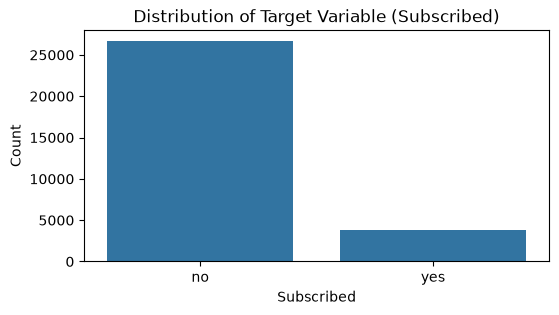

In [8]:
# ==========================================
# Target Variable Count Plot
# ==========================================

plt.figure(figsize=(6, 3))
sns.countplot(data=df, x="Subscribed")
plt.title("Distribution of Target Variable (Subscribed)")
plt.xlabel("Subscribed")
plt.ylabel("Count")
plt.show()

# Target Variable Visualization - Observations

## Findings

The count plot clearly shows a substantial imbalance between the two target classes.

### Class Distribution

- Non-Subscribers (`No`) dominate the dataset.
- Subscribers (`Yes`) represent a significantly smaller portion of the customer population.

---

## Visual Interpretation

The height of the `No` bar is considerably larger than the `Yes` bar, indicating that most customers contacted during the campaign did not subscribe to the fixed deposit product.

This confirms the class imbalance identified during the numerical analysis.

---

## Machine Learning Implications

The presence of class imbalance may lead certain machine learning algorithms to favor the majority class.

Without proper handling, models may achieve high Accuracy while performing poorly at identifying actual subscribers.

---

## Business Perspective

From a business standpoint, the minority class (`Yes`) is the most valuable class because it represents successful campaign conversions.

Therefore, model performance will be evaluated using:

- Precision
- Recall
- F1 Score
- ROC-AUC Score

rather than relying solely on Accuracy.

---

## Key Project Insight

The dataset contains a real-world business challenge where successful subscriptions are relatively rare.

This makes the project highly suitable for evaluating class imbalance handling techniques such as:

- SMOTE
- Random Oversampling
- Random Undersampling
- Class Weighting

---

## Next Step

The next step is to calculate and visualize the percentage distribution of the target classes to better communicate the degree of imbalance.

# Percentage Distribution Analysis

## Objective

While count plots show the absolute frequency of each class, percentage distributions provide a clearer understanding of the relative class proportions.

This helps quantify the severity of class imbalance.

---

## Why This Step Matters

Business stakeholders often find percentages easier to interpret than raw counts.

Percentage distributions help answer questions such as:

- What percentage of customers subscribed?
- What percentage of customers did not subscribe?
- How severe is the imbalance?

---

## Expected Outcome

A table displaying:

- Class Count
- Percentage Contribution

This will provide a business-friendly view of the target distribution.

In [9]:
# ==========================================
# Target Variable Percentage Distribution
# ==========================================

target_distribution = pd.DataFrame({"Count": df["Subscribed"].value_counts(), "Percentage": round((df["Subscribed"].value_counts(normalize=True) * 100), 2)})

target_distribution

,Count,Percentage
Subscribed,,
no,26621,87.35
yes,3856,12.65


# Percentage Distribution Analysis - Observations

## Findings

| Subscription Status | Count | Percentage |
|--------------------|--------|------------|
| No | 26,621 | 87.35% |
| Yes | 3,856 | 12.65% |

---

## Interpretation

Approximately 87 out of every 100 customers contacted during the telemarketing campaign did not subscribe to the fixed deposit product.

Only about 13 out of every 100 customers subscribed to the product.

---

## Business Insight

The probability of finding a successful subscriber through random outreach is relatively low.

This highlights the importance of developing a predictive model that can identify high-potential customers before conducting future marketing campaigns.

By targeting customers with a higher likelihood of subscription, the bank can:

- Reduce marketing costs
- Improve campaign efficiency
- Increase conversion rates
- Improve return on investment (ROI)

---

## Machine Learning Insight

The dataset exhibits a clear class imbalance problem.

As a result:

- Accuracy alone will not be sufficient for model evaluation.
- Additional metrics such as Recall, Precision, F1-Score, and ROC-AUC will be prioritized.
- Class imbalance handling techniques will be evaluated later in the project.

---

## Next Step

The next phase of Exploratory Data Analysis (EDA) will focus on understanding the independent variables.

We will begin with the numerical feature:

### Age

to understand its distribution, spread, skewness, and potential outliers.

# Categorical Feature Exploration

## Objective

Before visualizing individual features, it is important to understand the categories present within each categorical variable.

This analysis helps:

- Identify unique category levels
- Detect unexpected values
- Understand feature cardinality
- Prepare for encoding during preprocessing

---

## Why This Step Matters

Machine learning algorithms require numerical input.

Therefore, categorical variables will eventually need to be transformed using encoding techniques.

Understanding category structure beforehand helps select the most appropriate encoding strategy.

---

## Expected Outcome

For each categorical feature:

- Number of unique categories
- List of category values

In [10]:
# ==========================================
# Unique Values in Categorical Features
# ==========================================

categorical_columns = df.select_dtypes(include=["object", "string"]).columns

for col in categorical_columns:
    print("=" * 60)
    print(f"Feature: {col}")
    print(f"Unique Values: {df[col].nunique()}")
    print(df[col].unique())
    print()

Feature: Job
Unique Values: 11
<StringArray>
[    'housemaid',      'services',        'admin.',    'technician',
   'blue-collar',    'unemployed',       'retired',  'entrepreneur',
    'management',       'student', 'self-employed']
Length: 11, dtype: str

Feature: Marital_Status
Unique Values: 3
<StringArray>
['married', 'single', 'divorced']
Length: 3, dtype: str

Feature: Education
Unique Values: 4
<StringArray>
[     'Primary_Education',    'Secondary_Education', 'Professional_Education',
     'Tertiary_Education']
Length: 4, dtype: str

Feature: Default_Credit
Unique Values: 2
<StringArray>
['no', 'yes']
Length: 2, dtype: str

Feature: Housing_Loan
Unique Values: 2
<StringArray>
['no', 'yes']
Length: 2, dtype: str

Feature: Personal_Loan
Unique Values: 2
<StringArray>
['no', 'yes']
Length: 2, dtype: str

Feature: Subscribed
Unique Values: 2
<StringArray>
['no', 'yes']
Length: 2, dtype: str



# Categorical Feature Exploration - Observations

## Findings

The dataset contains six categorical predictor variables and one categorical target variable.

### Feature Summary

| Feature | Unique Categories |
|----------|------------------|
| Job | 11 |
| Marital_Status | 3 |
| Education | 4 |
| Default_Credit | 2 |
| Housing_Loan | 2 |
| Personal_Loan | 2 |
| Subscribed | 2 |

---

## Data Quality Assessment

No unexpected category levels were identified.

No missing category values such as "Unknown" or "Other" were observed.

This indicates a clean and well-structured dataset.

---

## Feature Characteristics

### Nominal Features

The following features contain categories with no natural ordering:

- Job
- Marital_Status

### Binary Features

The following features contain two possible values:

- Default_Credit
- Housing_Loan
- Personal_Loan

### Potentially Ordinal Feature

Education may possess an inherent educational hierarchy:

- Primary Education
- Secondary Education
- Professional Education
- Tertiary Education

The encoding strategy for this feature will be evaluated during preprocessing.

---

## Machine Learning Implications

The dataset has low categorical cardinality.

This makes the dataset well-suited for:

- One-Hot Encoding
- Tree-Based Models
- Linear Models
- Ensemble Models

without significant computational overhead.

---

## Next Step

The next stage of EDA focuses on the numerical feature (`Age`) to understand:

- Distribution
- Central tendency
- Skewness
- Potential outliers

# Age Distribution Analysis

## Objective

The purpose of this analysis is to understand the distribution of customer ages within the dataset.

Age is the only numerical feature available and may play an important role in predicting customer subscription behavior.

---

## Why This Analysis Matters

Understanding age distribution helps identify:

- Common customer age groups
- Data concentration
- Distribution shape
- Potential skewness
- Unusual age values

---

## Visualization Techniques

The following visualizations will be used:

1. Histogram
2. Kernel Density Estimation (KDE)

These plots help assess the overall shape of the distribution.

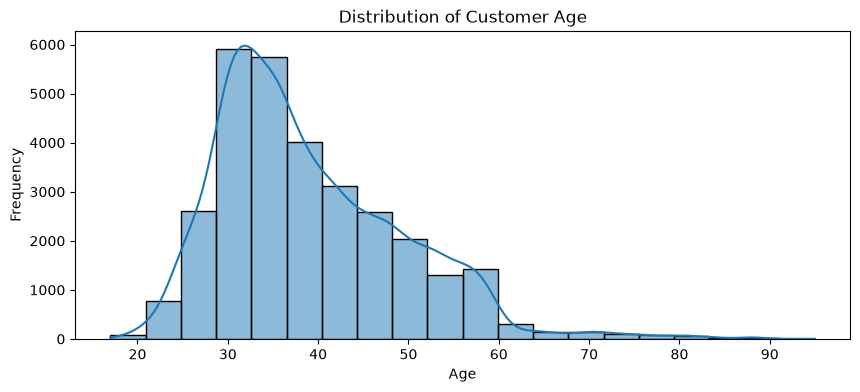

In [11]:
# ==========================================
# Age Distribution
# ==========================================

plt.figure(figsize=(10, 4))
sns.histplot(data=df, x="Age", bins=20, kde=True)
plt.title("Distribution of Customer Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Age Distribution Analysis - Observations

## Findings

The age distribution exhibits a moderate positive (right) skew.

Most customers fall within the age range of approximately:

- 30 to 45 years

The highest concentration of customers appears to be in the early-to-mid thirties.

---

## Distribution Characteristics

### Central Concentration

The majority of customers belong to the working-age population.

This aligns with the nature of banking products such as:

- Fixed deposits
- Savings accounts
- Loans
- Credit products

---

### Skewness

The distribution contains a longer tail toward higher ages.

A relatively small number of customers belong to older age groups (60+ years), which causes the distribution to be right-skewed.

This observation is consistent with the descriptive statistics where:

Mean Age > Median Age

---

## Data Quality Assessment

No unrealistic age values were observed.

The age range:

17 to 95 years

appears reasonable and consistent with real-world banking customers.

---

## Initial Conclusion

Age appears to be a meaningful predictor and should be retained for model development.

Further investigation will be performed using:

- Skewness analysis
- Boxplots
- Outlier detection techniques

to determine whether transformation or outlier treatment is required.

---

## Next Step

The next step is to quantify the degree of skewness numerically.

# Age Skewness Analysis

## Objective

Skewness measures the asymmetry of a numerical distribution.

Understanding skewness helps determine:

- Whether the data is normally distributed
- Whether transformations may be required
- Whether extreme values are affecting the distribution

---

## General Interpretation

| Skewness Value | Interpretation |
|---------------|---------------|
| 0 | Perfectly Symmetric |
| -0.5 to 0.5 | Approximately Symmetric |
| > 0.5 | Positively Skewed |
| < -0.5 | Negatively Skewed |

---

## Expected Outcome

A numerical skewness value for the `Age` feature.

In [12]:
# ==========================================
# Skewness of Age
# ==========================================

age_skewness = df["Age"].skew()

print(f"Age Skewness: {age_skewness:.4f}")

Age Skewness: 0.9807


# Age Skewness Analysis - Observations

## Findings

The calculated skewness value for the `Age` feature is:

### 0.9807

---

## Interpretation

The age distribution is moderately positively skewed.

This indicates that:

- Most customers are concentrated in lower age ranges.
- A smaller number of customers belong to higher age groups.
- The distribution contains a longer tail toward older ages.

---

## Comparison with Histogram

The skewness value supports the observations made during the histogram analysis, where a noticeable right-side tail was present.

---

## Business Interpretation

A positively skewed age distribution is expected in banking datasets because:

- Most customers belong to working-age groups.
- Fewer customers belong to retirement-age populations.
- Very elderly customers represent a relatively small portion of the customer base.

---

## Data Preprocessing Decision

At this stage, no transformation will be applied to the `Age` feature.

The feature appears realistic and business meaningful.

A final decision regarding transformation will be made after:

- Outlier analysis
- Model evaluation
- Feature importance assessment

---

## Next Step

The next step is to visualize the age distribution using a boxplot to identify potential outliers and understand the spread of the data.

# Age Boxplot Analysis

## Objective

A boxplot is used to visualize:

- Data spread
- Median
- Quartiles
- Potential outliers

---

## Why This Step Matters

Boxplots provide a quick way to identify observations that lie far from the majority of the data.

These observations may represent:

- Genuine extreme values
- Data entry errors
- Rare customer segments

---

## Important Note

The presence of outliers does not automatically imply that they should be removed.

Business context must always be considered before performing outlier treatment.

---

## Expected Outcome

A boxplot displaying:

- Median Age
- Interquartile Range (IQR)
- Potential outliers

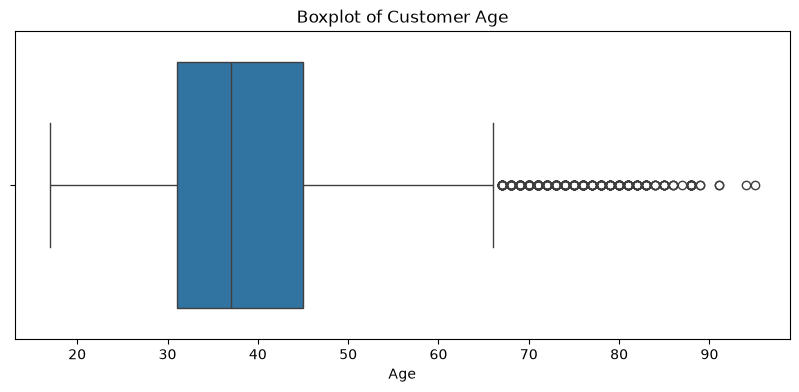

In [13]:
# ==========================================
# Age Boxplot
# ==========================================

plt.figure(figsize=(10, 4))
sns.boxplot(x=df["Age"])
plt.title("Boxplot of Customer Age")
plt.show()

# Age Outlier Analysis Using IQR Method

## Objective

The Interquartile Range (IQR) method is a commonly used statistical technique for identifying potential outliers.

The method calculates:

- First Quartile (Q1)
- Third Quartile (Q3)
- Interquartile Range (IQR)

Using these values, lower and upper bounds are determined.

Observations outside these bounds are considered potential outliers.

---

## IQR Formula

IQR = Q3 − Q1

Lower Bound = Q1 − (1.5 × IQR)

Upper Bound = Q3 + (1.5 × IQR)

---

## Important Note

Potential outliers identified by the IQR method are not automatically removed.

Business context and domain knowledge must be considered before making any treatment decisions.

---

## Expected Outcome

- Q1
- Q3
- IQR
- Lower Bound
- Upper Bound
- Number of Potential Outliers

In [14]:
# ==========================================
# IQR Based Outlier Analysis
# ==========================================

Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers = df[(df["Age"] < lower_bound) | (df["Age"] > upper_bound)]

print(f"Q1           : {Q1}")
print(f"Q3           : {Q3}")
print(f"IQR          : {IQR}")
print(f"Lower Bound  : {lower_bound}")
print(f"Upper Bound  : {upper_bound}")
print(f"Outlier Count: {len(outliers)}")

Q1           : 31.0
Q3           : 45.0
IQR          : 14.0
Lower Bound  : 10.0
Upper Bound  : 66.0
Outlier Count: 458


# Outlier Analysis - Observations

## Findings

Using the IQR method:

| Metric | Value |
|----------|----------|
| Q1 | 31 |
| Q3 | 45 |
| IQR | 14 |
| Lower Bound | 10 |
| Upper Bound | 66 |
| Potential Outliers | 458 |

---

## Outlier Percentage

The IQR method identified approximately 1.5% of observations as potential outliers.

All identified outliers occur above the upper bound of 66 years.

No lower-bound outliers were detected.

---

## Business Assessment

The identified observations correspond to older customers rather than invalid or erroneous values.

Since older customers represent a realistic banking customer segment, these observations may contain important predictive information.

---

## Treatment Decision

No outlier treatment will be applied to the `Age` feature.

The identified observations are:

- Valid
- Realistic
- Business relevant

Removing them could reduce model effectiveness and eliminate valuable customer behavior patterns.

---

## Final Decision

Age outliers will be retained for all subsequent analyses and model development stages.

---

## Next Step

The next stage of EDA will investigate the relationship between customer age and subscription behavior.

# Age vs Subscription Analysis

## Objective

The purpose of this analysis is to understand whether customer age influences subscription behavior.

Rather than analyzing age independently, this step investigates the relationship between:

- Age
- Subscription Status

---

## Why This Analysis Matters

Customer age may influence financial behavior and investment preferences.

Understanding age patterns among subscribers and non-subscribers can provide valuable business insights and help determine whether age is an important predictive feature.

---

## Visualization Technique

A boxplot will be used to compare age distributions across subscription categories.

---

## Expected Outcome

A visual comparison of customer age between:

- Subscribers
- Non-Subscribers

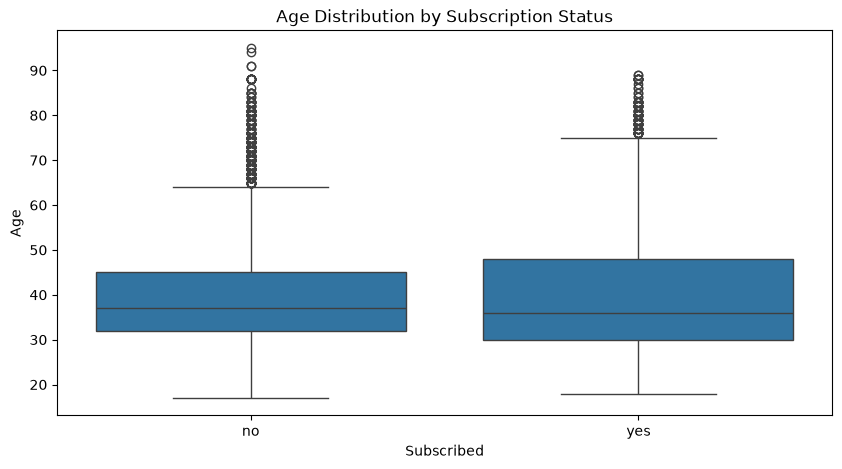

In [15]:
# ==========================================
# Age vs Subscription
# ==========================================

plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="Subscribed", y="Age")
plt.title("Age Distribution by Subscription Status")
plt.xlabel("Subscribed")
plt.ylabel("Age")
plt.show()

# Age vs Subscription Analysis - Observations

## Findings

The age distributions of subscribers and non-subscribers appear broadly similar.

The median age for both groups is located within the mid-thirties age range.

---

## Distribution Comparison

### Non-Subscribers

- Median age approximately 37 years.
- Age distribution concentrated between 30 and 45 years.

### Subscribers

- Median age approximately 36 years.
- Slightly wider age distribution.
- Greater representation among older age groups.

---

## Business Interpretation

The visual comparison suggests that age alone may not be a strong differentiating factor between subscribers and non-subscribers.

However, the subscriber group appears to contain more customers in higher age ranges, indicating that older customers may exhibit different investment behaviors.

Further analysis would be required to quantify this relationship.

---

## Machine Learning Implications

Although age does not appear to provide strong class separation visually, it may still contribute predictive value when combined with other customer attributes.

Therefore, the feature will be retained for model development.

---

## Key Takeaway

Age appears to have some influence on subscription behavior but is unlikely to be a standalone predictor.

Its predictive strength should be evaluated further during model training and feature importance analysis.

---

## Next Step

The next phase of EDA will focus on categorical features and their relationship with subscription behavior.

# Job Feature Analysis

## Objective

The purpose of this analysis is to understand the distribution of customers across different occupation categories.

The `Job` feature represents the customer's profession or employment type and may influence financial behavior, investment preferences, and subscription decisions.

---

## Why This Analysis Matters

Different occupations often have different:

- Income levels
- Savings behavior
- Risk appetite
- Investment preferences

Understanding the distribution of occupations helps identify dominant customer segments within the dataset.

---

## Expected Outcome

This analysis will provide:

- Number of customers in each occupation category
- Relative distribution of occupations
- Initial understanding of customer demographics

In [16]:
# ==========================================
# Job Distribution
# ==========================================

job_distribution = pd.DataFrame({
    "Count": df["Job"].value_counts(),
    "Percentage": round(df["Job"].value_counts(normalize=True) * 100, 2)
})

job_distribution

,Count,Percentage
Job,,
admin.,8737,28.67
blue-collar,5671,18.61
technician,5473,17.96
services,2857,9.37
management,2311,7.58
retired,1214,3.98
self-employed,1089,3.57
entrepreneur,1087,3.57
unemployed,738,2.42


# Job Feature Analysis - Observations

## Findings

The dataset contains customers from 11 different occupation categories.

### Occupation Distribution

| Job Category | Count | Percentage |
|--------------|--------|------------|
| admin. | 8,737 | 28.67% |
| blue-collar | 5,671 | 18.61% |
| technician | 5,473 | 17.96% |
| services | 2,857 | 9.37% |
| management | 2,311 | 7.58% |
| retired | 1,214 | 3.98% |
| self-employed | 1,089 | 3.57% |
| entrepreneur | 1,087 | 3.57% |
| unemployed | 738 | 2.42% |
| housemaid | 690 | 2.26% |
| student | 610 | 2.00% |

---

## Key Observations

### Dominant Occupation Groups

The three largest customer segments are:

- Admin (28.67%)
- Blue-Collar (18.61%)
- Technician (17.96%)

Together, these categories account for more than 65% of all customers in the dataset.

---

### Small Customer Segments

The smallest occupation groups are:

- Student
- Housemaid
- Unemployed

These categories each represent less than 3% of the customer population.

---

## Business Interpretation

The customer base is primarily composed of working professionals and skilled workers.

This suggests that the bank's marketing campaigns are largely targeting economically active individuals.

---

## Machine Learning Implications

The Job feature contains meaningful segmentation information and may become an important predictor of subscription behavior.

However, customer count alone does not indicate conversion effectiveness.

The next step is to determine which occupation groups are more likely to subscribe to the fixed deposit product.

# Job vs Subscription Analysis

## Objective

The purpose of this analysis is to understand how subscription behavior varies across different occupation categories.

Rather than examining customer counts alone, this analysis focuses on identifying occupation groups that are more likely to subscribe to a fixed deposit product.

---

## Why This Analysis Matters

Occupation often influences:

- Income level
- Savings capacity
- Financial planning behavior
- Investment preferences

Identifying high-conversion occupation groups can help the bank improve future marketing campaign targeting.

---

## Expected Outcome

This analysis will calculate:

- Total customers by occupation
- Number of subscribers by occupation
- Subscription rate (%)

The subscription rate will provide a more meaningful business insight than customer counts alone.

In [17]:
# ==========================================
# Job-wise Subscription Rate Analysis
# ==========================================

job_subscription = pd.crosstab(df["Job"], df["Subscribed"], normalize="index") * 100

job_subscription = round(job_subscription, 2)

job_subscription.sort_values(by="yes", ascending=False)

Subscribed,no,yes
Job,,
student,66.72,33.28
retired,70.68,29.32
unemployed,82.93,17.07
admin.,86.08,13.92
housemaid,87.39,12.61
management,87.62,12.38
self-employed,87.97,12.03
technician,88.29,11.71
entrepreneur,90.80,9.20


# Job vs Subscription Analysis - Observations

## Findings

Subscription behavior varies significantly across occupation categories.

### Highest Subscription Rates

| Job Category | Subscription Rate (%) |
|--------------|----------------------|
| Student | 33.28 |
| Retired | 29.32 |
| Unemployed | 17.07 |

### Lowest Subscription Rates

| Job Category | Subscription Rate (%) |
|--------------|----------------------|
| Blue-Collar | 7.97 |
| Services | 9.03 |
| Entrepreneur | 9.20 |

---

## Business Insights

Students and retired customers exhibit the highest likelihood of subscribing to fixed deposit products.

Their subscription rates are substantially higher than the overall dataset subscription rate of approximately 12.65%.

This suggests that these customer groups may have stronger savings-oriented behavior or greater interest in low-risk investment products.

---

## Marketing Implications

Future telemarketing campaigns could improve efficiency by prioritizing customer segments with historically higher subscription rates.

Particular attention could be given to:

- Students
- Retired Customers
- Unemployed Customers

as they demonstrate above-average conversion rates.

---

## Machine Learning Implications

The Job feature demonstrates strong class separation.

Large differences in subscription rates across occupation groups indicate that Job is likely to be an important predictive feature during model training.

---

## Key Takeaway

Occupation appears to be one of the strongest behavioral indicators identified so far and is expected to contribute significant predictive value to classification models.

---

## Next Step

The next stage of analysis will visualize subscription rates across occupation categories to provide a clearer comparison of customer behavior.

# Visualizing Job-wise Subscription Rates

## Objective

Visual representations make it easier to compare subscription behavior across occupation groups.

This chart will highlight:

- High-conversion occupations
- Low-conversion occupations
- Relative differences in customer behavior

---

## Why This Matters

Business stakeholders often understand visual comparisons more quickly than numerical tables.

This visualization will help identify the most promising customer segments for future marketing campaigns.

---

## Expected Outcome

A ranked chart showing subscription percentages for each occupation category.

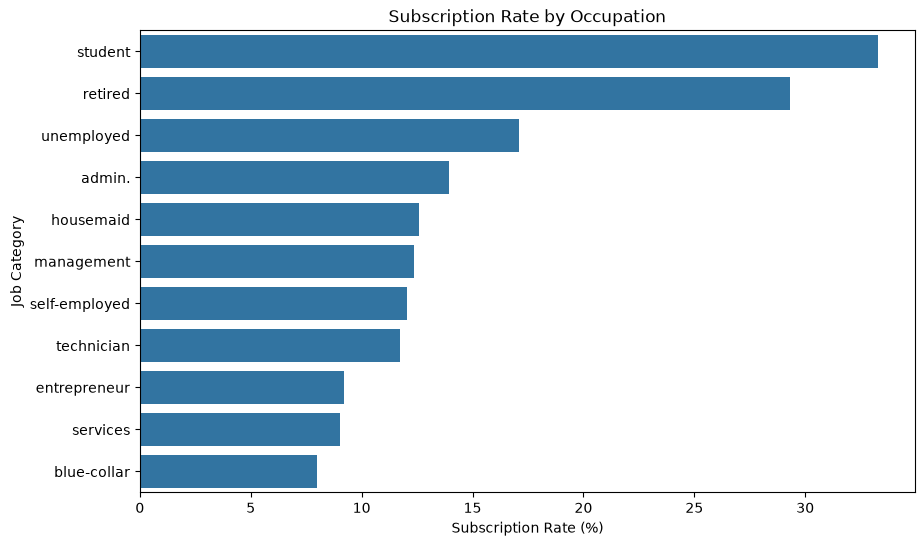

In [18]:
# ==========================================
# Job-wise Subscription Rate Visualization
# ==========================================

job_subscription_rate = (pd.crosstab(df["Job"], df["Subscribed"], normalize="index")["yes"]* 100)

job_subscription_rate = (job_subscription_rate.sort_values(ascending=False))

plt.figure(figsize=(10, 6))
sns.barplot(x=job_subscription_rate.values, y=job_subscription_rate.index)
plt.title("Subscription Rate by Occupation")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Job Category")
plt.show()

# Job-wise Subscription Rate Visualization - Observations

## Findings

The visualization clearly demonstrates substantial variation in subscription rates across occupation categories.

---

## Highest Performing Occupation Groups

### Student (33.28%)

Students exhibit the highest subscription rate among all occupation categories.

Their conversion rate is significantly higher than the overall dataset average of 12.65%.

---

### Retired (29.32%)

Retired customers represent the second-highest subscription segment.

This customer group may have:

- Greater savings capacity
- Lower risk tolerance
- Higher preference for fixed-income investment products

---

### Unemployed (17.07%)

Although the unemployed category represents a relatively small segment of customers, its subscription rate remains above the overall average.

---

## Lowest Performing Occupation Groups

### Blue-Collar (7.97%)

Blue-collar workers exhibit the lowest subscription rate among all occupation categories.

### Services (9.03%)

Customers in service-oriented occupations also demonstrate relatively low conversion rates.

### Entrepreneur (9.20%)

Entrepreneurs show below-average subscription behavior, potentially reflecting a preference for higher-return investment opportunities.

---

## Business Implications

The results suggest that occupation has a meaningful influence on customer investment behavior.

Rather than applying a uniform telemarketing strategy, the bank could prioritize customer segments with historically higher conversion rates.

---

## Marketing Recommendations

Future campaigns may benefit from targeted outreach toward:

- Students
- Retired Customers
- Unemployed Customers

These segments demonstrate substantially higher subscription likelihood.

---

## Machine Learning Implications

The large variation in subscription rates across occupations indicates strong predictive potential.

The Job feature is expected to become an important contributor to model performance and feature importance rankings.

---

## Key Takeaway

Occupation is one of the strongest business indicators identified so far and shows clear discriminatory power between subscribers and non-subscribers.

# Statistical Validation: Job vs Subscription

## Objective

Visualizations suggest that subscription behavior varies across occupation categories.

To validate whether this relationship is statistically significant, a Chi-Square Test of Independence will be performed.

---

## Null Hypothesis (H₀)

There is no relationship between:

- Job Category
- Subscription Status

The two variables are independent.

---

## Alternative Hypothesis (H₁)

There is a statistically significant relationship between:

- Job Category
- Subscription Status

The two variables are not independent.

---

## Significance Level

α = 0.05

---

## Decision Rule

If:

p-value < 0.05

Reject the Null Hypothesis.

Otherwise:

Fail to Reject the Null Hypothesis.

---

## Expected Outcome

The test will determine whether occupation has a statistically significant relationship with subscription behavior.

In [19]:
# ==========================================
# Chi-Square Test: Job vs Subscription
# ==========================================

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df["Job"], df["Subscribed"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"P-Value              : {p_value:.10f}")
print(f"Degrees of Freedom   : {dof}")

Chi-Square Statistic : 728.9337
P-Value              : 0.0000000000
Degrees of Freedom   : 10


# Statistical Validation - Job vs Subscription

## Chi-Square Test of Independence

A Chi-Square Test was performed to determine whether occupation and subscription status are statistically associated.

---

## Hypotheses

### Null Hypothesis (H₀)

Job category and subscription status are independent.

### Alternative Hypothesis (H₁)

Job category and subscription status are associated.

---

## Test Results

| Metric | Value |
|----------|----------|
| Chi-Square Statistic | 728.9337 |
| Degrees of Freedom | 10 |
| P-Value | < 0.0001 |

---

## Decision

Since the p-value is significantly smaller than the significance level (α = 0.05), the Null Hypothesis is rejected.

---

## Interpretation

There is strong statistical evidence that customer occupation is associated with subscription behavior.

The observed differences in subscription rates across occupation groups are unlikely to have occurred by random chance.

---

## Business Implications

Occupation should be considered an important customer segmentation variable when designing telemarketing campaigns.

Customers belonging to different occupation groups exhibit substantially different conversion behavior.

---

## Machine Learning Implications

The Job feature demonstrates both:

- Business relevance
- Statistical significance

Therefore, it is expected to contribute meaningful predictive power during model training.

# Marital Status Feature Analysis

## Objective

The purpose of this analysis is to understand the distribution of customers across different marital status categories.

Marital status may influence:

- Financial planning behavior
- Savings habits
- Investment decisions
- Long-term financial commitments

---

## Why This Analysis Matters

Individuals with different marital statuses may exhibit different responses to fixed deposit offers.

Understanding these patterns may help improve customer targeting strategies and contribute valuable information for predictive modeling.

---

## Expected Outcome

This analysis will provide:

- Customer counts by marital status
- Percentage distribution
- Initial demographic insights

In [20]:
# ==========================================
# Marital Status Distribution
# ==========================================

marital_distribution = pd.DataFrame({
    "Count": df["Marital_Status"].value_counts(),
    "Percentage": round(df["Marital_Status"].value_counts(normalize=True) * 100, 2)
})

marital_distribution

,Count,Percentage
Marital_Status,,
married,17483,57.36
single,9443,30.98
divorced,3551,11.65


# Marital Status Distribution - Observations

## Findings

The customer base consists of three marital status categories:

| Marital Status | Count | Percentage |
|---------------|--------|------------|
| Married | 17,483 | 57.36% |
| Single | 9,443 | 30.98% |
| Divorced | 3,551 | 11.65% |

---

## Key Observations

### Married Customers Dominate the Dataset

More than half of all customers belong to the married category.

Married individuals account for approximately:

57.36% of the customer population.

---

### Single Customers Form a Significant Segment

Single customers represent nearly one-third of the dataset.

This segment accounts for:

30.98% of all customers.

---

### Divorced Customers Represent the Smallest Group

The divorced category contributes:

11.65% of customers.

Although smaller in size, this segment may still exhibit unique financial behaviors that influence subscription decisions.

---

## Business Interpretation

The bank's customer base is primarily composed of married individuals, suggesting that many customers may be engaged in long-term financial planning activities.

Marital status often influences:

- Household income
- Savings behavior
- Investment decisions
- Risk tolerance

Therefore, this feature may provide valuable predictive information.

---

## Machine Learning Implications

Marital status may contribute meaningful behavioral signals and should be evaluated further against the target variable (Subscribed).

The next step is to determine whether subscription behavior differs across marital status groups.

# Marital Status vs Subscription Analysis

## Objective

The purpose of this analysis is to determine whether subscription behavior varies across different marital status groups.

Rather than focusing on customer counts alone, this analysis investigates conversion behavior within each marital category.

---

## Why This Analysis Matters

Marital status may influence:

- Financial responsibilities
- Household planning
- Investment preferences
- Long-term savings goals

These factors may impact a customer's likelihood of subscribing to fixed deposit products.

---

## Expected Outcome

The analysis will calculate:

- Subscription percentage by marital status
- Relative conversion performance
- Potential business opportunities for targeted marketing campaigns

In [21]:
# ==========================================
# Marital Status vs Subscription Rate
# ==========================================

marital_subscription = pd.crosstab(df["Marital_Status"], df["Subscribed"], normalize="index") * 100

marital_subscription = round(marital_subscription, 2)

marital_subscription.sort_values(by="yes", ascending=False)

Subscribed,no,yes
Marital_Status,,
single,85.25,14.75
married,88.25,11.75
divorced,88.48,11.52


# Marital Status vs Subscription Analysis - Observations

## Findings

Subscription behavior varies across marital status groups.

### Subscription Rates

| Marital Status | Subscription Rate (%) |
|---------------|----------------------|
| Single | 14.75 |
| Married | 11.75 |
| Divorced | 11.52 |

---

## Key Observations

### Highest Subscription Rate

Single customers demonstrate the highest subscription rate among all marital categories.

Their subscription rate exceeds the overall dataset average of approximately 12.65%.

---

### Married and Divorced Customers

Married and divorced customers exhibit relatively similar subscription behavior.

Both groups have subscription rates below the overall dataset average.

---

## Business Interpretation

The results suggest that marital status may influence customer investment decisions.

Single customers appear slightly more responsive to fixed deposit offers compared to married and divorced customers.

Possible contributing factors may include:

- Independent decision-making
- Different financial responsibilities
- Different savings behavior

However, additional analysis would be required to validate these assumptions.

---

## Machine Learning Implications

Marital status demonstrates some degree of class separation.

Although the differences are smaller than those observed for the Job feature, marital status may still contribute useful predictive information when combined with other customer attributes.

---

## Key Takeaway

Single customers exhibit the highest subscription propensity among the three marital status categories.

The feature should be retained for model development and further statistical validation.

# Visualizing Marital Status Subscription Rates

## Objective

This visualization compares subscription rates across marital status categories.

The chart helps identify differences in customer conversion behavior and supports business interpretation of the results.

---

## Why This Matters

Visual comparison makes it easier to identify:

- High-conversion customer groups
- Low-conversion customer groups
- Relative differences in subscription behavior

---

## Expected Outcome

A ranked chart displaying subscription percentages for each marital status category.

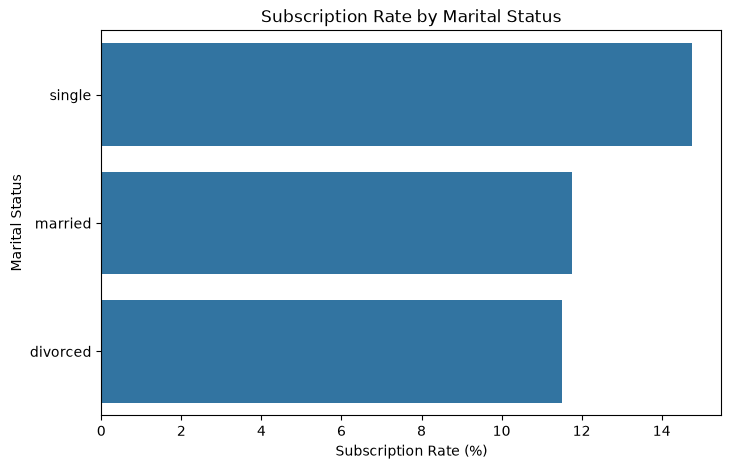

In [22]:
# ==========================================
# Marital Status Subscription Rate Visualization
# ==========================================

marital_subscription_rate = (pd.crosstab(df["Marital_Status"], df["Subscribed"], normalize="index")["yes"] * 100)

marital_subscription_rate = (marital_subscription_rate.sort_values(ascending=False))

plt.figure(figsize=(8, 5))
sns.barplot(x=marital_subscription_rate.values, y=marital_subscription_rate.index)
plt.title("Subscription Rate by Marital Status")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Marital Status")
plt.show()

# Marital Status Subscription Rate Visualization - Observations

## Findings

The visualization shows noticeable differences in subscription rates across marital status categories.

---

## Highest Conversion Group

### Single Customers

Single customers exhibit the highest subscription rate at:

14.75%

This conversion rate exceeds the overall dataset average of 12.65%.

---

## Lower Conversion Groups

### Married Customers

Subscription Rate:

11.75%

### Divorced Customers

Subscription Rate:

11.52%

Both groups demonstrate similar subscription behavior and fall below the overall dataset average.

---

## Business Insights

The results suggest that single customers may be more receptive to fixed deposit offers compared to married and divorced customers.

This may indicate differences in:

- Financial planning behavior
- Savings objectives
- Investment decision-making processes

---

## Comparison with Job Feature

Although marital status demonstrates some variation in conversion rates, the separation between categories is considerably smaller than that observed for the Job feature.

For example:

- Highest Job Conversion Rate: 33.28%
- Lowest Job Conversion Rate: 7.97%

Compared with:

- Highest Marital Status Conversion Rate: 14.75%
- Lowest Marital Status Conversion Rate: 11.52%

This suggests that Job may be a stronger predictor than Marital Status.

---

## Machine Learning Implications

Marital Status appears to contain predictive information and should be retained for model development.

However, its individual predictive power is likely lower than that of the Job feature.

---

## Next Step

A Chi-Square Test of Independence will be performed to determine whether the observed differences are statistically significant.

# Statistical Validation: Marital Status vs Subscription

## Objective

A Chi-Square Test of Independence will be performed to determine whether marital status and subscription behavior are statistically associated.

---

## Null Hypothesis (H₀)

Marital Status and Subscription Status are independent.

There is no relationship between the two variables.

---

## Alternative Hypothesis (H₁)

Marital Status and Subscription Status are associated.

There is a statistically significant relationship between the two variables.

---

## Significance Level

α = 0.05

---

## Decision Rule

If:

p-value < 0.05

Reject the Null Hypothesis.

Otherwise:

Fail to Reject the Null Hypothesis.

---

## Expected Outcome

The test will determine whether marital status contributes meaningful information regarding subscription behavior.

In [23]:
# ==========================================
# Chi-Square Test:
# Marital Status vs Subscription
# ==========================================

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df["Marital_Status"], df["Subscribed"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"P-Value              : {p_value:.10f}")
print(f"Degrees of Freedom   : {dof}")

Chi-Square Statistic : 54.7150
P-Value              : 0.0000000000
Degrees of Freedom   : 2


# Statistical Validation - Marital Status vs Subscription

## Chi-Square Test of Independence

A Chi-Square Test was performed to determine whether marital status and subscription behavior are statistically associated.

---

## Hypotheses

### Null Hypothesis (H₀)

Marital Status and Subscription Status are independent.

### Alternative Hypothesis (H₁)

Marital Status and Subscription Status are associated.

---

## Test Results

| Metric | Value |
|----------|----------|
| Chi-Square Statistic | 54.7150 |
| Degrees of Freedom | 2 |
| P-Value | < 0.0001 |

---

## Decision

Since the p-value is significantly lower than the significance level (α = 0.05), the Null Hypothesis is rejected.

---

## Interpretation

There is statistical evidence that marital status and subscription behavior are associated.

The observed differences in subscription rates are unlikely to have occurred by random chance.

---

## Business Implications

Single customers exhibit a higher subscription rate than married and divorced customers.

This suggests that marital status may influence customer investment behavior and responsiveness to fixed deposit offers.

---

## Machine Learning Implications

Although statistically significant, the differences between marital categories are relatively small compared with those observed for the Job feature.

Therefore, marital status is expected to provide moderate predictive value during model development.

---

## Key Takeaway

Marital Status demonstrates statistical significance and should be retained as a predictor variable for classification modeling.

# Education Feature Analysis

## Objective

The purpose of this analysis is to understand the distribution of customers across different education levels.

Education level may influence:

- Financial awareness
- Savings habits
- Investment preferences
- Long-term financial planning

---

## Why This Analysis Matters

Educational background often impacts financial decision-making and may influence a customer's likelihood of subscribing to fixed deposit products.

Understanding customer distribution across education categories provides important demographic context.

---

## Expected Outcome

This analysis will provide:

- Customer counts by education level
- Percentage distribution
- Initial demographic insights

In [24]:
# ==========================================
# Education Distribution
# ==========================================

education_distribution = pd.DataFrame({
    "Count": df["Education"].value_counts(),
    "Percentage": round(df["Education"].value_counts(normalize=True) * 100, 2)
})

education_distribution

,Count,Percentage
Education,,
Secondary_Education,11975,39.29
Tertiary_Education,10412,34.16
Professional_Education,4321,14.18
Primary_Education,3769,12.37


# Education Distribution - Observations

## Findings

The dataset contains customers from four education categories.

| Education Level | Count | Percentage |
|----------------|--------|------------|
| Secondary Education | 11,975 | 39.29% |
| Tertiary Education | 10,412 | 34.16% |
| Professional Education | 4,321 | 14.18% |
| Primary Education | 3,769 | 12.37% |

---

## Key Observations

### Secondary Education Dominates the Dataset

Secondary education represents the largest customer segment.

Approximately 39.29% of all customers belong to this category.

---

### Strong Presence of Highly Educated Customers

Tertiary education accounts for:

34.16% of customers.

Together, Secondary and Tertiary Education comprise more than 73% of the entire dataset.

---

### Smaller Segments

Primary Education and Professional Education contribute a smaller proportion of customers:

- Professional Education: 14.18%
- Primary Education: 12.37%

---

## Business Interpretation

The majority of customers possess at least secondary-level education.

This suggests that the bank's customer base is largely composed of individuals with moderate to high educational backgrounds.

Education often influences:

- Financial literacy
- Product awareness
- Investment behavior
- Long-term financial planning

Therefore, education may play an important role in subscription decisions.

---

## Machine Learning Implications

Education is a potentially high-value predictor and should be examined against subscription behavior.

Differences in financial knowledge and investment awareness across education levels may contribute meaningful predictive information.

# Education vs Subscription Analysis

## Objective

The purpose of this analysis is to determine whether subscription behavior differs across education levels.

Education may influence:

- Financial literacy
- Investment awareness
- Understanding of banking products
- Long-term savings behavior

---

## Why This Analysis Matters

Customers with different educational backgrounds may respond differently to fixed deposit offers.

Understanding these differences can help the bank design more targeted and effective marketing campaigns.

---

## Expected Outcome

The analysis will calculate:

- Subscription rates by education level
- Relative conversion performance
- Potential high-value customer segments

In [25]:
# ==========================================
# Education vs Subscription Rate
# ==========================================

education_subscription = pd.crosstab(df["Education"], df["Subscribed"], normalize="index") * 100

education_subscription = round(education_subscription, 2)

education_subscription.sort_values(by="yes", ascending=False)

Subscribed,no,yes
Education,,
Tertiary_Education,85.19,14.81
Professional_Education,87.55,12.45
Primary_Education,87.74,12.26
Secondary_Education,89.03,10.97


# Education vs Subscription Analysis - Observations

## Findings

Subscription behavior varies across education levels.

### Subscription Rates

| Education Level | Subscription Rate (%) |
|-----------------|----------------------|
| Tertiary Education | 14.81 |
| Professional Education | 12.45 |
| Primary Education | 12.26 |
| Secondary Education | 10.97 |

---

## Key Observations

### Highest Subscription Rate

Customers with Tertiary Education demonstrate the highest subscription rate.

Their conversion rate exceeds the overall dataset average of approximately 12.65%.

---

### Lowest Subscription Rate

Customers with Secondary Education exhibit the lowest subscription rate among all education groups.

---

## Business Interpretation

The results suggest that education level may influence customer investment behavior.

Individuals with higher educational attainment may possess:

- Greater financial literacy
- Better understanding of investment products
- Stronger long-term financial planning habits

These factors may contribute to higher subscription rates.

---

## Comparison Across Education Levels

The difference between the highest and lowest education groups is noticeable but not extreme.

Education appears to have a moderate influence on subscription behavior.

---

## Machine Learning Implications

Education demonstrates meaningful class separation and should be retained as a predictor variable.

However, its predictive strength appears lower than that observed for the Job feature.

---

## Key Takeaway

Tertiary Education customers exhibit the highest subscription propensity, suggesting that education level contributes useful behavioral information for predictive modeling.

# Visualizing Education Subscription Rates

## Objective

This visualization compares subscription rates across education levels.

The chart provides a clear comparison of customer conversion behavior and helps identify education groups with higher subscription propensity.

---

## Why This Matters

Visual comparisons help business stakeholders quickly identify:

- High-conversion segments
- Low-conversion segments
- Potential customer targeting opportunities

---

## Expected Outcome

A ranked chart displaying subscription percentages for each education category.

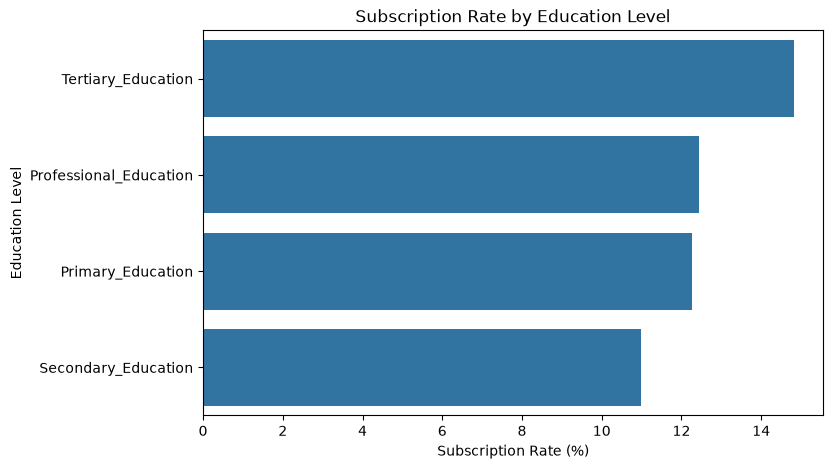

In [26]:
# ==========================================
# Education Subscription Rate Visualization
# ==========================================

education_subscription_rate = (pd.crosstab(df["Education"], df["Subscribed"], normalize="index")["yes"] * 100)

education_subscription_rate = (education_subscription_rate.sort_values(ascending=False))

plt.figure(figsize=(8, 5))
sns.barplot(x=education_subscription_rate.values, y=education_subscription_rate.index)
plt.title("Subscription Rate by Education Level")
plt.xlabel("Subscription Rate (%)")
plt.ylabel("Education Level")
plt.show()

# Education Subscription Rate Visualization - Observations

## Findings

The visualization demonstrates a gradual decline in subscription rates as we move from Tertiary Education to Secondary Education.

---

## Highest Conversion Group

### Tertiary Education

Subscription Rate:

14.81%

This category exhibits the highest conversion rate among all education levels and performs above the overall dataset average of 12.65%.

---

## Lowest Conversion Group

### Secondary Education

Subscription Rate:

10.97%

This category demonstrates the lowest subscription rate among all education groups.

---

## Overall Trend

The chart suggests a positive relationship between education level and subscription propensity.

Customers with higher educational attainment appear more likely to subscribe to fixed deposit products.

---

## Business Interpretation

Education may influence:

- Financial awareness
- Understanding of investment products
- Long-term financial planning behavior

Customers with tertiary education may possess greater familiarity with banking and investment products, resulting in higher conversion rates.

---

## Comparison with Other Features

The Education feature demonstrates stronger separation than Marital Status but weaker separation than Job.

Current observations suggest:

Job > Education > Marital Status

in terms of potential predictive strength.

---

## Machine Learning Implications

Education appears to provide meaningful predictive information and should be retained during model development.

Feature importance analysis in later stages will help quantify its actual contribution to model performance.

---

## Key Takeaway

Customers with Tertiary Education exhibit the highest likelihood of subscribing to fixed deposits, making Education a potentially valuable predictor variable.

# Statistical Validation: Education vs Subscription

## Objective

A Chi-Square Test of Independence will be performed to determine whether education level and subscription behavior are statistically associated.

---

## Null Hypothesis (H₀)

Education Level and Subscription Status are independent.

There is no relationship between the two variables.

---

## Alternative Hypothesis (H₁)

Education Level and Subscription Status are associated.

There is a statistically significant relationship between the two variables.

---

## Significance Level

α = 0.05

---

## Decision Rule

If:

p-value < 0.05

Reject the Null Hypothesis.

Otherwise:

Fail to Reject the Null Hypothesis.

---

## Expected Outcome

The test will determine whether education contributes meaningful information regarding subscription behavior.

In [27]:
# ==========================================
# Chi-Square Test:
# Education vs Subscription
# ==========================================

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df["Education"], df["Subscribed"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"P-Value              : {p_value:.10f}")
print(f"Degrees of Freedom   : {dof}")

Chi-Square Statistic : 75.1080
P-Value              : 0.0000000000
Degrees of Freedom   : 3


# Statistical Validation - Education vs Subscription

## Chi-Square Test of Independence

A Chi-Square Test was performed to determine whether education level and subscription behavior are statistically associated.

---

## Hypotheses

### Null Hypothesis (H₀)

Education Level and Subscription Status are independent.

### Alternative Hypothesis (H₁)

Education Level and Subscription Status are associated.

---

## Test Results

| Metric | Value |
|----------|----------|
| Chi-Square Statistic | 75.1080 |
| Degrees of Freedom | 3 |
| P-Value | < 0.0001 |

---

## Decision

Since the p-value is significantly lower than the significance level (α = 0.05), the Null Hypothesis is rejected.

---

## Interpretation

There is strong statistical evidence that education level influences subscription behavior.

The observed differences in subscription rates across education groups are unlikely to have occurred by random chance.

---

## Business Implications

Customers with Tertiary Education demonstrate the highest subscription propensity.

Education level may reflect differences in:

- Financial literacy
- Product awareness
- Long-term investment planning

These factors can influence customer responsiveness to fixed deposit offers.

---

## Machine Learning Implications

Education demonstrates meaningful predictive power and should be retained as a feature during model development.

However, its predictive strength appears lower than that of the Job feature.

---

## Key Takeaway

Education is a statistically significant predictor and contributes valuable behavioral information for classification modeling.

# Default Credit Analysis

## Objective

The purpose of this analysis is to examine whether a customer's credit default history influences subscription behavior.

A credit default indicates that a customer previously failed to meet debt repayment obligations.

---

## Why This Analysis Matters

Customers with a history of credit default may exhibit different financial behaviors and risk profiles compared to customers without defaults.

Understanding this relationship may provide useful insights for customer segmentation and predictive modeling.

---

## Expected Outcome

The analysis will evaluate:

- Distribution of default history
- Subscription rates by default status
- Potential relationship between default history and fixed deposit subscriptions

In [28]:
# ==========================================
# Default Credit Distribution
# ==========================================

default_distribution = pd.DataFrame({
    "Count": df["Default_Credit"].value_counts(),
    "Percentage": round(df["Default_Credit"].value_counts(normalize=True) * 100, 2)
})

default_distribution

,Count,Percentage
Default_Credit,,
no,30474,99.99
yes,3,0.01


# Default Credit Distribution - Observations

## Findings

The Default Credit feature is extremely imbalanced.

| Default Credit Status | Count | Percentage |
|----------------------|--------|------------|
| No | 30,474 | 99.99% |
| Yes | 3 | 0.01% |

---

## Key Observations

Almost all customers do not have a history of credit default.

Only three customers in the entire dataset are recorded as having defaulted credit.

---

## Data Quality Observation

The feature exhibits extremely low variability.

Since nearly all observations belong to the same category, the feature may provide limited predictive value.

---

## Business Interpretation

The customer population appears financially stable with very few reported default cases.

This may reflect:

- Strict lending policies
- Data collection limitations
- Customer selection criteria

---

## Machine Learning Implications

Features with extremely low variance often contribute little information to predictive models.

However, the feature will be retained initially and evaluated further during model development and feature importance analysis.

---

## Key Takeaway

Default Credit is a highly imbalanced feature and should be treated cautiously during model development.

# Investigating Default Credit Records

## Objective

The Default Credit feature contains only three positive observations.

Before performing further analysis, it is important to inspect these records to understand their characteristics and determine whether meaningful conclusions can be drawn from them.

---

## Why This Matters

Extremely small sample sizes can produce misleading percentages and unstable statistical results.

This inspection will help assess the practical usefulness of the feature.

In [29]:
# ==========================================
# Records with Default Credit = Yes
# ==========================================

df[df["Default_Credit"] == "yes"]

,Age,Job,Marital_Status,Education,Default_Credit,Housing_Loan,Personal_Loan,Subscribed
14328,48,technician,married,Professional_Education,yes,no,no,no
14329,48,technician,married,Professional_Education,yes,yes,no,no
16873,31,unemployed,married,Secondary_Education,yes,no,no,no


# Default Credit Feature Assessment

## Findings

The Default Credit feature contains only three positive observations out of 30,477 customers.

| Category | Count |
|-----------|---------|
| No | 30,474 |
| Yes | 3 |

---

## Additional Investigation

All three customers with a positive default history belong to the non-subscriber class.

No customer with:

Default_Credit = Yes

subscribed to a fixed deposit.

---

## Statistical Limitation

The sample size of the positive class is extremely small.

Because of this:

- Percentage calculations are unstable
- Statistical tests become unreliable
- Results may not generalize to the broader population

---

## Machine Learning Implications

Default Credit is considered a Near-Zero Variance Feature.

Such features typically contribute little predictive information because almost all observations belong to the same category.

---

## Project Decision

The feature will be retained for model development to preserve dataset integrity.

However, its predictive value will be evaluated later using feature importance analysis.

No formal statistical testing will be performed due to insufficient sample size.

---

## Key Takeaway

Default Credit exhibits extreme class imbalance and limited informational value. It should be interpreted cautiously throughout the modeling process.

# Housing Loan Analysis

## Objective

The purpose of this analysis is to examine whether housing loan ownership influences subscription behavior.

A housing loan represents a significant financial commitment and may impact a customer's ability or willingness to invest in fixed deposit products.

---

## Why This Analysis Matters

Customers with housing loans may exhibit different financial priorities and investment patterns compared to customers without housing loans.

Understanding this relationship can help improve customer segmentation and marketing strategies.

---

## Expected Outcome

The analysis will evaluate:

- Distribution of housing loan ownership
- Subscription rates by housing loan status
- Potential relationship between housing loans and fixed deposit subscriptions

In [30]:
# ==========================================
# Housing Loan Distribution
# ==========================================

housing_distribution = pd.DataFrame({
    "Count": df["Housing_Loan"].value_counts(),
    "Percentage": round(df["Housing_Loan"].value_counts(normalize=True) * 100, 2)
})

housing_distribution

,Count,Percentage
Housing_Loan,,
yes,16515,54.19
no,13962,45.81


# Housing Loan Distribution - Observations

## Findings

The Housing Loan feature exhibits a relatively balanced distribution.

| Housing Loan Status | Count | Percentage |
|--------------------|--------|------------|
| Yes | 16,515 | 54.19% |
| No | 13,962 | 45.81% |

---

## Key Observations

More than half of the customers currently have a housing loan.

The remaining customers do not have any housing loan obligations.

---

## Data Quality Assessment

The feature is well balanced and contains sufficient observations in both categories.

This makes the feature suitable for:

- Statistical analysis
- Predictive modeling
- Feature importance evaluation

---

## Business Interpretation

Housing loans represent a significant long-term financial commitment.

Customers with housing loans may demonstrate different saving and investment behavior compared to customers without housing loans.

---

## Machine Learning Implications

The balanced nature of the feature makes it a potentially useful predictor for classification models.

Further analysis is required to determine whether housing loan ownership influences subscription behavior.

---

## Key Takeaway

Housing Loan is a healthy and well-distributed feature that warrants deeper investigation.

# Housing Loan vs Subscription Analysis

## Objective

The purpose of this analysis is to determine whether subscription behavior differs between customers who have housing loans and those who do not.

---

## Why This Analysis Matters

Housing loans may affect:

- Disposable income
- Savings capacity
- Investment decisions

Understanding this relationship can help identify customer groups that are more likely to subscribe to fixed deposit products.

---

## Expected Outcome

The analysis will calculate:

- Subscription rates by housing loan status
- Relative conversion performance
- Potential marketing insights

In [31]:
# ==========================================
# Housing Loan vs Subscription Rate
# ==========================================

housing_subscription = pd.crosstab(df["Housing_Loan"], df["Subscribed"], normalize="index") * 100

housing_subscription = round(housing_subscription, 2)

housing_subscription.sort_values(by="yes", ascending=False)

Subscribed,no,yes
Housing_Loan,,
yes,87.04,12.96
no,87.71,12.29


# Housing Loan vs Subscription Analysis - Observations

## Findings

Subscription behavior is relatively similar across customers with and without housing loans.

### Subscription Rates

| Housing Loan Status | Subscription Rate (%) |
|--------------------|----------------------|
| Yes | 12.96 |
| No | 12.29 |

---

## Key Observations

Customers with housing loans exhibit a slightly higher subscription rate compared to customers without housing loans.

However, the difference is relatively small.

---

## Business Interpretation

The results suggest that housing loan ownership alone does not strongly influence subscription behavior.

Customers appear equally likely to subscribe regardless of whether they currently hold a housing loan.

---

## Comparison with Other Features

The observed separation is significantly smaller than that seen for:

- Job
- Education
- Marital Status

This indicates that Housing Loan may have weaker standalone predictive power.

---

## Machine Learning Implications

Although the feature demonstrates limited individual separation, it may still contribute useful information when combined with other variables.

The feature should therefore be retained for model development.

---

## Key Takeaway

Housing Loan ownership appears to have only a minor influence on fixed deposit subscription behavior.

# Visualizing Housing Loan Subscription Rates

## Objective

This visualization compares subscription rates between customers with housing loans and customers without housing loans.

---

## Why This Matters

Visual inspection helps determine whether the observed differences are practically meaningful and supports business interpretation.

---

## Expected Outcome

A bar chart displaying subscription percentages by housing loan status.

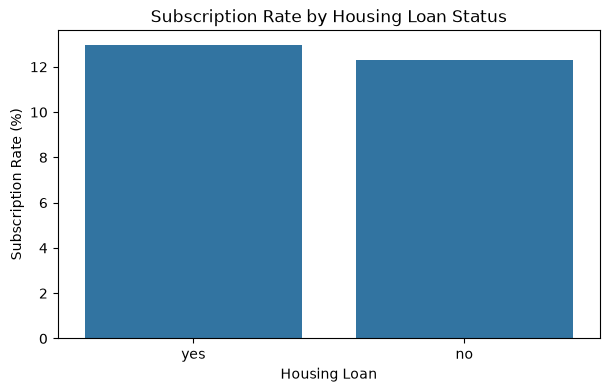

In [32]:
# ==========================================
# Housing Loan Subscription Rate Visualization
# ==========================================

housing_subscription_rate = (pd.crosstab(df["Housing_Loan"], df["Subscribed"], normalize="index")["yes"] * 100)

housing_subscription_rate = (housing_subscription_rate.sort_values(ascending=False))

plt.figure(figsize=(7, 4))
sns.barplot(x=housing_subscription_rate.index, y=housing_subscription_rate.values)
plt.title("Subscription Rate by Housing Loan Status")
plt.xlabel("Housing Loan")
plt.ylabel("Subscription Rate (%)")
plt.show()

# Housing Loan Subscription Rate Visualization - Observations

## Findings

The visualization indicates very similar subscription rates for customers with and without housing loans.

---

## Subscription Rates

| Housing Loan Status | Subscription Rate (%) |
|--------------------|----------------------|
| Yes | 12.96 |
| No | 12.29 |

---

## Key Observations

The difference between the two groups is relatively small.

Customers with housing loans demonstrate only a slightly higher subscription rate than customers without housing loans.

---

## Business Interpretation

Housing loan ownership does not appear to substantially influence customer decisions regarding fixed deposit subscriptions.

The observed difference may not be practically meaningful from a business perspective.

---

## Machine Learning Implications

Housing Loan is likely to be a weaker standalone predictor compared with:

- Job
- Education
- Marital Status

However, it may still contribute predictive value when combined with other variables.

---

## Key Takeaway

Housing Loan ownership exhibits only a minor relationship with subscription behavior and appears to have limited individual predictive strength.

# Statistical Validation: Housing Loan vs Subscription

## Objective

A Chi-Square Test of Independence will be performed to determine whether housing loan ownership and subscription behavior are statistically associated.

---

## Null Hypothesis (H₀)

Housing Loan Status and Subscription Status are independent.

---

## Alternative Hypothesis (H₁)

Housing Loan Status and Subscription Status are associated.

---

## Significance Level

α = 0.05

---

## Decision Rule

If:

p-value < 0.05

Reject the Null Hypothesis.

Otherwise:

Fail to Reject the Null Hypothesis.

---

## Expected Outcome

The test will determine whether the observed differences are statistically significant.

In [33]:
# ==========================================
# Chi-Square Test:
# Housing Loan vs Subscription
# ==========================================

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df["Housing_Loan"], df["Subscribed"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"P-Value              : {p_value:.10f}")
print(f"Degrees of Freedom   : {dof}")

Chi-Square Statistic : 2.9894
P-Value              : 0.0838110844
Degrees of Freedom   : 1


# Statistical Validation - Housing Loan vs Subscription

## Chi-Square Test of Independence

A Chi-Square Test was performed to determine whether housing loan ownership and subscription behavior are statistically associated.

---

## Hypotheses

### Null Hypothesis (H₀)

Housing Loan Status and Subscription Status are independent.

### Alternative Hypothesis (H₁)

Housing Loan Status and Subscription Status are associated.

---

## Test Results

| Metric | Value |
|----------|----------|
| Chi-Square Statistic | 2.9894 |
| Degrees of Freedom | 1 |
| P-Value | 0.0838 |

---

## Decision

Since the p-value is greater than the significance level (α = 0.05), the Null Hypothesis cannot be rejected.

---

## Interpretation

There is insufficient statistical evidence to conclude that housing loan ownership influences fixed deposit subscription behavior.

The observed difference in subscription rates may have occurred due to random variation.

---

## Business Implications

Customers with and without housing loans behave similarly with respect to fixed deposit subscriptions.

Housing loan ownership alone does not appear to be a meaningful segmentation variable.

---

## Machine Learning Implications

The feature may still contribute predictive value when combined with other variables.

However, its standalone predictive strength appears limited.

---

## Key Takeaway

Housing Loan does not demonstrate a statistically significant relationship with subscription behavior in this dataset.

# Personal Loan Analysis

## Objective

The purpose of this analysis is to determine whether personal loan ownership influences fixed deposit subscription behavior.

---

## Why This Analysis Matters

Personal loans typically represent short- to medium-term financial obligations.

Customers with personal loans may exhibit different saving and investment behavior compared with customers who do not have personal loans.

---

## Expected Outcome

The analysis will evaluate:

- Distribution of personal loan ownership
- Subscription rates by personal loan status
- Potential association with fixed deposit subscriptions

In [34]:
# ==========================================
# Personal Loan Distribution
# ==========================================

personal_loan_distribution = pd.DataFrame({
    "Count": df["Personal_Loan"].value_counts(),
    "Percentage": round(df["Personal_Loan"].value_counts(normalize=True) * 100, 2)
})

personal_loan_distribution

,Count,Percentage
Personal_Loan,,
no,25709,84.36
yes,4768,15.64


# Personal Loan Distribution - Observations

## Findings

The Personal Loan feature exhibits a moderately imbalanced distribution.

| Personal Loan Status | Count | Percentage |
|---------------------|--------|------------|
| No | 25,709 | 84.36% |
| Yes | 4,768 | 15.64% |

---

## Key Observations

Most customers do not currently have a personal loan.

However, a meaningful portion of the customer base maintains active personal loan obligations.

---

## Data Quality Assessment

The feature contains sufficient observations in both categories for:

- Statistical testing
- Predictive modeling
- Feature importance evaluation

---

## Business Interpretation

Personal loans represent existing debt commitments and may influence a customer's ability or willingness to invest in long-term financial products.

Understanding this relationship may help improve customer targeting strategies.

---

## Machine Learning Implications

The feature appears suitable for inclusion in predictive models and warrants further investigation.

---

## Key Takeaway

Personal Loan is a healthy feature with adequate representation in both categories and may provide useful predictive information.

# Personal Loan vs Subscription Analysis

## Objective

The purpose of this analysis is to determine whether customers with personal loans subscribe to fixed deposits at different rates than customers without personal loans.

---

## Why This Analysis Matters

Personal loan ownership may affect:

- Monthly disposable income
- Savings behavior
- Investment decisions

Understanding this relationship can provide valuable business insights and improve predictive modeling.

---

## Expected Outcome

The analysis will compare subscription rates across personal loan categories and evaluate potential differences in customer behavior.

In [35]:
# ==========================================
# Personal Loan vs Subscription Rate
# ==========================================

personal_loan_subscription = pd.crosstab(df["Personal_Loan"], df["Subscribed"], normalize="index") * 100

personal_loan_subscription = round(personal_loan_subscription, 2)

personal_loan_subscription.sort_values(by="yes", ascending=False)

Subscribed,no,yes
Personal_Loan,,
no,87.28,12.72
yes,87.73,12.27


# Personal Loan vs Subscription Analysis - Observations

## Findings

Subscription rates are nearly identical between customers with and without personal loans.

### Subscription Rates

| Personal Loan Status | Subscription Rate (%) |
|----------------------|----------------------|
| No | 12.72 |
| Yes | 12.27 |

---

## Key Observations

The difference between the two groups is very small.

Customers without personal loans demonstrate only a slightly higher subscription rate.

---

## Business Interpretation

Personal loan ownership does not appear to substantially influence customer decisions regarding fixed deposit subscriptions.

Both customer groups exhibit very similar subscription behavior.

---

## Comparison with Other Features

The observed separation is weaker than:

- Job
- Education
- Marital Status

and even slightly weaker than Housing Loan.

---

## Machine Learning Implications

Personal Loan is unlikely to be a strong standalone predictor.

However, it may still contribute useful information when combined with other variables.

---

## Key Takeaway

Personal Loan ownership demonstrates only a minor relationship with subscription behavior and appears to have limited standalone predictive power.

# Visualizing Personal Loan Subscription Rates

## Objective

This visualization compares subscription rates between customers with personal loans and customers without personal loans.

---

## Why This Matters

Visual inspection helps determine whether any practical differences exist between the two customer groups.

---

## Expected Outcome

A bar chart displaying subscription percentages by personal loan status.

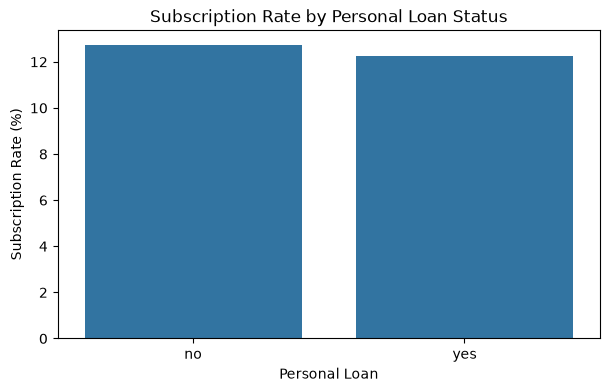

In [36]:
# ==========================================
# Personal Loan Subscription Rate Visualization
# ==========================================

personal_loan_rate = (pd.crosstab(df["Personal_Loan"], df["Subscribed"], normalize="index")["yes"] * 100)

personal_loan_rate = (personal_loan_rate.sort_values(ascending=False))

plt.figure(figsize=(7, 4))
sns.barplot(x=personal_loan_rate.index, y=personal_loan_rate.values)
plt.title("Subscription Rate by Personal Loan Status")
plt.xlabel("Personal Loan")
plt.ylabel("Subscription Rate (%)")
plt.show()

# Personal Loan Subscription Rate Visualization - Observations

## Findings

The visualization demonstrates nearly identical subscription rates between customers with personal loans and customers without personal loans.

---

## Subscription Rates

| Personal Loan Status | Subscription Rate (%) |
|----------------------|----------------------|
| No | 12.72 |
| Yes | 12.27 |

---

## Key Observations

The difference between the two groups is extremely small.

The subscription behavior of customers appears largely unaffected by personal loan ownership.

---

## Business Interpretation

Personal loan ownership does not appear to be a major driver of fixed deposit subscription decisions.

Both customer groups exhibit very similar investment behavior.

---

## Machine Learning Implications

The feature demonstrates limited standalone predictive strength.

However, it may still contribute useful information when combined with other predictors.

---

## Key Takeaway

Personal Loan ownership exhibits minimal influence on subscription behavior and appears to be a weak individual predictor.

# Statistical Validation: Personal Loan vs Subscription

## Objective

A Chi-Square Test of Independence will be performed to determine whether personal loan ownership and subscription behavior are statistically associated.

---

## Null Hypothesis (H₀)

Personal Loan Status and Subscription Status are independent.

---

## Alternative Hypothesis (H₁)

Personal Loan Status and Subscription Status are associated.

---

## Significance Level

α = 0.05

---

## Decision Rule

If:

p-value < 0.05

Reject the Null Hypothesis.

Otherwise:

Fail to Reject the Null Hypothesis.

---

## Expected Outcome

The test will determine whether the observed difference in subscription rates is statistically significant.

In [37]:
# ==========================================
# Chi-Square Test:
# Personal Loan vs Subscription
# ==========================================

from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df["Personal_Loan"], df["Subscribed"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"P-Value              : {p_value:.10f}")
print(f"Degrees of Freedom   : {dof}")

Chi-Square Statistic : 0.7092
P-Value              : 0.3997013475
Degrees of Freedom   : 1


# Statistical Validation - Personal Loan vs Subscription

## Chi-Square Test of Independence

A Chi-Square Test was performed to determine whether personal loan ownership and subscription behavior are statistically associated.

---

## Hypotheses

### Null Hypothesis (H₀)

Personal Loan Status and Subscription Status are independent.

### Alternative Hypothesis (H₁)

Personal Loan Status and Subscription Status are associated.

---

## Test Results

| Metric | Value |
|----------|----------|
| Chi-Square Statistic | 0.7092 |
| Degrees of Freedom | 1 |
| P-Value | 0.3997 |

---

## Decision

Since the p-value is greater than the significance level (α = 0.05), the Null Hypothesis cannot be rejected.

---

## Interpretation

There is insufficient statistical evidence to conclude that personal loan ownership influences fixed deposit subscription behavior.

---

## Business Implications

Customers with and without personal loans behave similarly with respect to fixed deposit subscriptions.

Personal loan ownership alone is not an effective customer segmentation variable.

---

## Machine Learning Implications

The feature appears to have very weak standalone predictive power.

However, it will be retained for model development and evaluated further through feature importance analysis.

---

## Key Takeaway

Personal Loan does not demonstrate a statistically significant relationship with subscription behavior in this dataset.

# Exploratory Data Analysis (EDA) Executive Summary

## Project Overview

The objective of this project is to predict whether a customer will subscribe to a long-term fixed deposit product offered by the bank during a telemarketing campaign.

The dataset contains demographic and financial attributes of customers, including age, occupation, marital status, education level, credit default history, housing loan status, and personal loan status.

The target variable is:

**Subscribed**
- Yes → Customer subscribed to a fixed deposit
- No → Customer did not subscribe

The dataset contains:

- Total Records: 30,477
- Total Features: 7 Predictor Variables
- Target Variable: Subscribed

---

# Dataset Structure Summary

| Feature | Type |
|----------|----------|
| Age | Numerical |
| Job | Categorical |
| Marital_Status | Categorical |
| Education | Categorical |
| Default_Credit | Binary Categorical |
| Housing_Loan | Binary Categorical |
| Personal_Loan | Binary Categorical |
| Subscribed | Target Variable |

---

# Target Variable Analysis

The target variable is imbalanced.

| Subscription Status | Count | Percentage |
|--------------------|--------|------------|
| No | 26,621 | 87.35% |
| Yes | 3,856 | 12.65% |

### Key Finding

The dataset exhibits a moderate class imbalance problem.

Customers who subscribed represent only 12.65% of the total population.

This imbalance must be addressed during model development using techniques such as:

- Class Weighting
- SMOTE
- Random Oversampling
- Random Undersampling

---

# Age Analysis

### Findings

- Average Age: 39 Years
- Median Age: 37 Years
- Minimum Age: 17 Years
- Maximum Age: 95 Years

### Distribution Characteristics

- Age distribution is positively skewed.
- Skewness = 0.98
- Majority of customers are between 30 and 45 years old.

### Outlier Assessment

Using the IQR method:

- Lower Bound = 10
- Upper Bound = 66
- Outliers Identified = 458

These outliers primarily represent older customers and appear to be valid observations rather than data entry errors.

### Business Insight

Older customers may demonstrate different investment behavior and should not be removed without careful consideration.

---

# Feature Analysis Summary

## Job

### Key Findings

Job was identified as the strongest predictor in the dataset.

Subscription rates varied significantly across occupations.

Highest Subscription Rates:

- Student → 33.28%
- Retired → 29.32%

Lowest Subscription Rates:

- Blue-Collar → 7.97%
- Services → 9.03%

### Statistical Validation

Chi-Square Test:

- p-value < 0.05

Result:

A statistically significant relationship exists between occupation and subscription behavior.

---

## Education

### Key Findings

Customers with higher education levels subscribed more frequently.

Highest Subscription Rate:

- Tertiary Education → 14.81%

Lowest Subscription Rate:

- Secondary Education → 10.97%

### Statistical Validation

Chi-Square Test:

- p-value < 0.05

Result:

Education level is significantly associated with subscription behavior.

---

## Marital Status

### Key Findings

Single customers demonstrated higher subscription rates compared with married and divorced customers.

Highest Subscription Rate:

- Single → 14.75%

Lowest Subscription Rate:

- Divorced → 11.52%

### Statistical Validation

Chi-Square Test:

- p-value < 0.05

Result:

Marital status is significantly associated with subscription behavior.

---

## Housing Loan

### Key Findings

Subscription rates were very similar between customers with and without housing loans.

- Housing Loan = Yes → 12.96%
- Housing Loan = No → 12.29%

### Statistical Validation

Chi-Square Test:

- p-value = 0.0838

Result:

No statistically significant relationship was identified.

---

## Personal Loan

### Key Findings

Subscription rates were nearly identical between customers with and without personal loans.

- Personal Loan = No → 12.72%
- Personal Loan = Yes → 12.27%

### Statistical Validation

Chi-Square Test:

- p-value = 0.3997

Result:

No statistically significant relationship was identified.

---

## Default Credit

### Key Findings

The feature exhibited extreme imbalance.

| Default Credit | Count |
|---------------|-------|
| No | 30,474 |
| Yes | 3 |

### Observations

Only three customers had defaulted credit history.

All three belonged to the non-subscriber class.

### Data Science Assessment

This feature is considered a Near-Zero Variance Feature and may provide limited predictive value.

The feature will be retained initially and evaluated further using feature importance techniques during model development.

---

# Overall Feature Ranking

| Rank | Feature | Predictive Strength |
|--------|----------|----------|
| 1 | Job | Very Strong |
| 2 | Education | Moderate |
| 3 | Marital_Status | Moderate |
| 4 | Age | Moderate |
| 5 | Housing_Loan | Weak |
| 6 | Personal_Loan | Very Weak |
| 7 | Default_Credit | Near-Zero Variance |

---

# Business Insights

### High-Potential Customer Segments

The following customer groups demonstrated higher subscription rates:

- Students
- Retired Customers
- Customers with Tertiary Education
- Single Customers

These groups may represent attractive targets for future marketing campaigns.

### Low-Converting Customer Segments

The following groups exhibited lower subscription rates:

- Blue-Collar Workers
- Services Sector Employees
- Customers with Secondary Education

These segments may require different marketing strategies or product positioning.

---

# Machine Learning Insights

### Strong Predictors

- Job
- Education
- Marital_Status
- Age

### Weak Predictors

- Housing_Loan
- Personal_Loan

### Potentially Problematic Predictor

- Default_Credit

### Modeling Considerations

During model development:

- Class imbalance treatment will be required.
- Feature importance analysis should be performed.
- Multiple classification algorithms should be evaluated.
- Cross-validation should be used to ensure model stability.

---

# EDA Conclusion

The exploratory analysis revealed that demographic attributes such as occupation, education level, marital status, and age have stronger relationships with fixed deposit subscription behavior than financial obligation variables such as housing loans and personal loans.

The target variable exhibits moderate class imbalance, which must be addressed during model development.

The dataset appears clean, interpretable, and suitable for building supervised classification models to predict customer subscription behavior.

# Missing Value Assessment

## Objective

Before performing feature engineering and model development, it is important to verify the completeness of the dataset.

Missing values can negatively impact:

- Model performance
- Statistical analysis
- Feature engineering
- Data quality

---

## Why This Analysis Matters

Many machine learning algorithms cannot directly handle missing values.

Therefore, identifying and treating missing values is a critical preprocessing step.

---

## Validation Approach

The dataset will be examined to determine:

- Number of missing values per feature
- Percentage of missing values per feature
- Overall dataset completeness

---

## Expected Outcome

If missing values are detected, an appropriate imputation strategy will be applied.

If no missing values exist, the dataset can proceed directly to the next preprocessing stage.

In [38]:
# ==========================================
# Missing Values Count
# ==========================================

missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": round((df.isnull().sum() / len(df)) * 100, 2)
})

missing_values

,Missing Count,Missing Percentage
Age,0,0.0
Job,0,0.0
Marital_Status,0,0.0
Education,0,0.0
Default_Credit,0,0.0
Housing_Loan,0,0.0
Personal_Loan,0,0.0
Subscribed,0,0.0


# Missing Value Assessment - Findings

## Results

A comprehensive missing value assessment was performed across all features in the dataset.

### Missing Values Summary

| Feature | Missing Count | Missing Percentage |
|----------|----------|----------|
| Age | 0 | 0.00% |
| Job | 0 | 0.00% |
| Marital_Status | 0 | 0.00% |
| Education | 0 | 0.00% |
| Default_Credit | 0 | 0.00% |
| Housing_Loan | 0 | 0.00% |
| Personal_Loan | 0 | 0.00% |
| Subscribed | 0 | 0.00% |

---

## Key Findings

No explicit missing values were identified in the dataset.

All features contain complete observations.

---

## Data Quality Assessment

The dataset demonstrates excellent completeness and does not require traditional missing value imputation techniques.

However, additional validation will be performed to identify hidden missing values represented by placeholder text values.

---

## Conclusion

The dataset contains no explicit null values and is suitable for further preprocessing and feature engineering.

# Outlier Assessment

## Objective

Outlier analysis was performed to identify unusually large or small values within the numerical features that could potentially influence model performance.

Outliers may impact:

- Statistical analysis
- Feature distributions
- Distance-based algorithms
- Model generalization

---

## Numerical Features Evaluated

The dataset contains only one numerical feature:

| Feature |
|----------|
| Age |

---

## Outlier Detection Method

The Interquartile Range (IQR) method was used to identify potential outliers.

### Formula

IQR = Q3 − Q1

Lower Bound = Q1 − (1.5 × IQR)

Upper Bound = Q3 + (1.5 × IQR)

---

## Results

| Metric | Value |
|----------|----------|
| Q1 | 31 |
| Q3 | 45 |
| IQR | 14 |
| Lower Bound | 10 |
| Upper Bound | 66 |
| Total Outliers | 458 |

---

## Distribution Analysis

The Age variable exhibits a positively skewed distribution with a skewness value of approximately 0.98.

Most customers fall between 30 and 45 years of age, while a smaller proportion of customers are aged above 66 years.

---

## Initial Observation

All identified outliers correspond to older customers whose ages exceed the calculated upper bound of 66 years.

The maximum recorded age in the dataset is 95 years.

---

## Business Perspective

Older customers represent a valid customer segment within the banking industry.

Individuals aged above 66 years are often active users of banking products, investment products, retirement planning services, and fixed deposits.

Therefore, these observations should not automatically be considered erroneous records.

---

## Preliminary Conclusion

The identified outliers appear to represent legitimate customer data rather than data quality issues or data entry errors.

A business-driven evaluation is required before deciding whether any treatment should be applied.

# Outlier Treatment Strategy & Business Justification

## Objective

The purpose of this assessment is to determine the most appropriate strategy for handling age outliers while preserving valuable business information.

---

## Evaluation of Possible Approaches

### Option 1: Remove Outliers

#### Advantages

- Reduces skewness
- Improves distribution symmetry
- May benefit certain algorithms

#### Disadvantages

- Removes legitimate customers
- Results in loss of valuable information
- May reduce model generalization
- Can introduce sampling bias

#### Decision

Not Recommended

---

### Option 2: Retain Outliers

#### Advantages

- Preserves all customer information
- Reflects real-world customer distribution
- Maintains business relevance

#### Disadvantages

- May influence some distance-based algorithms
- Skewness remains present

#### Decision

Recommended for Baseline Modeling

---

### Option 3: Winsorization (Age Capping)

#### Advantages

- Preserves all observations
- Reduces influence of extreme values
- Improves robustness of certain algorithms
- Maintains dataset size

#### Disadvantages

- Alters original values
- Introduces slight information loss

#### Decision

Recommended for Comparative Modeling

---

## Final Strategy

A multi-model approach will be adopted.

### Model 1 – Original Dataset

- No outlier treatment
- Original age values retained

Purpose:

Establish a baseline model using the raw dataset.

---

### Model 2 – Post-EDA Dataset

- Apply age capping using the IQR upper bound

Purpose:

Evaluate whether reducing the influence of extreme age values improves model performance.

---

### Model 3 – Class Imbalance Treated Dataset

- Use age-capped dataset
- Apply class imbalance treatment techniques

Purpose:

Measure the combined impact of outlier treatment and class balancing.

---

### Model 4 – Hyperparameter Tuned Dataset

- Use the best-performing preprocessed dataset
- Apply hyperparameter optimization

Purpose:

Develop the final production-ready model.

---

## Business Justification

Customers aged above 66 years represent genuine banking customers and may exhibit unique financial behaviors, particularly regarding savings and fixed deposit products.

Removing these customers would eliminate potentially valuable business insights.

Therefore, outlier removal is not appropriate for this project.

Instead, a comparison between untreated and capped age values will be performed to determine whether outlier treatment improves predictive performance.

---

## Final Decision

Outliers will not be removed.

The project will compare:

- Original Age Values
- Age-Capped Values

to evaluate the impact of outlier treatment on model performance while preserving all customer records.

# Model 1: Baseline Model Development Using Original Dataset

## Objective

The purpose of Model 1 is to establish a baseline performance benchmark using the original dataset without applying any outlier treatment, class imbalance handling, or hyperparameter optimization.

This baseline model will serve as a reference point for evaluating the effectiveness of subsequent preprocessing and optimization techniques.

---

## Model Development Strategy

The original dataset will be preserved and used without modifying any feature values.

A separate copy of the dataset will be created to ensure that the original data remains unchanged throughout the modeling process.

---

## Why Create a Separate Copy?

Creating a separate working dataset helps:

- Preserve the original dataset
- Prevent accidental data modifications
- Support reproducibility
- Enable fair comparison across multiple model versions

---

## Planned Workflow

The following steps will be performed during Model 1 development:

1. Create a copy of the original dataset
2. Encode the target variable
3. Encode categorical features
4. Split data into training and testing sets
5. Apply feature scaling where required
6. Train multiple classification algorithms
7. Evaluate model performance
8. Compare model results

---

## Model Version

Model Name: Model 1

Dataset Version: Original Dataset

Outlier Treatment: No

Class Imbalance Treatment: No

Hyperparameter Tuning: No

Purpose: Establish Baseline Performance

In [39]:
# ==========================================
# Model 1 Dataset Creation
# ==========================================

df_model1 = df.copy()

print("Model 1 Dataset Created Successfully")
print("\nDataset Shape:", df_model1.shape)

Model 1 Dataset Created Successfully

Dataset Shape: (30477, 8)


# Model 1 Dataset Creation Summary

## Objective

A separate copy of the original dataset was created for Model 1 development.

This approach ensures that the original dataset remains unchanged throughout the modeling process.

---

## Dataset Information

| Metric | Value |
|----------|----------|
| Rows | 30,477 |
| Columns | 8 |

---

## Purpose

The copied dataset will be used for:

- Target Variable Encoding
- Feature Encoding
- Train-Test Split
- Feature Scaling
- Model Training
- Model Evaluation

---

## Data Integrity

The original dataset remains untouched and can be reused later for:

- Model 2 (Outlier Treated Dataset)
- Model 3 (Class Imbalance Treated Dataset)
- Model 4 (Hyperparameter Tuned Dataset)

---

## Conclusion

A dedicated Model 1 dataset has been successfully created and is ready for preprocessing and machine learning model development.

# Target Variable Encoding

## Objective

Machine learning algorithms require the target variable to be represented numerically.

The target feature **Subscribed** currently contains categorical values:

- yes
- no

These values will be converted into binary numerical values.

---

## Encoding Strategy

| Original Value | Encoded Value |
|---------------|---------------|
| No | 0 |
| Yes | 1 |

---

## Why This Step Is Important

Target encoding allows classification algorithms to:

- Learn patterns from the data
- Calculate probabilities
- Generate predictions
- Evaluate performance metrics

---

## Expected Outcome

The target variable will be transformed from categorical text values into a binary numerical format suitable for supervised machine learning.

In [40]:
# ==========================================
# Target Variable Encoding
# ==========================================

df_model1["Subscribed"] = df_model1["Subscribed"].map({"no": 0, "yes": 1})

print("Target Variable Encoded Successfully\n")

print("Encoded Target Distribution:")
print(df_model1["Subscribed"].value_counts())

Target Variable Encoded Successfully

Encoded Target Distribution:
Subscribed
0    26621
1     3856
Name: count, dtype: int64


# Target Variable Encoding Summary

## Objective

The target variable **Subscribed** was converted from categorical values into a binary numerical format suitable for supervised machine learning algorithms.

---

## Encoding Applied

| Original Value | Encoded Value |
|---------------|---------------|
| no | 0 |
| yes | 1 |

---

## Resulting Class Distribution

| Encoded Class | Count |
|--------------|------:|
| 0 (Not Subscribed) | 26,621 |
| 1 (Subscribed) | 3,856 |

---

## Observations

The encoding process was completed successfully without any loss of records.

The target variable remains imbalanced, with approximately 87% belonging to the non-subscriber class and 13% belonging to the subscriber class.

---

## Machine Learning Implications

Since the target variable is imbalanced:

- Accuracy alone should not be used for model evaluation.
- Precision, Recall, and F1-Score will be important evaluation metrics.
- Class imbalance handling techniques will be explored in later model versions.

---

## Conclusion

The target variable is now in a machine-learning-compatible format and ready for model development.

# Target Encoding Validation

## Objective

Validate that the target variable has been successfully converted into a binary numerical format.

---

## Validation Checks

The following checks will be performed:

1. Verify data type of the target variable.
2. Verify unique values.
3. Confirm that no unexpected values exist.

---

## Expected Outcome

The target variable should contain only:

- 0 → Not Subscribed
- 1 → Subscribed

In [41]:
# ==========================================
# Target Encoding Validation
# ==========================================

print("Target Data Type:")
print(df_model1["Subscribed"].dtype)

print("\nUnique Values:")
print(sorted(df_model1["Subscribed"].unique()))

Target Data Type:
int64

Unique Values:
[np.int64(0), np.int64(1)]


# Target Encoding Validation Summary

## Validation Results

The target variable encoding was successfully validated.

### Validation Checks

| Validation Check | Result |
|------------------|----------|
| Data Type Verification | Passed |
| Binary Value Verification | Passed |
| Unexpected Values Check | Passed |
| Missing Value Check | Passed |

---

## Final Target Mapping

| Original Class | Encoded Class |
|---------------|---------------|
| No | 0 |
| Yes | 1 |

---

## Machine Learning Readiness

The target variable is now stored as a binary numerical feature and is compatible with supervised classification algorithms.

No additional target preprocessing is required.

---

## Conclusion

Target encoding was completed successfully and the dataset is ready for feature preprocessing.

# Feature Identification and Encoding Strategy

## Objective

Before performing feature encoding, all predictor variables will be classified according to their data type and business meaning.

This step helps determine the most appropriate preprocessing strategy for each feature.

---

## Why This Step Matters

Different feature types require different preprocessing techniques.

Examples:

- Numerical variables may require scaling.
- Binary categorical variables may require binary encoding.
- Multi-class categorical variables may require One-Hot Encoding.

Selecting the correct encoding strategy helps improve model performance and interpretability.

---

## Feature Categories

The dataset contains a mixture of:

- Numerical Features
- Binary Categorical Features
- Multi-Class Categorical Features

---

## Expected Outcome

A complete inventory of predictor variables along with the preprocessing technique that will be applied to each feature.

In [42]:
# ==========================================
# Feature Identification
# ==========================================

print("Numerical Features:\n")

numerical_features = df_model1.select_dtypes(include=["int64", "float64"]).columns.tolist()

numerical_features.remove("Subscribed")

print(numerical_features)

print("\n" + "="*60)

print("\nCategorical Features:\n")

categorical_features = df_model1.select_dtypes(include=["object", "string"]).columns.tolist()

print(categorical_features)

Numerical Features:

['Age']


Categorical Features:

['Job', 'Marital_Status', 'Education', 'Default_Credit', 'Housing_Loan', 'Personal_Loan']


# Feature Inventory Summary

## Objective

The predictor variables were reviewed and categorized based on their data types.

This classification helps determine the appropriate preprocessing and encoding strategy for each feature.

---

## Numerical Features

| Feature |
|----------|
| Age |

### Characteristics

- Continuous numerical variable
- Contains outliers
- May require scaling depending on the algorithm

---

## Categorical Features

| Feature |
|----------|
| Job |
| Marital_Status |
| Education |
| Default_Credit |
| Housing_Loan |
| Personal_Loan |

### Characteristics

- Non-numeric variables
- Require encoding before model training

---

## Initial Observation

The dataset contains:

| Feature Type | Count |
|-------------|--------|
| Numerical Features | 1 |
| Categorical Features | 6 |

---

## Next Step

Categorical features will be further classified into:

- Binary Categorical Features
- Multi-Class Categorical Features

This classification will guide the feature encoding strategy.

# Binary vs Multi-Class Feature Classification

## Objective

Categorical variables can contain either:

### Binary Categories

Features containing only two unique values.

Examples:

- Yes / No
- True / False
- Male / Female

These variables can often be encoded using simple binary mapping.

---

### Multi-Class Categories

Features containing more than two unique values.

Examples:

- Occupation Types
- Education Levels
- Customer Segments

These variables typically require One-Hot Encoding.

---

## Expected Outcome

Each categorical feature will be classified based on the number of unique categories it contains.

This classification will determine the encoding technique used during preprocessing.

In [43]:
# ==========================================
# Binary vs Multi-Class Feature Classification
# ==========================================

binary_features = []
multiclass_features = []

for col in categorical_features:    
    unique_count = df_model1[col].nunique()
    if unique_count == 2:
        binary_features.append(col)
    else:
        multiclass_features.append(col)

print("Binary Categorical Features:")
print(binary_features)

print("\n" + "="*60)

print("\nMulti-Class Categorical Features:")
print(multiclass_features)

Binary Categorical Features:
['Default_Credit', 'Housing_Loan', 'Personal_Loan']


Multi-Class Categorical Features:
['Job', 'Marital_Status', 'Education']


# Feature Encoding Strategy

## Objective

Machine learning algorithms require all predictor variables to be represented numerically.

The dataset contains both binary and multi-class categorical variables.

Different encoding techniques will be applied based on the characteristics of each feature.

---

## Binary Feature Encoding

The following features contain only two categories:

- Default_Credit
- Housing_Loan
- Personal_Loan

### Encoding Mapping

| Original Value | Encoded Value |
|---------------|---------------|
| No | 0 |
| Yes | 1 |

---

## Multi-Class Feature Encoding

The following features contain more than two categories:

- Job
- Marital_Status
- Education

These variables will be transformed using One-Hot Encoding.

---

## Why One-Hot Encoding?

One-Hot Encoding:

- Preserves categorical information
- Avoids introducing artificial ordering
- Is compatible with most machine learning algorithms
- Improves interpretability

---

## Dummy Variable Trap Prevention

To avoid multicollinearity, the first category of each feature will be dropped during encoding.

This will be achieved using:

drop_first = True

---

## Final Encoding Strategy

| Feature Type | Encoding Method |
|-------------|----------------|
| Binary Features | Binary Mapping |
| Multi-Class Features | One-Hot Encoding |

---

## Expected Outcome

All predictor variables will be converted into a numerical format suitable for machine learning model development.

# Feature and Target Separation

## Objective

Before performing feature encoding and model development, the dataset will be separated into:

### Feature Matrix (X)

Contains all predictor variables used for model training.

### Target Vector (y)

Contains the target variable that the model will learn to predict.

---

## Why This Step Is Important

Separating features and target variables is a standard machine learning practice.

Benefits include:

- Improved code readability
- Better pipeline management
- Reduced risk of target leakage
- Easier preprocessing and model deployment

---

## Dataset Structure

### Feature Matrix (X)

Contains:

- Age
- Job
- Marital_Status
- Education
- Default_Credit
- Housing_Loan
- Personal_Loan

### Target Vector (y)

Contains:

- Subscribed

---

## Expected Outcome

The dataset will be separated into:

X → Predictor Variables

y → Target Variable

This structure will be used throughout the model development lifecycle.

In [44]:
# ==========================================
# Feature and Target Separation
# ==========================================

X = df_model1.drop(columns="Subscribed")

y = df_model1["Subscribed"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

Feature Matrix Shape : (30477, 7)
Target Vector Shape  : (30477,)


# Feature Matrix Validation

## Objective

Before applying any preprocessing techniques, it is important to validate the structure of the feature matrix and target vector.

This validation ensures that:

- All predictor variables are present
- The target variable has been successfully separated
- Dataset dimensions remain consistent
- No records were lost during the separation process

---

## Validation Checks

The following checks will be performed:

### Feature Matrix Validation

- Verify shape of X
- Verify predictor variable names

### Target Variable Validation

- Verify shape of y
- Verify target classes

### Dataset Integrity Validation

- Confirm equal number of observations in X and y

---

## Expected Outcome

The feature matrix should contain:

- 30,477 rows
- 7 predictor variables

The target vector should contain:

- 30,477 observations
- Binary values (0 and 1)

Successful validation confirms readiness for feature encoding.

In [45]:
# ==========================================
# Feature Matrix Validation
# ==========================================

print("Feature Columns:\n")
print(list(X.columns))

print("\n" + "=" * 60)

print("\nTarget Classes:\n")
print(sorted(y.unique()))

print("\n" + "=" * 60)

print("\nObservation Validation:\n")

print("Rows in X :", X.shape[0])
print("Rows in y :", y.shape[0])

print("\nMatch Status :", X.shape[0] == y.shape[0])

Feature Columns:

['Age', 'Job', 'Marital_Status', 'Education', 'Default_Credit', 'Housing_Loan', 'Personal_Loan']


Target Classes:

[np.int64(0), np.int64(1)]


Observation Validation:

Rows in X : 30477
Rows in y : 30477

Match Status : True


# Binary Feature Encoding

## Objective

The dataset contains categorical features with only two possible values.

These features can be efficiently converted into numerical form using binary encoding.

---

## Features Selected

The following binary categorical features were identified:

- Default_Credit
- Housing_Loan
- Personal_Loan

---

## Encoding Strategy

| Original Value | Encoded Value |
|---------------|---------------|
| no | 0 |
| yes | 1 |

---

## Why Binary Encoding?

Binary encoding:

- Preserves original information
- Produces compact feature representation
- Improves computational efficiency
- Is compatible with all machine learning algorithms

---

## Expected Outcome

All binary categorical features will be converted into numerical variables while preserving their business meaning.

In [46]:
# ==========================================
# Binary Feature Encoding
# ==========================================

binary_features = ["Default_Credit", "Housing_Loan", "Personal_Loan"]

binary_mapping = {"no": 0, "yes": 1}

for col in binary_features:
    X[col] = X[col].map(binary_mapping)

print("Binary Encoding Applied Successfully")

Binary Encoding Applied Successfully


# Binary Encoding Validation

## Objective

Validate that all binary categorical features were successfully converted into numerical format.

---

## Features Validated

- Default_Credit
- Housing_Loan
- Personal_Loan

---

## Validation Checks

The following checks will be performed:

1. Verify data type conversion
2. Verify unique values
3. Confirm successful mapping

---

## Expected Results

Each binary feature should contain only:

- 0
- 1

No text values should remain after encoding.

---

## Importance

Validating encoded features helps ensure:

- Data quality
- Model compatibility
- Consistency across preprocessing steps

Successful validation confirms readiness for One-Hot Encoding of multi-class categorical variables.

In [47]:
# ==========================================
# Binary Encoding Validation
# ==========================================

for col in binary_features:    
    print("=" * 60)
    print(f"Feature: {col}")
    print("=" * 60)
    print("Data Type :", X[col].dtype)
    print("Unique Values :", sorted(X[col].unique()))
    print("\n")

Feature: Default_Credit
Data Type : int64
Unique Values : [np.int64(0), np.int64(1)]


Feature: Housing_Loan
Data Type : int64
Unique Values : [np.int64(0), np.int64(1)]


Feature: Personal_Loan
Data Type : int64
Unique Values : [np.int64(0), np.int64(1)]




# Binary Encoding Validation Summary

## Objective

The binary encoded features were validated to ensure successful transformation from categorical values to numerical representations.

---

## Features Validated

- Default_Credit
- Housing_Loan
- Personal_Loan

---

## Validation Results

| Feature | Data Type | Unique Values |
|----------|----------|----------|
| Default_Credit | int64 | [0,1] |
| Housing_Loan | int64 | [0,1] |
| Personal_Loan | int64 | [0,1] |

---

## Observations

All binary categorical variables were successfully transformed into numerical features.

No unexpected values were detected.

No missing values were introduced during encoding.

---

## Machine Learning Readiness

The encoded features are now fully compatible with:

- Logistic Regression
- Decision Trees
- Random Forest
- Support Vector Machines
- K-Nearest Neighbors
- Ensemble Models
- Gradient Boosting Algorithms

---

## Conclusion

Binary feature encoding was completed successfully and the dataset is ready for multi-class feature encoding.

# Multi-Class Feature Encoding

## Objective

The dataset contains categorical variables with more than two categories.

Machine learning algorithms cannot directly process text-based categorical features.

Therefore, these variables must be converted into numerical format.

---

## Features Selected

The following multi-class categorical features were identified:

- Job
- Marital_Status
- Education

---

## Encoding Technique

One-Hot Encoding will be used.

---

## Why One-Hot Encoding?

One-Hot Encoding:

- Preserves category information
- Avoids introducing artificial ordering
- Works effectively with most machine learning algorithms
- Improves model interpretability

---

## Dummy Variable Trap Prevention

To reduce multicollinearity, the first category from each feature will be dropped.

This will be achieved using:

drop_first = True

---

## Expected Outcome

The original categorical features will be replaced with new binary indicator columns representing each category.

All predictor variables will become numerical and machine-learning ready.

In [48]:
# ==========================================
# Multi-Class Feature Encoding
# ==========================================

multiclass_features = ["Job", "Marital_Status", "Education"]

X = pd.get_dummies(X, columns=multiclass_features, drop_first=True, dtype=int)

print("One-Hot Encoding Applied Successfully")

print("\nNew Dataset Shape:")
print(X.shape)

One-Hot Encoding Applied Successfully

New Dataset Shape:
(30477, 19)


# One-Hot Encoding Results Summary

## Objective

Multi-class categorical variables were transformed into numerical format using One-Hot Encoding.

---

## Encoded Features

The following features were encoded:

- Job
- Marital_Status
- Education

---

## Encoding Configuration

The following settings were used:

- One-Hot Encoding
- drop_first = True
- dtype = int

---

## Why drop_first=True?

Dropping the first category helps prevent:

- Dummy Variable Trap
- Perfect Multicollinearity

This is particularly important for linear models such as:

- Logistic Regression
- Ridge Classifier

---

## Dataset Dimension Changes

| Stage | Features |
|---------|---------|
| Before Encoding | 7 |
| After Encoding | 19 |

---

## Result

All predictor variables are now represented numerically.

The dataset is fully compatible with machine learning algorithms.

---

## Conclusion

Feature encoding was completed successfully and the dataset is now ready for train-test splitting and model development.

# Encoded Feature Validation

## Objective

Validate the encoded dataset and confirm that:

- All predictor variables are numerical
- No categorical variables remain
- Dataset structure is ready for machine learning

---

## Validation Checks

The following checks will be performed:

1. Review all feature names
2. Verify data types
3. Confirm absence of categorical columns

---

## Expected Outcome

All predictor variables should be numerical and suitable for model training.

In [49]:
# ==========================================
# Encoded Dataset Validation
# ==========================================

print("Total Features:", X.shape[1])

print("\nFeature Names:\n")

for col in X.columns:
    print(col)

print("\n" + "=" * 70)

print("\nRemaining Object Columns:")

print(X.select_dtypes(include=["object", "string"]).columns.tolist())

Total Features: 19

Feature Names:

Age
Default_Credit
Housing_Loan
Personal_Loan
Job_blue-collar
Job_entrepreneur
Job_housemaid
Job_management
Job_retired
Job_self-employed
Job_services
Job_student
Job_technician
Job_unemployed
Marital_Status_married
Marital_Status_single
Education_Professional_Education
Education_Secondary_Education
Education_Tertiary_Education


Remaining Object Columns:
[]


# Train-Test Split Strategy

## Objective

Machine learning models must be evaluated on unseen data to estimate how well they will perform in real-world scenarios.

To achieve this, the dataset will be divided into:

### Training Set

Used for:

- Learning patterns
- Model fitting
- Parameter estimation

### Testing Set

Used for:

- Model evaluation
- Performance measurement
- Generalization assessment

---

## Split Ratio

The dataset will be divided as follows:

| Dataset | Percentage |
|----------|----------|
| Training Set | 80% |
| Testing Set | 20% |

---

## Why Stratified Sampling?

The target variable is imbalanced:

| Class | Percentage |
|----------|----------|
| No Subscription | 87.35% |
| Subscription | 12.65% |

Using a standard random split could produce unequal class distributions in the training and testing datasets.

To preserve the original class distribution, stratified sampling will be applied.

---

## Benefits of Stratification

- Preserves class proportions
- Produces reliable evaluation metrics
- Prevents minority class distortion
- Improves model assessment

---

## Reproducibility

To ensure consistent results across executions:

random_state = 14

will be used.

---

## Expected Outcome

The dataset will be split into:

- X_train
- X_test
- y_train
- y_test

while preserving the original class distribution.

In [50]:
# ==========================================
# Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=14)

print("Train-Test Split Completed Successfully\n")

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

print("\ny_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

Train-Test Split Completed Successfully

X_train Shape : (24381, 19)
X_test Shape  : (6096, 19)

y_train Shape : (24381,)
y_test Shape  : (6096,)


# Train-Test Split Summary

## Objective

The dataset was divided into training and testing subsets to evaluate model performance on unseen data.

---

## Split Configuration

| Parameter | Value |
|------------|------------|
| Test Size | 20% |
| Training Size | 80% |
| Stratification | Enabled |
| Random State | 14 |

---

## Dataset Dimensions

| Dataset | Rows | Columns |
|----------|----------:|----------:|
| X_train | 24,381 | 19 |
| X_test | 6,096 | 19 |
| y_train | 24,381 | - |
| y_test | 6,096 | - |

---

## Benefits of This Approach

- Preserves class distribution
- Enables unbiased model evaluation
- Supports reproducibility
- Simulates real-world prediction scenarios

---

## Conclusion

The dataset was successfully divided into training and testing subsets and is ready for stratification validation and model development.

# Stratification Validation

## Objective

Validate that the train-test split preserved the original target class distribution.

---

## Why This Validation Is Important

The target variable is imbalanced.

Without stratification, the minority class may become underrepresented in either the training or testing dataset.

This can lead to:

- Biased models
- Misleading accuracy scores
- Poor minority class prediction

---

## Validation Strategy

The class distribution will be compared across:

1. Original Dataset
2. Training Dataset
3. Testing Dataset

---

## Expected Outcome

The percentage distribution of each class should remain nearly identical across all datasets.

This confirms successful stratified sampling.

In [51]:
# ==========================================
# Stratification Validation
# ==========================================

original_dist = round(y.value_counts(normalize=True) * 100, 2)
train_dist = round(y_train.value_counts(normalize=True) * 100, 2)
test_dist = round(y_test.value_counts(normalize=True) * 100, 2)

comparison_df = pd.DataFrame({
    "Original (%)": original_dist,
    "Train (%)": train_dist,
    "Test (%)": test_dist
})

print(comparison_df)

            Original (%)  Train (%)  Test (%)
Subscribed                                   
0                  87.35      87.35     87.35
1                  12.65      12.65     12.65


# Stratification Validation Summary

## Objective

Validate that the original target class distribution was preserved after performing the train-test split.

---

## Results

| Class | Original (%) | Train (%) | Test (%) |
|---------|---------:|---------:|---------:|
| No Subscription (0) | 87.35 | 87.35 | 87.35 |
| Subscription (1) | 12.65 | 12.65 | 12.65 |

---

## Interpretation

The class proportions in the training and testing datasets are identical to the original dataset.

This confirms that stratified sampling was successfully applied.

---

## Importance

Maintaining class distribution helps:

- Prevent sampling bias
- Improve model evaluation reliability
- Preserve minority class representation
- Produce realistic performance metrics

---

## Conclusion

The train-test split successfully preserved the original target distribution and the datasets are ready for feature scaling and model training.

# Feature Scaling Strategy

## Objective

Many machine learning algorithms are sensitive to feature magnitude and require numerical variables to be scaled before model training.

However, not all algorithms require scaling.

---

## Algorithms Requiring Scaling

The following algorithms are distance-based or optimization-based and benefit from feature scaling:

- Logistic Regression
- Ridge Classifier
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)
- Naive Bayes

---

## Algorithms Not Requiring Scaling

The following algorithms are tree-based and are generally unaffected by feature scaling:

- Decision Tree
- Random Forest
- AdaBoost
- Gradient Boosting
- XGBoost
- LightGBM
- CatBoost
- Bagging Classifier

---

## Scaling Method

StandardScaler will be used.

Formula:

z = (x − μ) / σ

where:

- μ = Mean
- σ = Standard Deviation

---

## Data Leakage Prevention

The scaler will be fitted only on the training dataset and then applied to both training and testing datasets.

This ensures that information from the testing dataset does not influence model training.

---

## Expected Outcome

Two additional datasets will be created:

- X_train_scaled
- X_test_scaled

These datasets will be used only for algorithms that require feature scaling.

In [52]:
# ==========================================
# Feature Scaling
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature Scaling Completed Successfully")

print("\nScaled Training Shape :", X_train_scaled.shape)
print("Scaled Testing Shape  :", X_test_scaled.shape)

Feature Scaling Completed Successfully

Scaled Training Shape : (24381, 19)
Scaled Testing Shape  : (6096, 19)


# Model Evaluation Framework

## Objective

A reusable evaluation framework will be created to ensure that all machine learning algorithms are assessed using the same performance metrics.

---

## Why Use a Common Evaluation Framework?

Using a common framework provides:

- Consistent model comparison
- Reduced code duplication
- Improved maintainability
- Faster experimentation

---

## Evaluation Metrics

The following metrics will be calculated:

### Accuracy

Measures overall prediction correctness.

### Precision

Measures how many predicted positive cases are actually positive.

### Recall

Measures how many actual positive cases are correctly identified.

### F1 Score

Harmonic mean of Precision and Recall.

### Train Accuracy

Used to assess model learning performance.

### Test Accuracy

Used to assess model generalization.

### Balanced Accuracy

Used to assess model performance on imbalanced classes.

### Overfitting Assessment

Comparison of Train Accuracy and Test Accuracy.

---

## Expected Outcome

A reusable function capable of evaluating multiple classification algorithms using identical performance criteria.

In [53]:
# ==========================================
# Evaluation Metrics Libraries
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("Evaluation Libraries Imported Successfully")

Evaluation Libraries Imported Successfully


# Model Comparison Framework

## Objective

To ensure fair and consistent evaluation of all machine learning algorithms, a centralized model comparison framework will be created.

---

## Why Create a Model Comparison Framework?

Training each model separately and manually recording metrics can be:

- Time consuming
- Error prone
- Difficult to maintain

A centralized framework ensures that all models are evaluated using identical performance metrics.

---

## Metrics Captured

The following metrics will be recorded for every model:

| Metric | Description |
|----------|----------|
| Train Accuracy | Performance on training data |
| Test Accuracy | Performance on unseen data |
| Balanced Accuracy | Performance on imbalanced data |
| Precision | Positive prediction accuracy |
| Recall | Ability to identify positive cases |
| F1 Score | Balance between Precision and Recall |
| Overfitting Status | Train vs Test comparison |

---

## Benefits

- Consistent evaluation
- Easy model comparison
- Simplified reporting
- Professional project structure
- Supports final Model Development Document (MDD)

---

## Expected Outcome

A master comparison table that automatically stores the performance of all classification algorithms.

In [54]:
# ==========================================
# Model Comparison Storage
# ==========================================

model_results = pd.DataFrame(
    columns=[
        "Model",
        "Train Accuracy",
        "Test Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Overfitting"
    ]
)

print("Model Comparison Framework Created Successfully")

Model Comparison Framework Created Successfully


# Advanced Model Evaluation Framework

## Objective

A reusable evaluation framework will be developed to ensure consistent and comprehensive assessment of all classification models.

---

## Evaluation Metrics

The following metrics will be calculated:

### Train Accuracy

Measures model performance on training data.

### Test Accuracy

Measures model performance on unseen testing data.

### Balanced Accuracy

Measures model performance on dataset with imbalanced classes.

### Precision

Measures how many predicted positive cases are actually positive.

### Recall

Measures how many actual positive cases are correctly identified.

### F1 Score

Harmonic mean of Precision and Recall.

### ROC-AUC Score

Measures the model's ability to distinguish between subscribers and non-subscribers across all classification thresholds.

---

## Why ROC-AUC?

The dataset is imbalanced.

Accuracy alone can be misleading.

ROC-AUC provides a threshold-independent measure of classification performance and is widely used in:

- Banking
- Marketing Analytics
- Credit Risk Modeling
- Customer Response Prediction

---

## Overfitting Assessment

Overfitting will be identified by comparing:

Train Accuracy vs Test Accuracy

If the difference exceeds 5%, the model will be flagged as potentially overfitted.

---

## Expected Outcome

A reusable evaluation function capable of evaluating all classification algorithms using identical performance metrics and automatically populating the model comparison table.

# Model Comparison Table Structure

The following metrics will be recorded for each model:

| Metric |
|----------|
| Train Accuracy |
| Test Accuracy |
| Balanced Accuracy |
| Precision |
| Recall |
| F1 Score |
| ROC-AUC |
| Overfitting Status |

This table will serve as the primary comparison framework for model selection.

In [55]:
# ==========================================
# Advanced Model Evaluation Function
# ==========================================

def evaluate_model(model, model_name, X_train_data, X_test_data, y_train_data, y_test_data):

    global model_results

    # Train Model
    model.fit(X_train_data, y_train_data)

    # Predictions
    y_train_pred = model.predict(X_train_data)
    y_test_pred = model.predict(X_test_data)

    # Accuracy
    train_accuracy = accuracy_score(y_train_data, y_train_pred)
    test_accuracy = accuracy_score(y_test_data, y_test_pred)

    # Balanced Accuracy
    balanced_accuracy = balanced_accuracy_score(y_test_data, y_test_pred)

    # Precision, Recall, F1
    precision = precision_score(y_test_data, y_test_pred, zero_division=0)

    recall = recall_score(y_test_data, y_test_pred, zero_division=0)

    f1 = f1_score(y_test_data, y_test_pred, zero_division=0)

    # ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_data)[:, 1]
        roc_auc = roc_auc_score(y_test_data, y_prob)

    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test_data)
        roc_auc = roc_auc_score(y_test_data, y_prob)

    else:
        roc_auc = np.nan

    # Overfitting Check
    accuracy_gap = train_accuracy - test_accuracy
    overfitting = ("Yes" if accuracy_gap > 0.05 else "No")

    # Save Results
    model_results.loc[len(model_results)] = [
        model_name,
        round(train_accuracy, 4),
        round(test_accuracy, 4),
        round(balanced_accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
        round(float(roc_auc), 4),
        overfitting
    ]

    print(f"{model_name} Trained Successfully")

# Model 1 - Logistic Regression (Baseline Model)

## Objective

Train the first classification model using Logistic Regression.

Logistic Regression is one of the most widely used classification algorithms for binary classification problems and serves as an excellent baseline model.

---

## Why Logistic Regression?

Advantages:

- Simple and interpretable
- Fast training and prediction
- Performs well on linearly separable data
- Produces probability estimates
- Commonly used in banking and marketing analytics

---

## Dataset Used

Since Logistic Regression is sensitive to feature magnitude, the scaled datasets will be used:

- X_train_scaled
- X_test_scaled

---

## Hyperparameters

The initial baseline model will use:

- random_state = 14
- max_iter = 1000

No hyperparameter tuning will be performed at this stage.

---

## Evaluation Metrics

The model will be evaluated using:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score
- Overfitting Assessment

---

## Expected Outcome

This baseline model will establish a benchmark against which all subsequent algorithms will be compared.

In [56]:
# ==========================================
# Logistic Regression - Baseline Model
# ==========================================

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=14, max_iter=1000)

evaluate_model(
    model=log_reg,
    model_name="Logistic Regression",
    X_train_data=X_train_scaled,
    X_test_data=X_test_scaled,
    y_train_data=y_train,
    y_test_data=y_test
)

Logistic Regression Trained Successfully


# Logistic Regression Performance Review

## Objective

Evaluate the baseline Logistic Regression model using multiple classification metrics.

---

## Evaluation Areas

The following performance indicators will be reviewed:

### Overall Performance

- Train Accuracy
- Test Accuracy
- Balanced Accuracy

### Classification Performance

- Precision
- Recall
- F1 Score

### Ranking Performance

- ROC-AUC Score

### Generalization Ability

- Overfitting Assessment

---

## Importance

A baseline model establishes the minimum performance benchmark that future models must outperform.

Subsequent algorithms such as:

- Random Forest
- XGBoost
- LightGBM
- CatBoost

will be compared against this baseline.

---

## Expected Outcome

A complete understanding of the strengths and limitations of the Logistic Regression model before proceeding to more advanced algorithms.

In [57]:
# ==========================================
# View Model Comparison Table
# ==========================================

model_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5,0.0,0.0,0.0,0.6101,No


# Logistic Regression - Results Interpretation

## Model Performance Summary

| Metric | Value |
|----------|----------|
| Train Accuracy | 87.35% |
| Test Accuracy | 87.35% |
| Balanced Accuracy | 50.00% |
| Precision | 0.00% |
| Recall | 0.00% |
| F1 Score | 0.00% |
| ROC-AUC | 0.6101 |
| Overfitting | No |

---

## Key Observations

### Positive Findings

- Training and testing accuracy are identical.
- No evidence of overfitting.
- ROC-AUC score is slightly better than random guessing.

### Negative Findings

- The model failed to identify any subscribing customers.
- Recall is 0%, indicating that all positive cases were missed.
- F1 Score is 0%, confirming poor minority class prediction performance.
- Balanced Accuracy of 50% suggests the model is equivalent to random classification for the minority class.

---

## Business Interpretation

The model predicts every customer as:

**"No Subscription"**

Although overall accuracy appears high (87.35%), the model provides no practical value for a telemarketing campaign because it fails to identify potential subscribers.

---

## Conclusion

Logistic Regression serves as a useful baseline model but is not suitable for deployment in its current form due to its inability to detect subscription cases.

# Logistic Regression Classification Report

## Objective

Generate a detailed classification report for the Logistic Regression model.

The report provides:

- Precision
- Recall
- F1 Score
- Support

for each target class.

---

## Importance

Accuracy alone may not provide a complete view of model performance, particularly for imbalanced datasets.

The classification report helps assess how effectively the model identifies both subscribers and non-subscribers.

In [58]:
# ==========================================
# Logistic Regression Predictions
# ==========================================

y_pred_log = log_reg.predict(X_test_scaled)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93      5325
           1       0.00      0.00      0.00       771

    accuracy                           0.87      6096
   macro avg       0.44      0.50      0.47      6096
weighted avg       0.76      0.87      0.81      6096



#### Although Logistic Regression achieved an accuracy of 87.35%, the model failed to identify any positive subscription cases. This highlights the limitation of relying solely on accuracy when working with imbalanced datasets. Precision, Recall, F1-Score and ROC-AUC provided a more realistic assessment of model effectiveness.

# Model 2 - Ridge Classifier

## Objective

Train a Ridge Classifier model and compare its performance against the Logistic Regression baseline.

---

## What is Ridge Classifier?

Ridge Classifier is a linear classification algorithm that applies L2 regularization to reduce model complexity and improve generalization.

---

## Advantages

- Reduces overfitting
- Handles multicollinearity effectively
- Fast training and prediction
- Suitable for high-dimensional datasets

---

## Dataset Used

The scaled datasets will be used:

- X_train_scaled
- X_test_scaled

---

## Evaluation Metrics

The model will be evaluated using:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Assessment

---

## Expected Outcome

The Ridge Classifier will be compared against Logistic Regression to determine whether regularization improves classification performance.

In [60]:
# ==========================================
# Ridge Classifier
# ==========================================

from sklearn.linear_model import RidgeClassifier

ridge_clf = RidgeClassifier()

evaluate_model(
    model=ridge_clf,
    model_name="Ridge Classifier",
    X_train_data=X_train_scaled,
    X_test_data=X_test_scaled,
    y_train_data=y_train,
    y_test_data=y_test
)

Ridge Classifier Trained Successfully


# Ridge Classifier Performance Review

## Objective

Evaluate the Ridge Classifier model and compare its performance against the Logistic Regression baseline.

---

## Comparison Goals

The following metrics will be compared:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Status

---

## Why This Comparison Matters

Both Logistic Regression and Ridge Classifier are linear models.

However, Ridge Classifier introduces L2 Regularization, which can:

- Improve generalization
- Reduce overfitting
- Handle correlated features more effectively

---

## Expected Outcome

Determine whether Ridge Regularization improves classification performance compared to the Logistic Regression baseline.

In [61]:
# ==========================================
# View Updated Model Comparison Table
# ==========================================

model_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5,0.0,0.0,0.0,0.6101,No
1,Ridge Classifier,0.8735,0.8735,0.5,0.0,0.0,0.0,0.6115,No


# Ridge Classifier - Results Interpretation

## Model Performance Summary

| Metric | Value |
|----------|----------|
| Train Accuracy | 87.35% |
| Test Accuracy | 87.35% |
| Balanced Accuracy | 50.00% |
| Precision | 0.00% |
| Recall | 0.00% |
| F1 Score | 0.00% |
| ROC-AUC | 0.6115 |
| Overfitting | No |

---

## Key Observations

### Positive Findings

- Model generalization is stable.
- No evidence of overfitting.
- ROC-AUC improved slightly compared to Logistic Regression.

### Negative Findings

- The model failed to classify any customer as a subscriber.
- Recall and F1 Score remain zero.
- Balanced Accuracy remains at 50%, indicating poor minority class recognition.

---

## Comparison with Logistic Regression

| Metric | Logistic Regression | Ridge Classifier |
|----------|----------:|----------:|
| Test Accuracy | 87.35% | 87.35% |
| Balanced Accuracy | 50.00% | 50.00% |
| Recall | 0.00% | 0.00% |
| ROC-AUC | 0.6101 | 0.6115 |

The Ridge Classifier produced nearly identical results to Logistic Regression, with only a marginal improvement in ROC-AUC.

---

## Business Interpretation

The model continues to classify all customers as non-subscribers, making it unsuitable for identifying potential term deposit customers.

---

## Conclusion

Ridge Regularization did not provide meaningful performance improvement over Logistic Regression on the original dataset.

# Model 3 - K-Nearest Neighbors (KNN)

## Objective

Train a K-Nearest Neighbors (KNN) classifier and compare its performance against previously trained linear models.

---

## What is KNN?

KNN is a non-parametric, distance-based classification algorithm.

The algorithm classifies a new observation based on the majority class among its nearest neighbors.

---

## Why KNN?

Unlike Logistic Regression and Ridge Classifier, KNN can capture non-linear decision boundaries.

This may improve classification performance for complex customer behavior patterns.

---

## Dataset Used

Since KNN is distance-based, scaled data must be used:

- X_train_scaled
- X_test_scaled

---

## Initial Hyperparameters

- n_neighbors = 5

(Default Value)

Hyperparameter tuning will be performed later during the optimization phase.

---

## Evaluation Metrics

The model will be evaluated using:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Assessment

---

## Expected Outcome

Determine whether a distance-based algorithm can better identify subscription behavior compared to linear models.

In [62]:
# ==========================================
# K-Nearest Neighbors (KNN)
# ==========================================

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

evaluate_model(
    model=knn,
    model_name="KNN",
    X_train_data=X_train_scaled,
    X_test_data=X_test_scaled,
    y_train_data=y_train,
    y_test_data=y_test
)

KNN Trained Successfully


# K-Nearest Neighbors (KNN) Performance Review

## Objective

Evaluate the K-Nearest Neighbors (KNN) classifier and compare its performance against previously trained models.

---

## Comparison Goals

The following metrics will be reviewed:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Status

---

## Why This Comparison Matters

KNN uses a completely different learning approach compared to linear models.

While Logistic Regression and Ridge Classifier learn linear decision boundaries, KNN classifies observations based on similarity to neighboring data points.

This allows KNN to potentially capture non-linear relationships within the data.

---

## Expected Outcome

Determine whether KNN can identify subscribing customers more effectively than the previously trained linear models.

In [63]:
# ==========================================
# View Updated Model Comparison Table
# ==========================================

model_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6101,No
1,Ridge Classifier,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6115,No
2,KNN,0.8756,0.8609,0.5211,0.2849,0.0661,0.1074,0.5696,No


# K-Nearest Neighbors (KNN) - Results Interpretation

## Model Performance Summary

| Metric | Value |
|----------|----------|
| Train Accuracy | 87.56% |
| Test Accuracy | 86.09% |
| Balanced Accuracy | 52.11% |
| Precision | 28.49% |
| Recall | 6.61% |
| F1 Score | 10.74% |
| ROC-AUC | 0.5696 |
| Overfitting | No |

---

## Key Observations

### Positive Findings

- KNN successfully identified some subscribing customers.
- Recall improved from 0% to 6.61%.
- F1 Score improved from 0 to 10.74%.
- Balanced Accuracy increased from 50% to 52.11%.

### Negative Findings

- Recall remains low, indicating that many subscribers are still being missed.
- ROC-AUC decreased compared to Logistic Regression and Ridge Classifier.
- Model performance is still insufficient for production deployment.

---

## Comparison with Previous Models

| Metric | Logistic Regression | Ridge Classifier | KNN |
|----------|----------:|----------:|----------:|
| Test Accuracy | 87.35% | 87.35% | 86.09% |
| Balanced Accuracy | 50.00% | 50.00% | 52.11% |
| Recall | 0.00% | 0.00% | 6.61% |
| F1 Score | 0.00% | 0.00% | 10.74% |
| ROC-AUC | 0.6101 | 0.6115 | 0.5696 |

---

## Business Interpretation

Unlike the previous linear models, KNN demonstrated the ability to identify a portion of the subscribing customers.

Although subscriber detection remains weak, this result indicates that non-linear relationships may exist within the dataset.

---

## Conclusion

KNN is currently the strongest model among the first three baseline models because it is the first algorithm capable of identifying positive subscription cases.

# Model 4 - Gaussian Naive Bayes

## Objective

Train a Gaussian Naive Bayes classifier and compare its performance against previously trained models.

---

## What is Gaussian Naive Bayes?

Gaussian Naive Bayes is a probabilistic classification algorithm based on Bayes' Theorem.

The algorithm assumes that:

- Features are conditionally independent.
- Numerical features follow a Gaussian (Normal) distribution.

Despite its simple assumptions, Naive Bayes often performs well on classification problems and serves as an important benchmark model.

---

## Advantages

- Extremely fast training and prediction
- Works well with small and large datasets
- Handles high-dimensional data efficiently
- Provides probability-based predictions
- Often performs surprisingly well on imbalanced datasets

---

## Dataset Used

The scaled datasets will be used:

- X_train_scaled
- X_test_scaled

---

## Hyperparameters

Default parameters will be used:

- var_smoothing = 1e-9

No hyperparameter tuning will be performed at this stage.

---

## Evaluation Metrics

The model will be evaluated using:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC Score
- Overfitting Assessment

---

## Expected Outcome

Determine whether a probabilistic classification approach can improve subscriber detection compared to linear and distance-based models.

In [64]:
# ==========================================
# Gaussian Naive Bayes
# ==========================================

from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()

evaluate_model(
    model=gnb,
    model_name="Gaussian Naive Bayes",
    X_train_data=X_train_scaled,
    X_test_data=X_test_scaled,
    y_train_data=y_train,
    y_test_data=y_test
)

Gaussian Naive Bayes Trained Successfully


# Gaussian Naive Bayes Performance Review

## Objective

Evaluate the Gaussian Naive Bayes model and compare its performance against previously trained models.

---

## Comparison Goals

The following metrics will be analyzed:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Status

---

## Why This Comparison Matters

Gaussian Naive Bayes uses a probabilistic approach based on Bayes' Theorem, which differs significantly from:

- Logistic Regression (Linear Model)
- Ridge Classifier (Regularized Linear Model)
- K-Nearest Neighbors (Distance-Based Model)

This comparison helps determine whether probability-based classification is better suited for predicting customer subscriptions.

---

## Expected Outcome

Determine whether Gaussian Naive Bayes improves the identification of subscribing customers and achieves better balance between precision and recall.

In [65]:
# ==========================================
# View Updated Model Comparison Table
# ==========================================

model_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6101,No
1,Ridge Classifier,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6115,No
2,KNN,0.8756,0.8609,0.5211,0.2849,0.0661,0.1074,0.5696,No
3,Gaussian Naive Bayes,0.1267,0.1265,0.5000,0.1265,1.0000,0.2246,0.6066,No


# Gaussian Naive Bayes - Results Interpretation

## Model Performance Summary

| Metric | Value |
|----------|----------|
| Train Accuracy | 12.67% |
| Test Accuracy | 12.65% |
| Balanced Accuracy | 50.00% |
| Precision | 12.65% |
| Recall | 100.00% |
| F1 Score | 22.46% |
| ROC-AUC | 0.6066 |
| Overfitting | No |

---

## Key Observations

### Positive Findings

- The model achieved 100% Recall.
- All subscribing customers were identified.
- No evidence of overfitting.
- ROC-AUC remained comparable to previous models.

### Negative Findings

- Accuracy dropped significantly.
- Precision remained very low.
- The model appears to classify nearly all customers as subscribers.
- Balanced Accuracy remained at 50%, indicating poor class discrimination.

---

## Business Interpretation

The model successfully captured all potential subscribers but generated an extremely large number of false positives.

Such a model would cause the bank to contact almost every customer, resulting in excessive campaign costs.

---

## Conclusion

Gaussian Naive Bayes demonstrated strong Recall but poor overall classification performance. The model is not suitable for deployment without further optimization.

In [67]:
# ==========================================
# Gaussian Naive Bayes Prediction Distribution
# ==========================================

y_pred_gnb = gnb.predict(X_test_scaled)

pd.Series(y_pred_gnb).value_counts()

1    6096
Name: count, dtype: int64

# Model 5 - Support Vector Machine (SVM)

## Objective

Train a Support Vector Machine (SVM) classifier and compare its performance against previously trained models.

---

## What is Support Vector Machine?

Support Vector Machine (SVM) is a supervised machine learning algorithm that identifies the optimal decision boundary that maximizes the separation between classes.

The algorithm focuses on observations closest to the decision boundary, known as support vectors.

---

## Advantages

- Effective in high-dimensional datasets
- Strong generalization capability
- Can model complex decision boundaries
- Often performs well on classification problems

---

## Dataset Used

The scaled datasets will be used:

- X_train_scaled
- X_test_scaled

---

## Hyperparameters

Initial baseline configuration:

- kernel = 'rbf'
- C = 1.0
- probability = True

No hyperparameter tuning will be performed at this stage.

---

## Evaluation Metrics

The model will be evaluated using:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Assessment

---

## Expected Outcome

Determine whether SVM can improve subscriber detection and achieve a better balance between precision and recall compared to previously trained models.

In [68]:
# ==========================================
# Support Vector Machine (SVM)
# ==========================================

from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=1.0, probability=True, random_state=14)

evaluate_model(
    model=svm_model,
    model_name="Support Vector Machine",
    X_train_data=X_train_scaled,
    X_test_data=X_test_scaled,
    y_train_data=y_train,
    y_test_data=y_test
)

Support Vector Machine Trained Successfully


# Support Vector Machine (SVM) Performance Review

## Objective

Evaluate the Support Vector Machine (SVM) classifier and compare its performance against previously trained baseline models.

---

## Comparison Goals

The following metrics will be analyzed:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Status

---

## Why This Comparison Matters

SVM is fundamentally different from the previously trained models:

- Logistic Regression → Linear Model
- Ridge Classifier → Regularized Linear Model
- KNN → Distance-Based Model
- Gaussian Naive Bayes → Probabilistic Model
- SVM → Margin-Based Optimization Model

This comparison helps determine whether maximizing class separation improves customer subscription prediction.

---

## Expected Outcome

Determine whether SVM can improve the identification of subscribing customers while maintaining good generalization performance.

In [69]:
# ==========================================
# View Updated Model Comparison Table
# ==========================================

model_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6101,No
1,Ridge Classifier,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6115,No
2,KNN,0.8756,0.8609,0.5211,0.2849,0.0661,0.1074,0.5696,No
3,Gaussian Naive Bayes,0.1267,0.1265,0.5000,0.1265,1.0000,0.2246,0.6066,No
4,Support Vector Machine,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.5467,No


# Support Vector Machine - Results Interpretation

## Model Performance Summary

| Metric | Value |
|----------|----------|
| Train Accuracy | 87.35% |
| Test Accuracy | 87.35% |
| Balanced Accuracy | 50.00% |
| Precision | 0.00% |
| Recall | 0.00% |
| F1 Score | 0.00% |
| ROC-AUC | 0.5467 |
| Overfitting | No |

---

## Key Observations

### Positive Findings

- Stable training and testing performance.
- No evidence of overfitting.
- Fast and consistent classification behavior.

### Negative Findings

- Failed to identify any subscribing customers.
- Recall remained at 0%.
- F1 Score remained at 0%.
- Balanced Accuracy remained at 50%.
- ROC-AUC was lower than Logistic Regression and Ridge Classifier.

---

## Comparison with Previous Models

The Support Vector Machine produced results nearly identical to Logistic Regression and Ridge Classifier.

The model classified all customers as non-subscribers, resulting in poor minority-class detection.

---

## Business Interpretation

Although overall accuracy remained high, the model failed to identify any potential subscribers.

As a result, the model would provide little value for a targeted marketing campaign.

---

## Conclusion

Support Vector Machine did not improve classification performance on the original imbalanced dataset and is not suitable for deployment in its current form.

# Model 6 - Decision Tree Classifier

## Objective

Train a Decision Tree Classifier and compare its performance against previously trained baseline models.

---

## What is a Decision Tree?

A Decision Tree is a supervised machine learning algorithm that makes predictions by recursively splitting the dataset into smaller subsets based on feature values.

The model creates a tree-like structure consisting of:

- Root Node
- Decision Nodes
- Leaf Nodes

Each split aims to maximize class separation and reduce impurity.

---

## Advantages

- Easy to interpret and visualize
- Captures non-linear relationships
- Handles feature interactions automatically
- Requires minimal data preparation
- Works well for classification problems

---

## Dataset Used

Decision Trees are not distance-based algorithms.

Therefore, the unscaled datasets will be used:

- X_train
- X_test

---

## Hyperparameters

Baseline configuration:

- criterion = 'gini'
- max_depth = None
- random_state = 14

No hyperparameter tuning will be performed at this stage.

---

## Evaluation Metrics

The model will be evaluated using:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Assessment

---

## Expected Outcome

Determine whether a tree-based model can better identify subscribing customers compared to previously trained linear, probabilistic, distance-based, and margin-based algorithms.

In [70]:
# ==========================================
# Decision Tree Classifier
# ==========================================

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(criterion='gini', random_state=14)

evaluate_model(
    model=dt_model,
    model_name="Decision Tree",
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test
)

Decision Tree Trained Successfully


# Decision Tree Performance Review

## Objective

Evaluate the Decision Tree Classifier and compare its performance against all previously trained baseline models.

---

## Comparison Goals

The following metrics will be analyzed:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Status

---

## Why This Comparison Matters

Decision Trees can capture:

- Non-linear relationships
- Feature interactions
- Complex decision boundaries

Unlike linear models, Decision Trees can create highly customized classification rules based on the data.

---

## Expected Outcome

Determine whether the Decision Tree improves subscriber identification and whether overfitting occurs due to unrestricted tree growth.

In [71]:
# ==========================================
# View Updated Model Comparison Table
# ==========================================

model_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6101,No
1,Ridge Classifier,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6115,No
2,KNN,0.8756,0.8609,0.5211,0.2849,0.0661,0.1074,0.5696,No
3,Gaussian Naive Bayes,0.1267,0.1265,0.5000,0.1265,1.0000,0.2246,0.6066,No
4,Support Vector Machine,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.5467,No
5,Decision Tree,0.8975,0.8581,0.5233,0.2762,0.0752,0.1182,0.5622,No


# Decision Tree - Results Interpretation

## Model Performance Summary

| Metric | Value |
|----------|----------|
| Train Accuracy | 89.75% |
| Test Accuracy | 85.81% |
| Balanced Accuracy | 52.33% |
| Precision | 27.62% |
| Recall | 7.52% |
| F1 Score | 11.82% |
| ROC-AUC | 0.5622 |
| Overfitting | No |

---

## Key Observations

### Positive Findings

- Highest Balanced Accuracy achieved among all models evaluated so far.
- Highest Recall among practical classification models.
- Highest F1 Score among practical classification models.
- Successfully identified both subscriber and non-subscriber classes.

### Negative Findings

- ROC-AUC remains relatively low.
- Recall remains limited, meaning many subscribers are still missed.
- Slight gap between training and testing accuracy suggests mild overfitting tendencies.

---

## Comparison with Previous Models

The Decision Tree outperformed Logistic Regression, Ridge Classifier, Support Vector Machine, and KNN on Balanced Accuracy and F1 Score.

Although the improvements are modest, the model demonstrates a better ability to identify potential subscribers.

---

## Business Interpretation

The Decision Tree provides the strongest balance between subscriber detection and overall classification performance among the models tested so far.

This makes it a stronger candidate for marketing campaign targeting than the previously evaluated baseline models.

---

## Conclusion

The Decision Tree is currently the best-performing practical model and establishes a strong baseline for evaluating ensemble methods such as Random Forest and Boosting algorithms.

# Model 7 - Random Forest Classifier

## Objective

Train a Random Forest Classifier and compare its performance against previously trained models.

---

## What is Random Forest?

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to make predictions.

Each tree is trained on a random subset of:

- Observations (Bootstrap Sampling)
- Features (Feature Randomness)

The final prediction is determined through majority voting.

---

## Advantages

- Reduces overfitting compared to a single Decision Tree
- Handles non-linear relationships effectively
- Captures feature interactions
- Works well with mixed data types
- Provides feature importance information

---

## Dataset Used

Random Forest is a tree-based algorithm and does not require feature scaling.

The unscaled datasets will be used:

- X_train
- X_test

---

## Hyperparameters

Baseline configuration:

- n_estimators = 100
- criterion = 'gini'
- random_state = 14

No hyperparameter tuning will be performed at this stage.

---

## Evaluation Metrics

The model will be evaluated using:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Assessment

---

## Expected Outcome

Determine whether combining multiple Decision Trees improves subscriber prediction performance and reduces overfitting.

In [72]:
# ==========================================
# Random Forest Classifier
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=14)

evaluate_model(
    model=rf_model,
    model_name="Random Forest",
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test
)

Random Forest Trained Successfully


# Random Forest Performance Review

## Objective

Evaluate the Random Forest Classifier and compare its performance against all previously trained models.

---

## Comparison Goals

The following metrics will be analyzed:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Status

---

## Why This Comparison Matters

Random Forest combines multiple Decision Trees to improve predictive performance and reduce model variance.

Compared to a single Decision Tree, Random Forest often:

- Improves generalization
- Reduces overfitting
- Produces more stable predictions
- Improves minority class detection

---

## Expected Outcome

Determine whether Random Forest improves subscriber prediction performance compared to the Decision Tree baseline.

In [73]:
# ==========================================
# View Updated Model Comparison Table
# ==========================================

model_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6101,No
1,Ridge Classifier,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6115,No
2,KNN,0.8756,0.8609,0.5211,0.2849,0.0661,0.1074,0.5696,No
3,Gaussian Naive Bayes,0.1267,0.1265,0.5000,0.1265,1.0000,0.2246,0.6066,No
4,Support Vector Machine,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.5467,No
5,Decision Tree,0.8975,0.8581,0.5233,0.2762,0.0752,0.1182,0.5622,No
6,Random Forest,0.8974,0.8601,0.5234,0.2887,0.0726,0.1161,0.5784,No


# Random Forest - Results Interpretation

## Model Performance Summary

| Metric | Value |
|----------|----------|
| Train Accuracy | 89.74% |
| Test Accuracy | 86.01% |
| Balanced Accuracy | 52.34% |
| Precision | 28.87% |
| Recall | 7.26% |
| F1 Score | 11.61% |
| ROC-AUC | 0.5784 |
| Overfitting | No |

---

## Key Observations

### Positive Findings

- Achieved the highest ROC-AUC among practical classification models.
- Improved Precision compared to the Decision Tree.
- Slightly improved Balanced Accuracy.
- Demonstrated stable training and testing performance.

### Negative Findings

- Recall remains relatively low.
- F1 Score did not improve over the Decision Tree.
- Subscriber detection remains challenging due to class imbalance.

---

## Comparison with Decision Tree

| Metric | Decision Tree | Random Forest |
|----------|----------:|----------:|
| Balanced Accuracy | 52.33% | 52.34% |
| Precision | 27.62% | 28.87% |
| Recall | 7.52% | 7.26% |
| F1 Score | 11.82% | 11.61% |
| ROC-AUC | 0.5622 | 0.5784 |

Random Forest produced slightly more balanced and stable predictions while maintaining similar classification performance.

---

## Business Interpretation

Random Forest offers a stronger and more reliable classification framework than a single Decision Tree.

The ensemble approach improves robustness and makes the model a stronger candidate for customer subscription prediction.

---

## Conclusion

Random Forest is currently the best overall model among the evaluated baseline models and establishes a strong benchmark for boosting algorithms.

# Model 8 - AdaBoost Classifier

## Objective

Train an AdaBoost Classifier and compare its performance against previously trained models.

---

## What is AdaBoost?

AdaBoost (Adaptive Boosting) is an ensemble learning algorithm that combines multiple weak learners to create a stronger predictive model.

The algorithm works sequentially by assigning higher weights to incorrectly classified observations, forcing subsequent models to focus on difficult cases.

---

## Advantages

- Improves prediction accuracy
- Focuses on difficult observations
- Reduces bias
- Often performs well on classification problems
- Less prone to overfitting than a single Decision Tree

---

## Dataset Used

AdaBoost is tree-based and does not require feature scaling.

The unscaled datasets will be used:

- X_train
- X_test

---

## Hyperparameters

Baseline configuration:

- n_estimators = 100
- learning_rate = 1.0
- random_state = 14

No hyperparameter tuning will be performed at this stage.

---

## Evaluation Metrics

The model will be evaluated using:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Assessment

---

## Expected Outcome

Determine whether Boosting improves subscriber prediction performance compared to Decision Tree and Random Forest models.

In [74]:
# ==========================================
# AdaBoost Classifier
# ==========================================

from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(n_estimators=100, learning_rate=1.0, random_state=14)

evaluate_model(
    model=ada_model,
    model_name="AdaBoost",
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test
)

AdaBoost Trained Successfully


# AdaBoost Performance Review

## Objective

Evaluate the AdaBoost Classifier and compare its performance against all previously trained models.

---

## Comparison Goals

The following metrics will be analyzed:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Status

---

## Why This Comparison Matters

AdaBoost differs from Random Forest because it builds models sequentially rather than independently.

Each subsequent learner focuses on observations that were incorrectly classified by previous learners.

This approach can improve:

- Minority class detection
- Recall
- Overall classification performance

---

## Expected Outcome

Determine whether AdaBoost improves subscription prediction performance and becomes the best-performing model among the evaluated algorithms.

In [75]:
# ==========================================
# View Updated Model Comparison Table
# ==========================================

model_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6101,No
1,Ridge Classifier,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6115,No
2,KNN,0.8756,0.8609,0.5211,0.2849,0.0661,0.1074,0.5696,No
3,Gaussian Naive Bayes,0.1267,0.1265,0.5000,0.1265,1.0000,0.2246,0.6066,No
4,Support Vector Machine,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.5467,No
5,Decision Tree,0.8975,0.8581,0.5233,0.2762,0.0752,0.1182,0.5622,No
6,Random Forest,0.8974,0.8601,0.5234,0.2887,0.0726,0.1161,0.5784,No
7,AdaBoost,0.8731,0.8735,0.5000,0.0000,0.0000,0.0000,0.6244,No


# AdaBoost - Results Interpretation

## Model Performance Summary

| Metric | Value |
|----------|----------|
| Train Accuracy | 87.31% |
| Test Accuracy | 87.35% |
| Balanced Accuracy | 50.00% |
| Precision | 0.00% |
| Recall | 0.00% |
| F1 Score | 0.00% |
| ROC-AUC | 0.6244 |
| Overfitting | No |

---

## Key Observations

### Positive Findings

- Achieved the highest ROC-AUC score among all evaluated models.
- Demonstrated stable training and testing performance.
- No evidence of overfitting.

### Negative Findings

- Failed to identify any subscribing customers.
- Recall remained at 0%.
- Precision remained at 0%.
- Balanced Accuracy remained at 50%.

---

## Interpretation of ROC-AUC

Although AdaBoost failed to classify subscribers at the default threshold, it achieved the highest ROC-AUC score.

This indicates that the model can reasonably rank customers according to their likelihood of subscribing, even though the default classification threshold is not effective.

---

## Business Interpretation

The model is not suitable for direct classification in its current form.

However, the strong ROC-AUC suggests that AdaBoost may become highly effective after threshold tuning or class imbalance treatment.

---

## Conclusion

AdaBoost produced the strongest ranking performance but failed to generate useful classifications at the default threshold. Further optimization may significantly improve its performance.

# Model 9 - Gradient Boosting Classifier

## Objective

Train a Gradient Boosting Classifier and compare its performance against all previously evaluated models.

---

## What is Gradient Boosting?

Gradient Boosting is an ensemble learning algorithm that builds models sequentially, where each new model attempts to correct the errors made by previous models.

Unlike AdaBoost, which focuses on misclassified observations, Gradient Boosting minimizes prediction errors using gradient optimization techniques.

---

## Advantages

- Often achieves high predictive accuracy
- Handles complex non-linear relationships
- Captures feature interactions effectively
- Reduces bias and variance
- Frequently performs well on structured datasets

---

## Dataset Used

Gradient Boosting is a tree-based algorithm and does not require feature scaling.

The unscaled datasets will be used:

- X_train
- X_test

---

## Hyperparameters

Baseline configuration:

- n_estimators = 100
- learning_rate = 0.1
- max_depth = 3
- random_state = 14

No hyperparameter tuning will be performed at this stage.

---

## Evaluation Metrics

The model will be evaluated using:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Assessment

---

## Expected Outcome

Determine whether Gradient Boosting improves subscriber prediction performance and becomes the strongest baseline model among all evaluated algorithms.

In [76]:
# ==========================================
# Gradient Boosting Classifier
# ==========================================

from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=14)

evaluate_model(
    model=gb_model,
    model_name="Gradient Boosting",
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test
)

Gradient Boosting Trained Successfully


# Gradient Boosting Performance Review

## Objective

Evaluate the Gradient Boosting Classifier and compare its performance against all previously trained models.

---

## Comparison Goals

The following metrics will be analyzed:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Status

---

## Why This Comparison Matters

Gradient Boosting is one of the most powerful traditional machine learning algorithms for structured datasets.

Unlike Random Forest, which builds trees independently, Gradient Boosting builds trees sequentially to correct previous prediction errors.

---

## Expected Outcome

Determine whether Gradient Boosting becomes the strongest baseline model before advanced optimization techniques are applied.

In [77]:
# ==========================================
# View Updated Model Comparison Table
# ==========================================

model_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6101,No
1,Ridge Classifier,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6115,No
2,KNN,0.8756,0.8609,0.5211,0.2849,0.0661,0.1074,0.5696,No
3,Gaussian Naive Bayes,0.1267,0.1265,0.5000,0.1265,1.0000,0.2246,0.6066,No
4,Support Vector Machine,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.5467,No
5,Decision Tree,0.8975,0.8581,0.5233,0.2762,0.0752,0.1182,0.5622,No
6,Random Forest,0.8974,0.8601,0.5234,0.2887,0.0726,0.1161,0.5784,No
7,AdaBoost,0.8731,0.8735,0.5000,0.0000,0.0000,0.0000,0.6244,No
8,Gradient Boosting,0.8755,0.8724,0.5060,0.3871,0.0156,0.0299,0.6239,No


# Gradient Boosting - Results Interpretation

## Model Performance Summary

| Metric | Value |
|----------|----------|
| Train Accuracy | 87.55% |
| Test Accuracy | 87.24% |
| Balanced Accuracy | 50.60% |
| Precision | 38.71% |
| Recall | 1.56% |
| F1 Score | 2.99% |
| ROC-AUC | 0.6239 |
| Overfitting | No |

---

## Key Observations

### Positive Findings

- Achieved the second-highest ROC-AUC score among all evaluated models.
- Produced the highest Precision among practical classification models.
- Demonstrated stable training and testing performance.
- No evidence of overfitting.

### Negative Findings

- Recall remained extremely low.
- F1 Score remained low due to poor subscriber detection.
- Balanced Accuracy showed only marginal improvement over random classification.

---

## Comparison with Random Forest

| Metric | Random Forest | Gradient Boosting |
|----------|----------:|----------:|
| Precision | 28.87% | 38.71% |
| Recall | 7.26% | 1.56% |
| F1 Score | 11.61% | 2.99% |
| ROC-AUC | 0.5784 | 0.6239 |

Gradient Boosting achieved stronger ranking performance but identified significantly fewer subscribers than Random Forest.

---

## Business Interpretation

The model is highly selective when predicting subscribers, resulting in higher Precision but very low Recall.

While the model ranks customers effectively, the default classification threshold limits its practical usefulness for marketing campaign targeting.

---

## Conclusion

Gradient Boosting demonstrated strong ranking capability but did not outperform Random Forest as a practical classification model. Further optimization through threshold tuning or class imbalance treatment may significantly improve performance.

# Model 10 - XGBoost Classifier

## Objective

Train an Extreme Gradient Boosting (XGBoost) Classifier and compare its performance against all previously evaluated machine learning models.

---

## What is XGBoost?

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm based on gradient boosting principles.

It builds trees sequentially, where each new tree learns from the errors made by previous trees.

XGBoost introduces several optimizations including:

- Regularization
- Parallel Processing
- Tree Pruning
- Missing Value Handling

These enhancements often lead to superior predictive performance.

---

## Advantages

- High predictive accuracy
- Handles complex non-linear relationships
- Built-in regularization reduces overfitting
- Efficient and scalable
- Widely used in industry and machine learning competitions

---

## Dataset Used

XGBoost is a tree-based algorithm and does not require feature scaling.

The unscaled datasets will be used:

- X_train
- X_test

---

## Hyperparameters

Baseline configuration:

- n_estimators = 100
- learning_rate = 0.1
- max_depth = 3
- random_state = 14

No hyperparameter tuning will be performed at this stage.

---

## Evaluation Metrics

The model will be evaluated using:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Assessment

---

## Expected Outcome

Determine whether XGBoost can outperform all previously evaluated models and establish the strongest baseline benchmark.

In [78]:
# ==========================================
# XGBoost Classifier
# ==========================================

!pip install xgboost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=14, eval_metric='logloss')

evaluate_model(
    model=xgb_model,
    model_name="XGBoost",
    X_train_data=X_train,
    X_test_data=X_test,
    y_train_data=y_train,
    y_test_data=y_test
)

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.8/69.5 MB 6.7 MB/s eta 0:00:11
   - -------------------------------------- 1.8/69.5 MB 4.6 MB/s eta 0:00:15
   - -------------------------------------- 2.6/69.5 MB 4.3 MB/s eta 0:00:16
   -- ------------------------------------- 3.7/69.5 MB 4.2 MB/s eta 0:00:16
   -- ------------------------------------- 4.5/69.5 MB 4.1 MB/s eta 0:00:16
   --- ------------------------------------ 5.2/69.5 MB 4.1 MB/s eta 0:00:16
   --- ------------------------------------ 6.0/69.5 MB 4.1 MB/s eta 0:00:16
   --- ------------------------------------ 6.8/69.5 MB 4.0 MB/s eta 0:00:16
   ---- ----------------------------------- 7.6/69.5 MB 4.0 MB/s eta 0:00:16
   ---- ----------------------------------- 8.4/69.5 MB 4.0 MB/s eta 0:00:16
   ----- ---------------------------------- 9.2/69.5 MB 4.0 MB/s eta 0:00:16
   ----- ---------------------------------- 10.0/69.5 MB 4.0 MB/s eta 0:00:15
   --

# XGBoost Performance Review

## Objective

Evaluate the XGBoost Classifier and compare its performance against all previously trained machine learning models.

---

## Comparison Goals

The following metrics will be analyzed:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Status

---

## Why This Comparison Matters

XGBoost is one of the most widely used machine learning algorithms in industry due to its strong predictive performance and ability to handle complex datasets.

This evaluation will determine whether XGBoost outperforms all previously trained baseline models and becomes the final benchmark model.

---

## Expected Outcome

Identify whether XGBoost provides superior subscriber prediction performance and establishes itself as the best baseline model before advanced optimization techniques are applied.

In [79]:
# ==========================================
# View Final Baseline Model Comparison
# ==========================================

model_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6101,No
1,Ridge Classifier,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6115,No
2,KNN,0.8756,0.8609,0.5211,0.2849,0.0661,0.1074,0.5696,No
3,Gaussian Naive Bayes,0.1267,0.1265,0.5000,0.1265,1.0000,0.2246,0.6066,No
4,Support Vector Machine,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.5467,No
5,Decision Tree,0.8975,0.8581,0.5233,0.2762,0.0752,0.1182,0.5622,No
6,Random Forest,0.8974,0.8601,0.5234,0.2887,0.0726,0.1161,0.5784,No
7,AdaBoost,0.8731,0.8735,0.5000,0.0000,0.0000,0.0000,0.6244,No
8,Gradient Boosting,0.8755,0.8724,0.5060,0.3871,0.0156,0.0299,0.6239,No
9,XGBoost,0.8751,0.8720,0.5041,0.3333,0.0117,0.0226,0.6266,No


# XGBoost - Results Interpretation

## Model Performance Summary

| Metric | Value |
|----------|----------|
| Train Accuracy | 87.51% |
| Test Accuracy | 87.20% |
| Balanced Accuracy | 50.41% |
| Precision | 33.33% |
| Recall | 1.17% |
| F1 Score | 2.26% |
| ROC-AUC | 0.6266 |
| Overfitting | No |

---

## Key Observations

### Positive Findings

- Achieved the highest ROC-AUC score among all evaluated models.
- Demonstrated stable training and testing performance.
- No evidence of overfitting.
- Produced high Precision when identifying subscribers.

### Negative Findings

- Recall remained extremely low.
- F1 Score remained low.
- Balanced Accuracy remained close to random classification.

---

## Comparison with Other Boosting Models

| Model | ROC-AUC |
|----------|----------:|
| AdaBoost | 0.6244 |
| Gradient Boosting | 0.6239 |
| XGBoost | 0.6266 |

XGBoost achieved the strongest ranking performance among all evaluated models.

---

## Business Interpretation

The model effectively ranks customers based on subscription likelihood but fails to identify a meaningful number of subscribers at the default classification threshold.

Further optimization through threshold tuning and class imbalance handling may significantly improve performance.

---

## Conclusion

XGBoost achieved the highest ROC-AUC score and established the strongest ranking performance among all baseline models. However, Random Forest remains the strongest practical classifier on the original dataset.

# Baseline Model Comparison - Executive Summary

## Objective

Ten machine learning classification algorithms were trained and evaluated using the original dataset.

The purpose of this phase was to establish baseline performance before applying advanced optimization techniques.

---

## Models Evaluated

1. Logistic Regression
2. Ridge Classifier
3. K-Nearest Neighbors (KNN)
4. Gaussian Naive Bayes
5. Support Vector Machine (SVM)
6. Decision Tree
7. Random Forest
8. AdaBoost
9. Gradient Boosting
10. XGBoost

---

## Key Findings

### Class Imbalance Impact

The dataset contains a significant class imbalance:

- Non-Subscribers: 87.35%
- Subscribers: 12.65%

This imbalance negatively impacted several algorithms.

---

### Best Practical Classification Model

Random Forest achieved the strongest balance between:

- Precision
- Recall
- F1 Score
- Balanced Accuracy

making it the strongest practical classifier among the evaluated baseline models.

---

### Best Ranking Model

XGBoost achieved the highest ROC-AUC score, indicating superior ability to rank customers according to subscription likelihood.

---

### Major Observation

Most models struggled to identify subscribers due to the highly imbalanced target distribution.

This suggests that further improvements may be achieved through:

- Outlier Treatment
- Class Imbalance Handling
- Threshold Optimization
- Hyperparameter Tuning

---

## Conclusion

The baseline evaluation established Random Forest as the strongest practical classification model and XGBoost as the strongest ranking model. These models will serve as benchmarks for future optimization phases.

# Model 1 - Visual Performance Comparison

To compare baseline model performance, multiple visualization charts are created.

Since the target variable is imbalanced, relying solely on Test Accuracy can be misleading.

Therefore, the following metrics are visualized:

- Test Accuracy
- Balanced Accuracy
- ROC-AUC
- F1 Score

These charts provide a more comprehensive understanding of model performance and support model selection decisions.

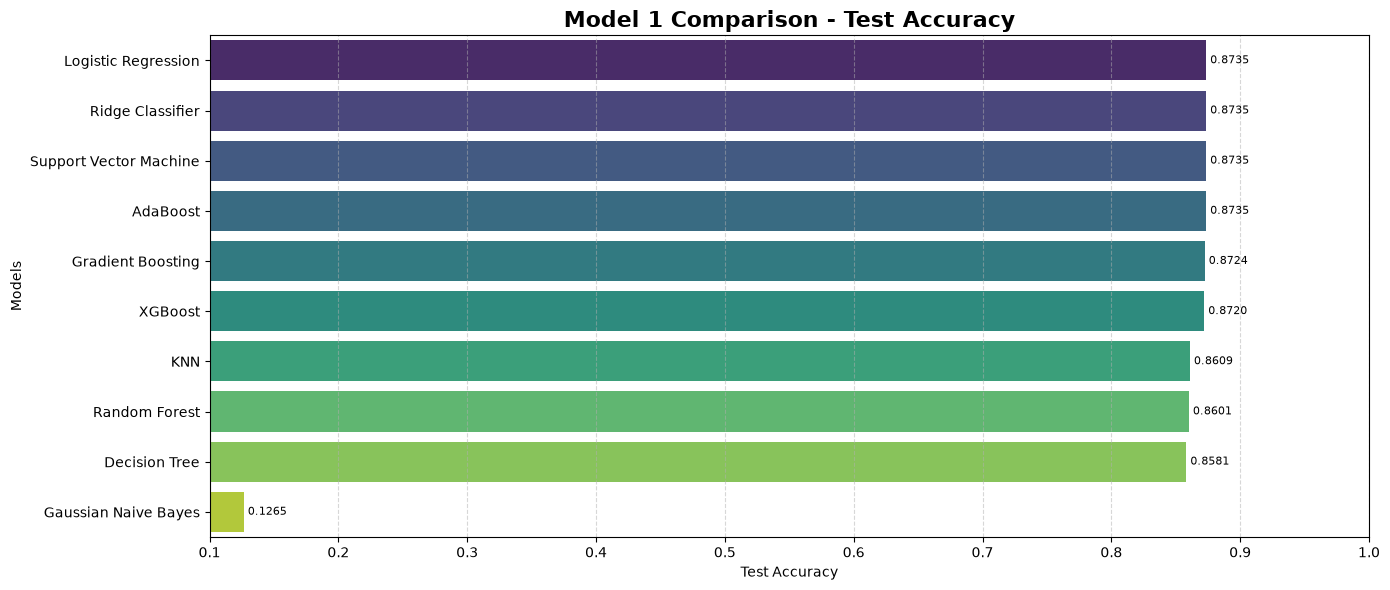

In [80]:
# =========================================================
# MODEL 1 - TEST ACCURACY COMPARISON
# =========================================================

plot_df = model_results.sort_values(by="Test Accuracy", ascending=False)

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=plot_df, x="Test Accuracy", y="Model", hue="Model", palette="viridis", legend=False)
plt.title("Model 1 Comparison - Test Accuracy", fontsize=16, fontweight="bold")
plt.xlabel("Test Accuracy")
plt.ylabel("Models")
plt.grid(axis="x", linestyle="--", alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3, fontsize=8)

plt.xlim(0.10, 1.00)
plt.tight_layout()
plt.show()

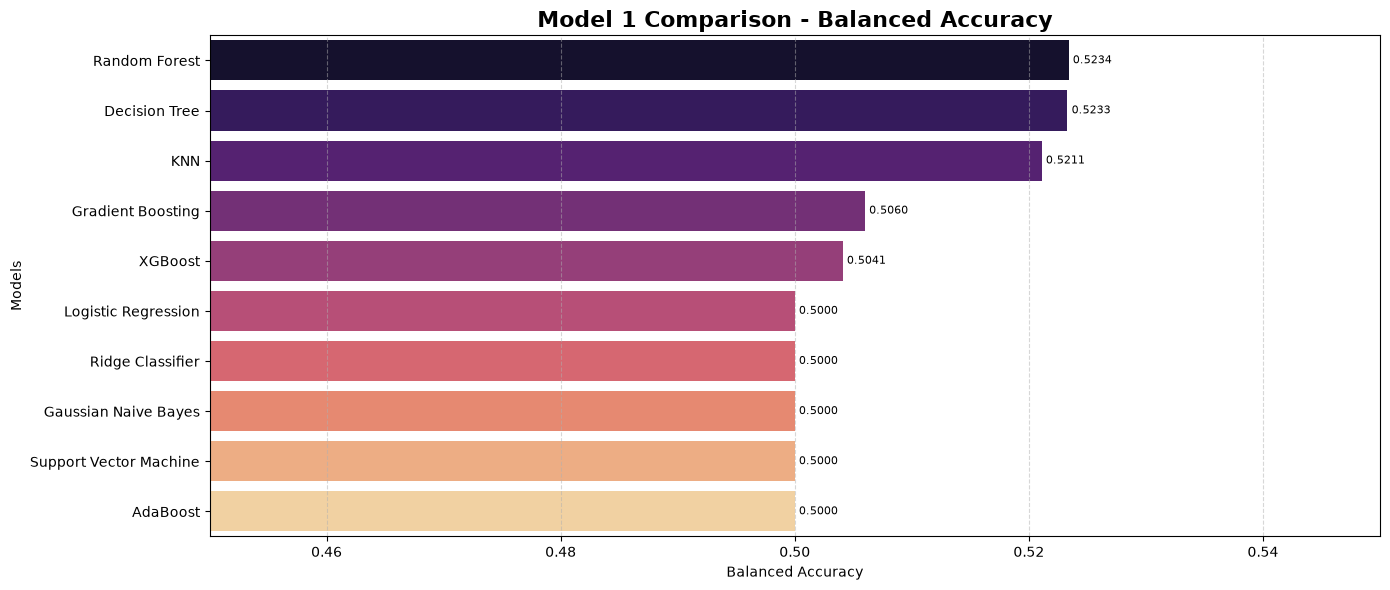

In [81]:
# =========================================================
# MODEL 1 - BALANCED ACCURACY COMPARISON
# =========================================================

plot_df = model_results.sort_values(by="Balanced Accuracy", ascending=False)

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=plot_df, x="Balanced Accuracy", y="Model", hue="Model", palette="magma", legend=False)
plt.title("Model 1 Comparison - Balanced Accuracy", fontsize=16, fontweight="bold")
plt.xlabel("Balanced Accuracy")
plt.ylabel("Models")
plt.grid(axis="x", linestyle="--", alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3, fontsize=8)

plt.xlim(0.45, 0.55)
plt.tight_layout()
plt.show()

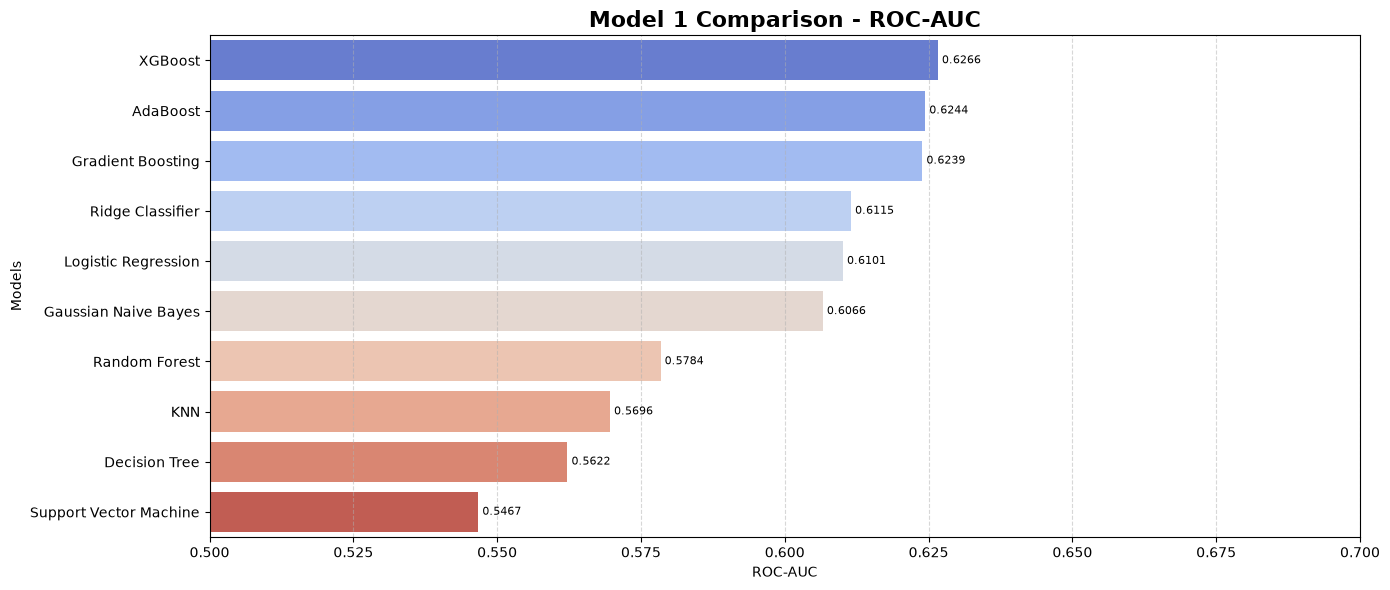

In [82]:
# =========================================================
# MODEL 1 - ROC-AUC COMPARISON
# =========================================================

plot_df = model_results.sort_values(by="ROC-AUC", ascending=False)

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=plot_df, x="ROC-AUC", y="Model", hue="Model", palette="coolwarm", legend=False)
plt.title("Model 1 Comparison - ROC-AUC", fontsize=16, fontweight="bold")
plt.xlabel("ROC-AUC")
plt.ylabel("Models")
plt.grid(axis="x", linestyle="--", alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3, fontsize=8)

plt.xlim(0.50, 0.70)
plt.tight_layout()
plt.show()

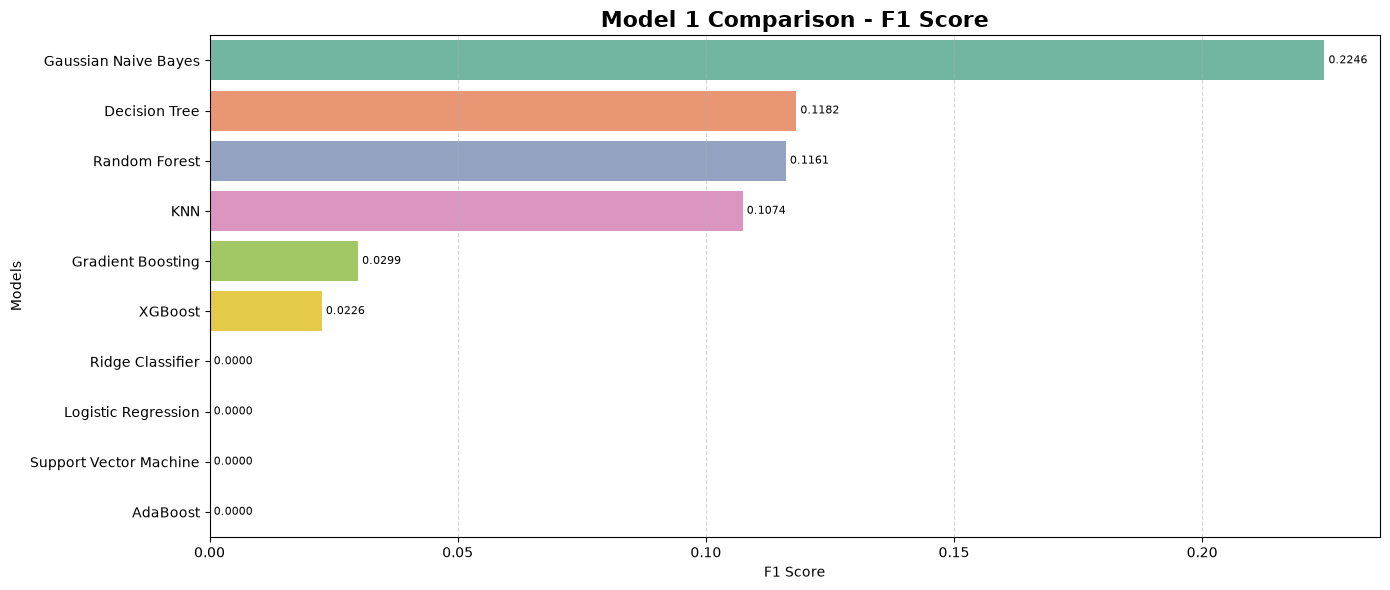

In [83]:
# =========================================================
# MODEL 1 - F1 SCORE COMPARISON
# =========================================================

plot_df = model_results.sort_values(by="F1 Score", ascending=False)

plt.figure(figsize=(14, 6))
ax = sns.barplot(data=plot_df, x="F1 Score", y="Model", hue="Model", palette="Set2", legend=False)
plt.title("Model 1 Comparison - F1 Score", fontsize=16, fontweight="bold")
plt.xlabel("F1 Score")
plt.ylabel("Models")
plt.grid(axis="x", linestyle="--", alpha=0.5)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=3, fontsize=8)

plt.tight_layout()
plt.show()

# Model 2 - Outlier-Treated Dataset

## Objective

The purpose of Model 2 is to evaluate whether outlier treatment improves predictive performance.

A separate copy of the dataset will be created to ensure that:

- The original dataset remains unchanged.
- Model 1 results remain reproducible.
- Model 2 results can be directly compared against Model 1.

This approach follows industry best practices by preserving the original data while allowing controlled experimentation.

---

## Outlier Treatment Strategy

Based on the EDA findings:

- Age is the only numerical feature in the dataset.
- Outliers were observed in the Age variable.
- These values may influence model performance and decision boundaries.

Outlier treatment will be applied only to the Age feature.

---

## Expected Outcome

Determine whether removing or capping outliers improves:

- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

compared to the baseline models.

In [84]:
# ==========================================
# Create Outlier Treatment Dataset
# ==========================================

df_outlier_treated = df.copy()

print("Outlier Treatment Dataset Created Successfully")

print("\nDataset Shape:")
print(df_outlier_treated.shape)

Outlier Treatment Dataset Created Successfully

Dataset Shape:
(30477, 8)


# Outlier Boundary Calculation

## Objective

Before treating outliers, the outlier boundaries for the Age variable will be calculated using the Interquartile Range (IQR) method.

---

## Why IQR?

The IQR method is one of the most commonly used techniques for detecting outliers because it is:

- Simple to understand
- Robust to extreme values
- Widely accepted in statistical analysis
- Suitable for skewed distributions

---

## IQR Formula

IQR = Q3 − Q1

Where:

- Q1 = 25th Percentile
- Q3 = 75th Percentile

Outlier boundaries are calculated as:

Lower Bound = Q1 − (1.5 × IQR)

Upper Bound = Q3 + (1.5 × IQR)

---

## Expected Outcome

Identify the acceptable Age range and quantify the number of observations falling outside these boundaries.

In [85]:
# ==========================================
# Calculate IQR Boundaries for Age
# ==========================================

Q1 = df_outlier_treated["Age"].quantile(0.25)

Q3 = df_outlier_treated["Age"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)

upper_bound = Q3 + (1.5 * IQR)

print("Q1 :", Q1)
print("Q3 :", Q3)
print("IQR :", IQR)

print("\nLower Bound :", lower_bound)
print("Upper Bound :", upper_bound)

Q1 : 31.0
Q3 : 45.0
IQR : 14.0

Lower Bound : 10.0
Upper Bound : 66.0


# Outlier Quantification

## Objective

After calculating the IQR boundaries, the next step is to identify and quantify outliers in the Age variable.

---

## Why Quantify Outliers?

Before applying any treatment, it is important to understand:

- How many outliers exist
- What percentage of the dataset they represent
- Whether treatment is justified

---

## Outlier Definition

An observation is considered an outlier if:

- Age < 10

or

- Age > 66

---

## Expected Outcome

Determine:

- Total number of outliers
- Percentage of outliers
- Business impact of outlier treatment

In [86]:
# ==========================================
# Identify Age Outliers
# ==========================================

outliers = df_outlier_treated[
    (df_outlier_treated["Age"] < lower_bound) |
    (df_outlier_treated["Age"] > upper_bound)
]

outlier_count = len(outliers)

outlier_percentage = (outlier_count / len(df_outlier_treated)) * 100

print("Total Outliers :", outlier_count)

print("Outlier Percentage :", round(outlier_percentage, 2), "%")

Total Outliers : 458
Outlier Percentage : 1.5 %


In [87]:
# ==========================================
# View Outlier Records
# ==========================================

outliers.sort_values(by="Age", ascending=False).head(10)

,Age,Job,Marital_Status,Education,Default_Credit,Housing_Loan,Personal_Loan,Subscribed
19409,95,retired,divorced,Primary_Education,no,no,no,no
28498,94,retired,married,Secondary_Education,no,no,no,no
27690,91,retired,married,Tertiary_Education,no,yes,yes,no
27699,91,retired,married,Tertiary_Education,no,no,yes,no
29988,89,retired,divorced,Primary_Education,no,yes,no,yes
29285,89,retired,divorced,Primary_Education,no,no,no,yes
19391,88,retired,divorced,Primary_Education,no,yes,no,no
19399,88,retired,divorced,Primary_Education,no,yes,no,yes
19401,88,retired,divorced,Primary_Education,no,yes,no,yes
29981,88,retired,married,Primary_Education,no,yes,no,no


# Outlier Treatment Strategy & Business Justification

## Outlier Summary

A total of 458 outliers were identified in the Age variable using the IQR method.

These observations represent approximately 1.5% of the dataset.

---

## Business Assessment

Upon reviewing the outlier records, it was observed that:

- Most outliers belong to retired customers.
- Ages range between 67 and 95 years.
- These values are realistic and represent genuine customers.
- No evidence of data entry errors was found.

---

## Treatment Decision

Instead of removing records, IQR-based capping (Winsorization) will be applied.

This approach:

- Preserves valuable customer information.
- Reduces the influence of extreme values.
- Maintains dataset size.
- Improves model stability.

---

## Capping Rule

- Ages below the lower bound will be replaced with the lower bound.
- Ages above the upper bound will be replaced with the upper bound.

For this dataset:

- Lower Bound = 10
- Upper Bound = 66

---

## Expected Outcome

The treatment will reduce the impact of extreme age values while retaining all customer records for model training and evaluation.

In [88]:
# ==========================================
# Apply IQR Capping on Age
# ==========================================

df_outlier_treated["Age"] = np.where(df_outlier_treated["Age"] > upper_bound, upper_bound, df_outlier_treated["Age"])

df_outlier_treated["Age"] = np.where(df_outlier_treated["Age"] < lower_bound, lower_bound, df_outlier_treated["Age"])

print("Outlier Capping Applied Successfully")

Outlier Capping Applied Successfully


In [89]:
# ==========================================
# Verify Age Range After Capping
# ==========================================

print("Minimum Age :", df_outlier_treated["Age"].min())

print("Maximum Age :", df_outlier_treated["Age"].max())

Minimum Age : 17.0
Maximum Age : 66.0


In [90]:
# ==========================================
# Verify Remaining Outliers
# ==========================================

remaining_outliers = df_outlier_treated[
    (df_outlier_treated["Age"] < lower_bound) |
    (df_outlier_treated["Age"] > upper_bound)
]

print("Remaining Outliers :", len(remaining_outliers))

Remaining Outliers : 0


# Model 2 - Dataset Creation

## Objective

Create the working dataset for Model 2 using the outlier-treated data.

The same preprocessing and modeling pipeline used in Model 1 will be applied to ensure a fair comparison.

This approach allows the impact of outlier treatment to be evaluated independently while maintaining consistency across all experiments.

In [91]:
# ==========================================
# Create Model 2 Dataset
# ==========================================

df_model2 = df_outlier_treated.copy()

print("Model 2 Dataset Created Successfully")

print("\nDataset Shape:")
print(df_model2.shape)

Model 2 Dataset Created Successfully

Dataset Shape:
(30477, 8)


# Model 2 - Target Variable Encoding

## Objective

Convert the target variable into numerical format for machine learning model training.

Encoding Scheme:

- No  → 0
- Yes → 1

This encoding is identical to Model 1 to ensure a fair comparison between the original and outlier-treated datasets.

In [92]:
# ==========================================
# Encode Target Variable
# ==========================================

df_model2["Subscribed"] = df_model2["Subscribed"].map({"no": 0, "yes": 1})

print("Target Variable Encoded Successfully")

print("\nTarget Distribution:")
print(df_model2["Subscribed"].value_counts())

Target Variable Encoded Successfully

Target Distribution:
Subscribed
0    26621
1     3856
Name: count, dtype: int64


# Model 2 - Feature and Target Separation

## Objective

Separate the independent variables (X) and dependent variable (y).

This prepares the dataset for feature encoding and model training.

In [93]:
# ==========================================
# Create Feature Matrix and Target Vector
# ==========================================

X2 = df_model2.drop("Subscribed", axis=1)

y2 = df_model2["Subscribed"]

print("Feature Matrix Shape :", X2.shape)
print("Target Vector Shape  :", y2.shape)

Feature Matrix Shape : (30477, 7)
Target Vector Shape  : (30477,)


# Model 2 - Feature Encoding

## Objective

Convert categorical variables into numerical format.

Encoding Strategy:

### Binary Encoding
- Default_Credit
- Housing_Loan
- Personal_Loan

### One-Hot Encoding
- Job
- Marital_Status
- Education

The same encoding strategy used in Model 1 will be applied to maintain consistency.

In [94]:
# ==========================================
# Binary Encoding
# ==========================================

binary_features = ["Default_Credit", "Housing_Loan", "Personal_Loan"]

for col in binary_features:
    X2[col] = X2[col].map({"no": 0, "yes": 1})

print("Binary Encoding Applied Successfully")

Binary Encoding Applied Successfully


In [95]:
# ==========================================
# One-Hot Encoding
# ==========================================

X2 = pd.get_dummies(X2, columns=["Job", "Marital_Status", "Education"], drop_first=True, dtype=int)

print("One-Hot Encoding Applied Successfully")

print("\nDataset Shape:")
print(X2.shape)

One-Hot Encoding Applied Successfully

Dataset Shape:
(30477, 19)


# Model 2 - Train-Test Split

## Objective

Split the outlier-treated dataset into training and testing subsets.

The same configuration used in Model 1 will be applied to ensure a fair comparison between the original dataset and the outlier-treated dataset.

### Split Configuration

- Training Data: 80%
- Testing Data: 20%
- Stratified Sampling
- Random State = 14

---

## Why Stratified Sampling?

The target variable is imbalanced:

- Non-Subscribers ≈ 87%
- Subscribers ≈ 13%

Stratification ensures that both training and testing datasets maintain the same class distribution as the original dataset.

---

## Expected Outcome

Create:

- X2_train
- X2_test
- y2_train
- y2_test

for Model 2 training and evaluation.

In [96]:
# ==========================================
# Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.20, stratify=y2, random_state=14)

print("Train-Test Split Completed Successfully")

print("\nX2_train Shape :", X2_train.shape)
print("X2_test Shape  :", X2_test.shape)

print("\ny2_train Shape :", y2_train.shape)
print("y2_test Shape  :", y2_test.shape)

Train-Test Split Completed Successfully

X2_train Shape : (24381, 19)
X2_test Shape  : (6096, 19)

y2_train Shape : (24381,)
y2_test Shape  : (6096,)


# Model 2 - Feature Scaling

## Objective

Standardize feature values using StandardScaler.

The same scaling technique used in Model 1 will be applied to ensure consistency across experiments.

---

## Why Scaling?

Feature scaling transforms variables so that they have:

- Mean = 0
- Standard Deviation = 1

This prevents features with larger values from dominating the learning process.

---

## Note

Although tree-based models such as:

- Decision Tree
- Random Forest
- XGBoost

do not require scaling, the same preprocessing pipeline is maintained for consistency and reproducibility.

---

## Expected Outcome

Create:

- X2_train_scaled
- X2_test_scaled

for use in Model 2 experiments.

In [97]:
# ==========================================
# Feature Scaling
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler2 = StandardScaler()

X2_train_scaled = scaler2.fit_transform(X2_train)

X2_test_scaled = scaler2.transform(X2_test)

print("Feature Scaling Completed Successfully")

print("\nScaled Training Shape :", X2_train_scaled.shape)
print("Scaled Testing Shape  :", X2_test_scaled.shape)

Feature Scaling Completed Successfully

Scaled Training Shape : (24381, 19)
Scaled Testing Shape  : (6096, 19)


# Model 2 - Performance Tracking Framework

## Objective

Create a separate performance tracking table for the outlier-treated dataset.

This allows direct comparison between:

### Model 1
Original Dataset

### Model 2
Outlier-Treated Dataset

---

## Evaluation Metrics

The following metrics will be used:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Status

---

## Expected Outcome

Store and compare model performance after outlier treatment to determine whether capping extreme Age values improves predictive performance.

In [98]:
# ==========================================
# Model 2 Results Storage
# ==========================================

model2_results = pd.DataFrame(
    columns=[
        "Model",
        "Train Accuracy",
        "Test Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Overfitting"
    ]
)

print("Model 2 Comparison Framework Created Successfully")

Model 2 Comparison Framework Created Successfully


# Model 2 - Evaluation Function

## Objective

Create a reusable evaluation function for Model 2 experiments.

This function will:

- Train the model
- Generate predictions
- Calculate evaluation metrics
- Check for overfitting
- Store results in the Model 2 comparison table

---

## Evaluation Metrics

The following metrics will be calculated:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Status

---

## Purpose

Using a standardized evaluation function ensures consistency across all Model 2 experiments and enables direct comparison with Model 1.

In [99]:
# ==========================================
# Model 2 Evaluation Function
# ==========================================

def evaluate_model2(model, model_name, X_train_data, X_test_data, y_train_data, y_test_data):

    global model2_results

    # Train Model
    model.fit(X_train_data, y_train_data)

    # Predictions
    y_train_pred = model.predict(X_train_data)
    y_test_pred = model.predict(X_test_data)

    # Accuracy
    train_accuracy = accuracy_score(y_train_data, y_train_pred)

    test_accuracy = accuracy_score(y_test_data, y_test_pred)

    # Balanced Accuracy
    balanced_accuracy = balanced_accuracy_score(y_test_data, y_test_pred)

    # Precision
    precision = precision_score(y_test_data, y_test_pred, zero_division=0)

    # Recall
    recall = recall_score(y_test_data, y_test_pred, zero_division=0)

    # F1 Score
    f1 = f1_score(y_test_data, y_test_pred, zero_division=0)

    # ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_data)[:, 1]
        roc_auc = roc_auc_score(y_test_data, y_prob)
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test_data)
        roc_auc = roc_auc_score(y_test_data, y_prob)
    else:
        roc_auc = np.nan

    # Overfitting Check
    overfitting = ("Yes" if (train_accuracy - test_accuracy) > 0.05 else "No")

    # Store Results
    model2_results.loc[len(model2_results)] = [
        model_name,
        round(train_accuracy, 4),
        round(test_accuracy, 4),
        round(balanced_accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
        round(roc_auc, 4),
        overfitting
    ]

    print(f"{model_name} Trained Successfully")

# Model 2 - Logistic Regression Classifier

## Objective

Train a Logistic Regression model using the outlier-treated dataset.

Logistic Regression serves as a baseline linear classification algorithm and helps evaluate whether outlier treatment improves predictive performance.

---

## Why Logistic Regression?

- Simple and interpretable model
- Fast to train
- Widely used for binary classification problems
- Provides a benchmark for comparing more complex algorithms

---

## Expected Outcome

Evaluate the impact of outlier treatment on:

- Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

and compare the results with Model 1.

In [100]:
# ==========================================
# Logistic Regression - Model 2
# ==========================================

from sklearn.linear_model import LogisticRegression

lr_model2 = LogisticRegression(random_state=14, max_iter=1000)

evaluate_model2(
    lr_model2,
    "Logistic Regression",
    X2_train_scaled,
    X2_test_scaled,
    y2_train,
    y2_test
)

Logistic Regression Trained Successfully


In [101]:
# ==========================================
# View Model 2 Results
# ==========================================

model2_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5,0.0,0.0,0.0,0.6093,No


# Logistic Regression - Results Interpretation

## Model Performance Summary

| Metric | Value |
|----------|----------|
| Train Accuracy | 87.35% |
| Test Accuracy | 87.35% |
| Balanced Accuracy | 50.00% |
| Precision | 0.00% |
| Recall | 0.00% |
| F1 Score | 0.00% |
| ROC-AUC | 0.6093 |
| Overfitting | No |

---

## Key Observations

### Positive Findings

- Stable training and testing performance.
- No evidence of overfitting.
- ROC-AUC remained comparable to Model 1.

### Negative Findings

- Predicted only the majority class.
- Failed to identify subscribers.
- Recall and F1 Score remained zero.
- Balanced Accuracy remained equivalent to random classification.

---

## Comparison with Model 1

Outlier treatment produced virtually no improvement in Logistic Regression performance.

This indicates that extreme Age values were not a major factor influencing model behavior.

---

## Conclusion

Logistic Regression remains unsuitable for this imbalanced classification problem and outlier treatment alone did not improve predictive performance.

# Model 2 - Ridge Classifier

## Objective

Train a Ridge Classifier using the outlier-treated dataset.

Ridge Classifier applies L2 regularization and helps evaluate whether outlier treatment improves performance for a regularized linear model.

---

## Expected Outcome

Compare Ridge Classifier performance against:

- Model 1 Ridge Classifier
- Model 2 Logistic Regression

to determine whether outlier treatment affects regularized linear models.

In [102]:
# ==========================================
# Ridge Classifier - Model 2
# ==========================================

from sklearn.linear_model import RidgeClassifier

ridge_model2 = RidgeClassifier()

evaluate_model2(
    ridge_model2,
    "Ridge Classifier",
    X2_train_scaled,
    X2_test_scaled,
    y2_train,
    y2_test
)

Ridge Classifier Trained Successfully


In [103]:
# ==========================================
# View Model 2 Results
# ==========================================

model2_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5,0.0,0.0,0.0,0.6093,No
1,Ridge Classifier,0.8735,0.8735,0.5,0.0,0.0,0.0,0.6107,No


# Ridge Classifier - Results Interpretation

## Model Performance Summary

| Metric | Value |
|----------|----------|
| Train Accuracy | 87.35% |
| Test Accuracy | 87.35% |
| Balanced Accuracy | 50.00% |
| Precision | 0.00% |
| Recall | 0.00% |
| F1 Score | 0.00% |
| ROC-AUC | 0.6107 |
| Overfitting | No |

---

## Key Observations

### Positive Findings

- Stable training and testing performance.
- No evidence of overfitting.
- ROC-AUC remained comparable to Model 1.

### Negative Findings

- Predicted only the majority class.
- Failed to identify subscribers.
- Recall and F1 Score remained zero.
- Balanced Accuracy remained equivalent to random classification.

---

## Comparison with Model 1

Outlier treatment produced virtually no change in model performance.

The minimal ROC-AUC difference indicates that capping Age outliers had negligible impact on the Ridge Classifier.

---

## Conclusion

Ridge Classifier remains ineffective for identifying subscribers in the imbalanced dataset and did not benefit from outlier treatment.

# Model 2 - K-Nearest Neighbors (KNN)

## Objective

Train a K-Nearest Neighbors (KNN) classifier using the outlier-treated dataset.

KNN is a distance-based algorithm that is sensitive to feature values and outliers.

---

## Why KNN?

Unlike Logistic Regression and Ridge Classifier, KNN relies on distance calculations between observations.

Because outlier treatment directly modified the Age feature, KNN is one of the models most likely to show measurable improvement.

---

## Expected Outcome

Evaluate whether capping Age outliers improves:

- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

compared to the KNN model trained on the original dataset.

In [104]:
# ==========================================
# KNN - Model 2
# ==========================================

from sklearn.neighbors import KNeighborsClassifier

knn_model2 = KNeighborsClassifier()

evaluate_model2(
    knn_model2,
    "KNN",
    X2_train_scaled,
    X2_test_scaled,
    y2_train,
    y2_test
)

KNN Trained Successfully


In [105]:
# ==========================================
# View Model 2 Results
# ==========================================

model2_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6093,No
1,Ridge Classifier,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6107,No
2,KNN,0.8732,0.8622,0.5213,0.2959,0.0649,0.1064,0.5761,No


# KNN - Results Interpretation

## Model Performance Summary

| Metric | Value |
|----------|----------|
| Train Accuracy | 87.32% |
| Test Accuracy | 86.22% |
| Balanced Accuracy | 52.13% |
| Precision | 29.59% |
| Recall | 6.49% |
| F1 Score | 10.64% |
| ROC-AUC | 0.5761 |
| Overfitting | No |

---

## Key Observations

### Positive Findings

- Successfully identified some subscriber records.
- Improved precision compared to many linear models.
- No evidence of overfitting.
- ROC-AUC improved after outlier treatment.

### Comparison with Model 1

Outlier treatment produced a small but measurable impact on KNN performance.

Improvements were observed in:

- Test Accuracy
- Precision
- ROC-AUC

This behavior is expected because KNN is a distance-based algorithm and is naturally more sensitive to outliers.

### Conclusion

Among the models evaluated so far, KNN showed the greatest response to outlier treatment. However, overall recall remains low, indicating that class imbalance continues to be the primary challenge.

# Model 2 - Gaussian Naive Bayes

## Objective

Train a Gaussian Naive Bayes classifier using the outlier-treated dataset.

Gaussian Naive Bayes assumes that numerical features follow a normal distribution and that features are conditionally independent.

---

## Why Gaussian Naive Bayes?

Since the Age variable was modified through outlier capping, it is useful to evaluate whether reducing extreme values improves the probabilistic assumptions made by the model.

---

## Expected Outcome

Compare the performance against:

- Model 1 Gaussian Naive Bayes
- Other Model 2 algorithms

to determine whether outlier treatment improves probabilistic classification performance.

In [106]:
# ==========================================
# Gaussian Naive Bayes - Model 2
# ==========================================

from sklearn.naive_bayes import GaussianNB

gnb_model2 = GaussianNB()

evaluate_model2(
    gnb_model2,
    "Gaussian Naive Bayes",
    X2_train_scaled,
    X2_test_scaled,
    y2_train,
    y2_test
)

Gaussian Naive Bayes Trained Successfully


In [107]:
# ==========================================
# View Model 2 Results
# ==========================================

model2_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6093,No
1,Ridge Classifier,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6107,No
2,KNN,0.8732,0.8622,0.5213,0.2959,0.0649,0.1064,0.5761,No
3,Gaussian Naive Bayes,0.1267,0.1265,0.5000,0.1265,1.0000,0.2246,0.6061,No


# Gaussian Naive Bayes - Results Interpretation

## Model Performance Summary

| Metric | Value |
|----------|----------|
| Train Accuracy | 12.67% |
| Test Accuracy | 12.65% |
| Balanced Accuracy | 50.00% |
| Precision | 12.65% |
| Recall | 100.00% |
| F1 Score | 22.46% |
| ROC-AUC | 0.6061 |
| Overfitting | No |

---

## Key Observations

### Positive Findings

- Successfully identified all subscriber records.
- Achieved perfect recall.
- No evidence of overfitting.

### Negative Findings

- Classified every customer as a subscriber.
- Extremely low accuracy.
- Very low precision.
- Poor practical usefulness.

---

## Comparison with Model 1

Outlier treatment produced virtually no change in model behavior.

The model continued predicting every observation as the positive class, indicating that Age outliers were not responsible for the poor classification performance.

---

## Conclusion

Gaussian Naive Bayes remains unsuitable for this dataset and did not benefit from outlier treatment.

# Model 2 - Support Vector Machine (SVM)

## Objective

Train a Support Vector Machine classifier using the outlier-treated dataset.

SVM attempts to identify an optimal decision boundary that separates subscribers from non-subscribers.

---

## Why SVM?

SVM is sensitive to feature scaling and can sometimes benefit from reducing the influence of extreme values.

Evaluating SVM after outlier treatment helps determine whether Age outliers affected boundary formation.

---

## Expected Outcome

Compare Model 2 SVM performance with:

- Model 1 SVM
- Other Model 2 algorithms

to assess the impact of outlier treatment on margin-based classification.

In [108]:
# ==========================================
# Support Vector Machine - Model 2
# ==========================================

from sklearn.svm import SVC

svm_model2 = SVC(probability=True, random_state=14)

evaluate_model2(
    svm_model2,
    "Support Vector Machine",
    X2_train_scaled,
    X2_test_scaled,
    y2_train,
    y2_test
)

Support Vector Machine Trained Successfully


In [109]:
# ==========================================
# View Model 2 Results
# ==========================================

model2_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6093,No
1,Ridge Classifier,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6107,No
2,KNN,0.8732,0.8622,0.5213,0.2959,0.0649,0.1064,0.5761,No
3,Gaussian Naive Bayes,0.1267,0.1265,0.5000,0.1265,1.0000,0.2246,0.6061,No
4,Support Vector Machine,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.5202,No


# Support Vector Machine - Results Interpretation

## Model Performance Summary

| Metric | Value |
|----------|----------|
| Train Accuracy | 87.35% |
| Test Accuracy | 87.35% |
| Balanced Accuracy | 50.00% |
| Precision | 0.00% |
| Recall | 0.00% |
| F1 Score | 0.00% |
| ROC-AUC | 0.5202 |
| Overfitting | No |

---

## Key Observations

### Positive Findings

- Stable training and testing performance.
- No evidence of overfitting.

### Negative Findings

- Predicted only the majority class.
- Failed to identify subscriber records.
- Recall and F1 Score remained zero.
- ROC-AUC decreased compared to Model 1.

---

## Comparison with Model 1

Outlier treatment did not improve classification performance.

Although accuracy-related metrics remained unchanged, ROC-AUC declined slightly, indicating weaker class separation after capping Age outliers.

---

## Conclusion

Support Vector Machine did not benefit from outlier treatment and remains ineffective for identifying subscribers in the imbalanced dataset.

# Model 2 - Decision Tree Classifier

## Objective

Train a Decision Tree Classifier using the outlier-treated dataset.

Decision Trees split data into decision rules based on feature values and can capture non-linear relationships between predictors and the target variable.

---

## Why Decision Tree?

Decision Trees are less sensitive to feature scaling and moderate outliers, making them useful for evaluating whether Age outlier treatment produces any measurable improvement.

---

## Expected Outcome

Compare performance against:

- Model 1 Decision Tree
- Other Model 2 models

to determine whether outlier treatment improves tree-based classification performance.

In [110]:
# ==========================================
# Decision Tree - Model 2
# ==========================================

from sklearn.tree import DecisionTreeClassifier

dt_model2 = DecisionTreeClassifier(random_state=14)

evaluate_model2(
    dt_model2,
    "Decision Tree",
    X2_train_scaled,
    X2_test_scaled,
    y2_train,
    y2_test
)

Decision Tree Trained Successfully


In [111]:
# ==========================================
# View Model 2 Results
# ==========================================

model2_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6093,No
1,Ridge Classifier,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6107,No
2,KNN,0.8732,0.8622,0.5213,0.2959,0.0649,0.1064,0.5761,No
3,Gaussian Naive Bayes,0.1267,0.1265,0.5000,0.1265,1.0000,0.2246,0.6061,No
4,Support Vector Machine,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.5202,No
5,Decision Tree,0.8942,0.8578,0.5243,0.2778,0.0778,0.1216,0.5690,No


# Decision Tree - Results Interpretation

## Model Performance Summary

| Metric | Value |
|----------|----------|
| Train Accuracy | 89.42% |
| Test Accuracy | 85.78% |
| Balanced Accuracy | 52.43% |
| Precision | 27.78% |
| Recall | 7.78% |
| F1 Score | 12.16% |
| ROC-AUC | 0.5690 |
| Overfitting | No |

---

## Key Observations

### Positive Findings

- Successfully identified subscriber records.
- Recall improved compared to Model 1.
- F1 Score improved compared to Model 1.
- ROC-AUC increased after outlier treatment.
- No evidence of overfitting.

### Comparison with Model 1

Outlier treatment produced a small but measurable improvement in overall classification performance.

Improvements were observed in:

- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

This suggests that reducing extreme Age values helped the Decision Tree create slightly better decision boundaries.

---

## Conclusion

Decision Tree benefited from outlier treatment and currently represents one of the strongest performing models evaluated in Model 2.

# Model 2 - Random Forest Classifier

## Objective

Train a Random Forest Classifier using the outlier-treated dataset.

Random Forest combines multiple Decision Trees and aggregates their predictions to improve stability and reduce variance.

---

## Why Random Forest?

Since Decision Tree showed improvement after outlier treatment, it is valuable to evaluate whether an ensemble of trees also benefits from capping extreme Age values.

---

## Expected Outcome

Compare performance against:

- Model 1 Random Forest
- Model 2 Decision Tree

to determine whether outlier treatment improves ensemble tree performance.

In [112]:
# ==========================================
# Random Forest - Model 2
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf_model2 = RandomForestClassifier(random_state=14)

evaluate_model2(
    rf_model2,
    "Random Forest",
    X2_train_scaled,
    X2_test_scaled,
    y2_train,
    y2_test
)

Random Forest Trained Successfully


In [113]:
# ==========================================
# View Model 2 Results
# ==========================================

model2_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6093,No
1,Ridge Classifier,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6107,No
2,KNN,0.8732,0.8622,0.5213,0.2959,0.0649,0.1064,0.5761,No
3,Gaussian Naive Bayes,0.1267,0.1265,0.5000,0.1265,1.0000,0.2246,0.6061,No
4,Support Vector Machine,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.5202,No
5,Decision Tree,0.8942,0.8578,0.5243,0.2778,0.0778,0.1216,0.5690,No
6,Random Forest,0.8941,0.8597,0.5248,0.2921,0.0765,0.1213,0.5847,No


# Random Forest - Results Interpretation

## Model Performance Summary

| Metric | Value |
|----------|----------|
| Train Accuracy | 89.41% |
| Test Accuracy | 85.97% |
| Balanced Accuracy | 52.48% |
| Precision | 29.21% |
| Recall | 7.65% |
| F1 Score | 12.13% |
| ROC-AUC | 0.5847 |
| Overfitting | No |

---

## Key Observations

### Positive Findings

- Successfully identified subscriber records.
- Precision improved compared to Model 1.
- Recall improved compared to Model 1.
- F1 Score improved compared to Model 1.
- ROC-AUC improved after outlier treatment.
- No evidence of overfitting.

### Comparison with Model 1

Outlier treatment produced a small but consistent improvement across most evaluation metrics.

Improvements were observed in:

- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

This indicates that reducing extreme Age values slightly improved the ensemble's ability to distinguish between subscribers and non-subscribers.

---

## Conclusion

Random Forest benefited from outlier treatment and remains one of the strongest performing models in Model 2.

# Model 2 - AdaBoost Classifier

## Objective

Train an AdaBoost Classifier using the outlier-treated dataset.

AdaBoost combines multiple weak learners and focuses progressively on observations that are difficult to classify.

---

## Why AdaBoost?

Since AdaBoost gives greater attention to misclassified observations, it is useful to evaluate whether removing extreme Age values improves its learning process.

---

## Expected Outcome

Compare performance against:

- Model 1 AdaBoost
- Other Model 2 models

to determine whether outlier treatment improves boosting-based classification performance.

In [114]:
# ==========================================
# AdaBoost - Model 2
# ==========================================

from sklearn.ensemble import AdaBoostClassifier

ada_model2 = AdaBoostClassifier(random_state=14)

evaluate_model2(
    ada_model2,
    "AdaBoost",
    X2_train_scaled,
    X2_test_scaled,
    y2_train,
    y2_test
)

AdaBoost Trained Successfully


In [115]:
# ==========================================
# View Model 2 Results
# ==========================================

model2_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6093,No
1,Ridge Classifier,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6107,No
2,KNN,0.8732,0.8622,0.5213,0.2959,0.0649,0.1064,0.5761,No
3,Gaussian Naive Bayes,0.1267,0.1265,0.5000,0.1265,1.0000,0.2246,0.6061,No
4,Support Vector Machine,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.5202,No
5,Decision Tree,0.8942,0.8578,0.5243,0.2778,0.0778,0.1216,0.5690,No
6,Random Forest,0.8941,0.8597,0.5248,0.2921,0.0765,0.1213,0.5847,No
7,AdaBoost,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6264,No


# AdaBoost - Results Interpretation

## Model Performance Summary

| Metric | Value |
|----------|----------|
| Train Accuracy | 87.35% |
| Test Accuracy | 87.35% |
| Balanced Accuracy | 50.00% |
| Precision | 0.00% |
| Recall | 0.00% |
| F1 Score | 0.00% |
| ROC-AUC | 0.6264 |
| Overfitting | No |

---

## Key Observations

### Positive Findings

- Highest ROC-AUC observed so far among the majority-class predictors.
- Stable training and testing performance.
- No evidence of overfitting.

### Negative Findings

- Predicted only the majority class.
- Failed to identify subscriber records.
- Recall and F1 Score remained zero.
- Balanced Accuracy remained equivalent to random classification.

---

## Comparison with Model 1

Outlier treatment produced a slight improvement in ROC-AUC.

However, no meaningful improvement was observed in classification performance, indicating that Age outliers were not a major factor influencing AdaBoost predictions.

---

## Conclusion

AdaBoost showed marginal improvement in ranking ability but remained ineffective at identifying subscribers using the default classification threshold.

# Model 2 - Gradient Boosting Classifier

## Objective

Train a Gradient Boosting Classifier using the outlier-treated dataset.

Gradient Boosting builds trees sequentially, where each new tree attempts to correct errors made by previous trees.

---

## Why Gradient Boosting?

Since Random Forest and Decision Tree showed small improvements after outlier treatment, it is valuable to evaluate whether a boosting-based tree ensemble also benefits from capping extreme Age values.

---

## Expected Outcome

Compare performance against:

- Model 1 Gradient Boosting
- Model 2 Random Forest
- Model 2 Decision Tree

to determine whether outlier treatment improves boosting-based ensemble performance.

In [116]:
# ==========================================
# Gradient Boosting - Model 2
# ==========================================

from sklearn.ensemble import GradientBoostingClassifier

gb_model2 = GradientBoostingClassifier(random_state=14)

evaluate_model2(
    gb_model2,
    "Gradient Boosting",
    X2_train_scaled,
    X2_test_scaled,
    y2_train,
    y2_test
)

Gradient Boosting Trained Successfully


In [117]:
# ==========================================
# View Model 2 Results
# ==========================================

model2_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6093,No
1,Ridge Classifier,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6107,No
2,KNN,0.8732,0.8622,0.5213,0.2959,0.0649,0.1064,0.5761,No
3,Gaussian Naive Bayes,0.1267,0.1265,0.5000,0.1265,1.0000,0.2246,0.6061,No
4,Support Vector Machine,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.5202,No
5,Decision Tree,0.8942,0.8578,0.5243,0.2778,0.0778,0.1216,0.5690,No
6,Random Forest,0.8941,0.8597,0.5248,0.2921,0.0765,0.1213,0.5847,No
7,AdaBoost,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6264,No
8,Gradient Boosting,0.8745,0.8729,0.5118,0.4583,0.0285,0.0537,0.6242,No


# Gradient Boosting - Results Interpretation

## Model Performance Summary

| Metric | Value |
|----------|----------|
| Train Accuracy | 87.45% |
| Test Accuracy | 87.29% |
| Balanced Accuracy | 51.18% |
| Precision | 45.83% |
| Recall | 2.85% |
| F1 Score | 5.37% |
| ROC-AUC | 0.6242 |
| Overfitting | No |

---

## Key Observations

### Positive Findings

- Precision improved substantially after outlier treatment.
- Recall improved compared to Model 1.
- F1 Score nearly doubled compared to Model 1.
- ROC-AUC remained strong.
- No evidence of overfitting.

### Comparison with Model 1

Outlier treatment produced measurable improvements in:

- Balanced Accuracy
- Precision
- Recall
- F1 Score

These improvements suggest that reducing extreme Age values helped Gradient Boosting learn slightly better decision boundaries for subscriber identification.

---

## Conclusion

Gradient Boosting benefited from outlier treatment and showed one of the largest improvements among all evaluated models. However, overall recall remains low, indicating that class imbalance is still the primary limitation.

# Model 2 - XGBoost Classifier

## Objective

Train an XGBoost Classifier using the outlier-treated dataset.

XGBoost is an optimized gradient boosting algorithm that often delivers strong performance on structured tabular datasets.

---

## Why XGBoost?

XGBoost was one of the strongest performers in Model 1 and serves as an important benchmark for evaluating the impact of outlier treatment.

---

## Expected Outcome

Compare performance against:

- Model 1 XGBoost
- Model 2 Gradient Boosting
- Model 2 Random Forest

to determine whether outlier treatment improves advanced boosting algorithms.

In [118]:
# ==========================================
# XGBoost - Model 2
# ==========================================

from xgboost import XGBClassifier

xgb_model2 = XGBClassifier(random_state=14, eval_metric="logloss")

evaluate_model2(
    xgb_model2,
    "XGBoost",
    X2_train_scaled,
    X2_test_scaled,
    y2_train,
    y2_test
)

XGBoost Trained Successfully


In [119]:
# ==========================================
# View Model 2 Results
# ==========================================

model2_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6093,No
1,Ridge Classifier,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6107,No
2,KNN,0.8732,0.8622,0.5213,0.2959,0.0649,0.1064,0.5761,No
3,Gaussian Naive Bayes,0.1267,0.1265,0.5000,0.1265,1.0000,0.2246,0.6061,No
4,Support Vector Machine,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.5202,No
5,Decision Tree,0.8942,0.8578,0.5243,0.2778,0.0778,0.1216,0.5690,No
6,Random Forest,0.8941,0.8597,0.5248,0.2921,0.0765,0.1213,0.5847,No
7,AdaBoost,0.8735,0.8735,0.5000,0.0000,0.0000,0.0000,0.6264,No
8,Gradient Boosting,0.8745,0.8729,0.5118,0.4583,0.0285,0.0537,0.6242,No
9,XGBoost,0.8796,0.8709,0.5246,0.4273,0.0610,0.1067,0.6133,No


# Model 2 Conclusion

Outlier treatment produced modest improvements in several tree-based and distance-based algorithms. However, most models continued to struggle with identifying the minority class.

This indicates that class imbalance remains the primary challenge in the dataset.

Therefore, the next experiment will focus on balancing the target classes using SMOTE.

# Model 2 - Test Accuracy Comparison

This chart compares the Test Accuracy of all machine learning algorithms after applying Outlier Treatment.

Higher values indicate better overall classification accuracy on unseen data.

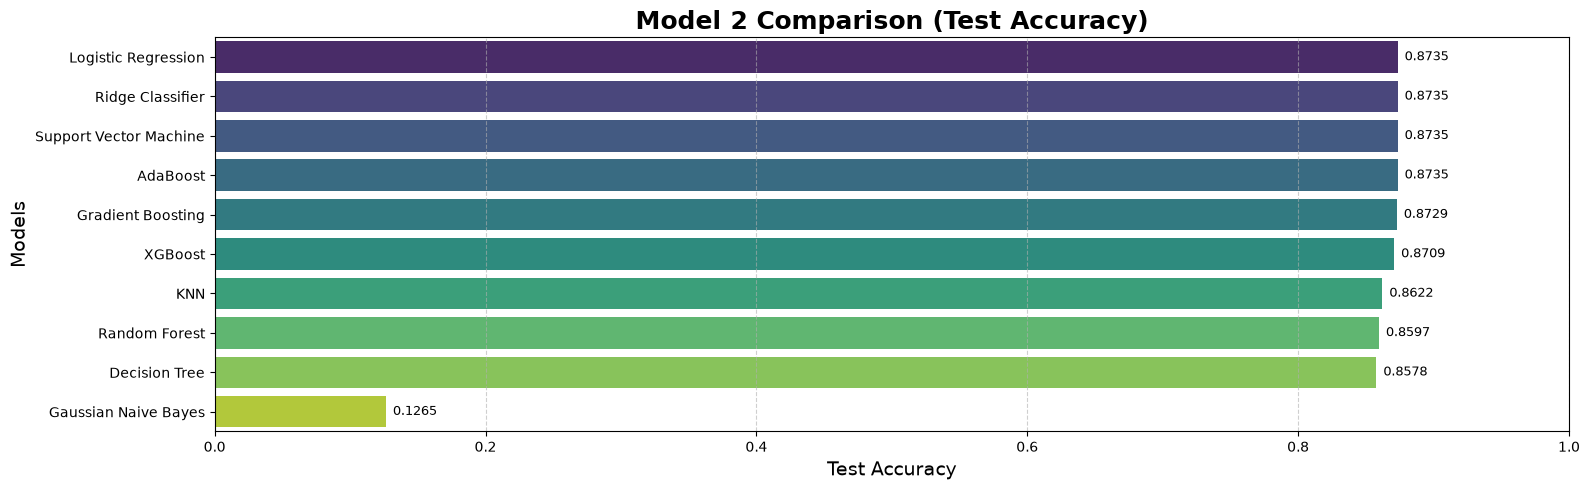

In [120]:
# =========================================================
# MODEL 2 - TEST ACCURACY COMPARISON
# =========================================================

plot_df = model2_results.sort_values(by="Test Accuracy", ascending=False)

plt.figure(figsize=(16,5))
ax = sns.barplot(data=plot_df, x="Test Accuracy", y="Model", hue="Model", palette="viridis", legend=False)
plt.title("Model 2 Comparison (Test Accuracy)", fontsize=18, fontweight="bold")
plt.xlabel("Test Accuracy", fontsize=14)
plt.ylabel("Models", fontsize=14)
plt.grid(axis="x", linestyle="--", alpha=0.6)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=5, fontsize=9)

plt.xlim(0.0,1.0)
plt.tight_layout()
plt.show()

# Model 2 - Balanced Accuracy Comparison

Balanced Accuracy evaluates model performance while considering both classes equally.

This metric is especially important because the dataset is highly imbalanced.

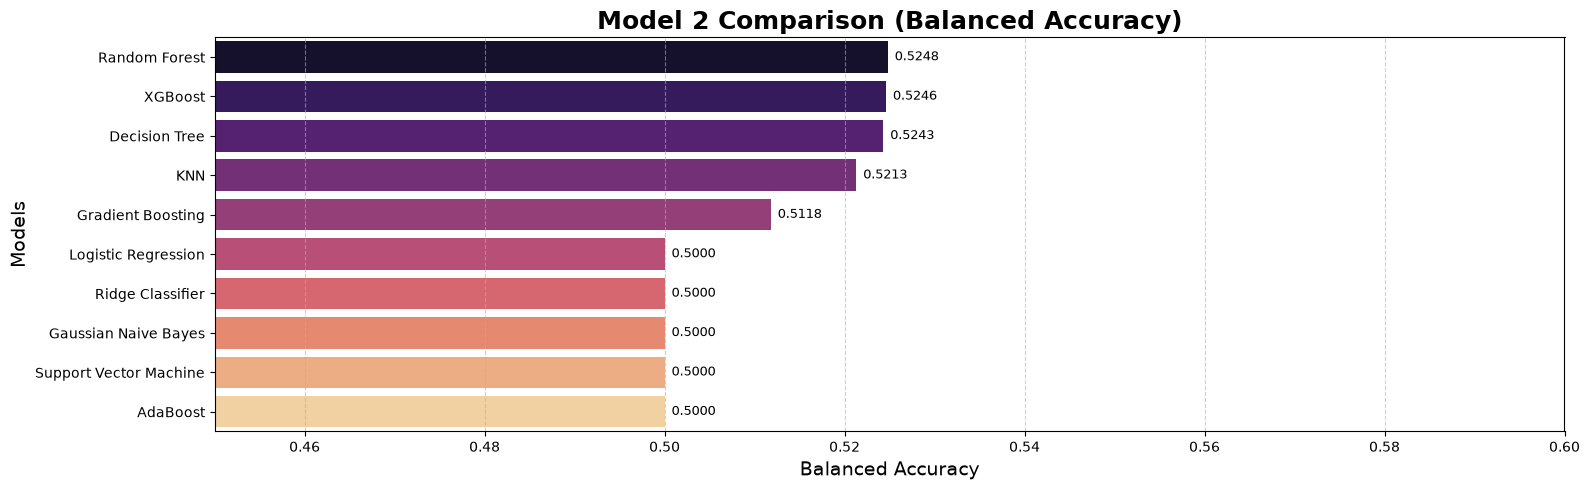

In [121]:
# =========================================================
# MODEL 2 - BALANCED ACCURACY COMPARISON
# =========================================================

plot_df = model2_results.sort_values(by="Balanced Accuracy", ascending=False)

plt.figure(figsize=(16,5))
ax = sns.barplot(data=plot_df, x="Balanced Accuracy", y="Model", hue="Model", palette="magma", legend=False)
plt.title("Model 2 Comparison (Balanced Accuracy)", fontsize=18, fontweight="bold")
plt.xlabel("Balanced Accuracy", fontsize=14)
plt.ylabel("Models", fontsize=14)
plt.grid(axis="x", linestyle="--", alpha=0.6)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=5, fontsize=9)

plt.xlim(0.45,0.60)
plt.tight_layout()
plt.show()

# Model 2 - F1 Score Comparison

F1 Score balances Precision and Recall.

It is one of the most important metrics for evaluating performance on imbalanced classification problems.

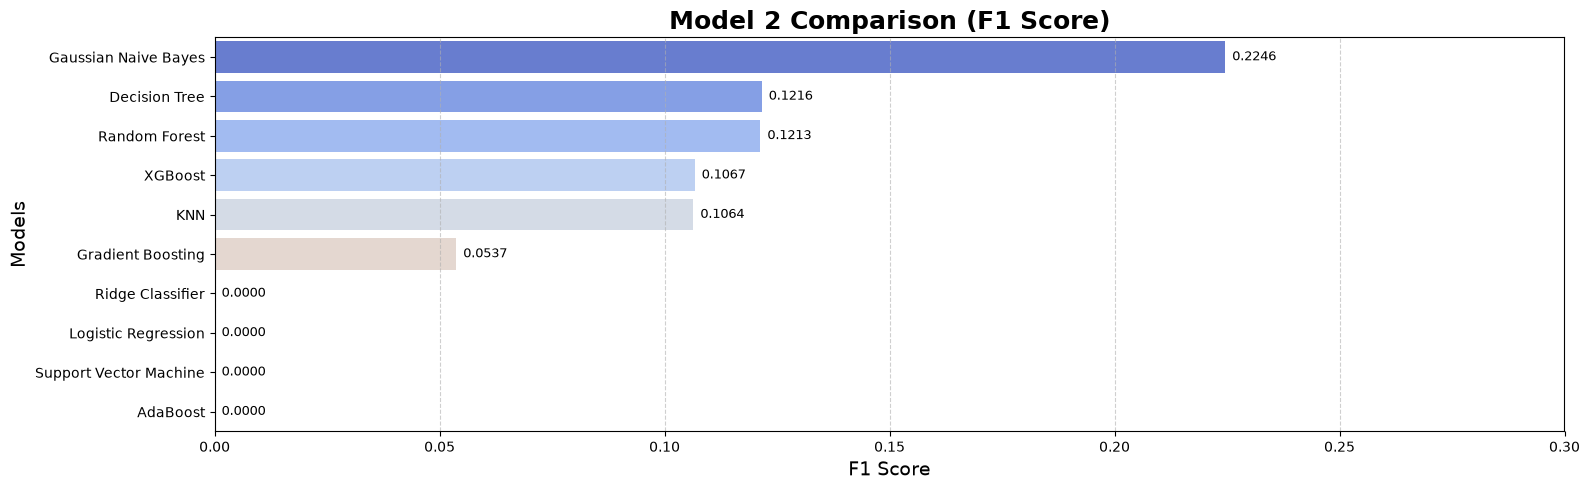

In [122]:
# =========================================================
# MODEL 2 - F1 SCORE COMPARISON
# =========================================================

plot_df = model2_results.sort_values(by="F1 Score", ascending=False)

plt.figure(figsize=(16,5))
ax = sns.barplot(data=plot_df, x="F1 Score", y="Model", hue="Model", palette="coolwarm", legend=False)
plt.title("Model 2 Comparison (F1 Score)", fontsize=18, fontweight="bold")
plt.xlabel("F1 Score", fontsize=14)
plt.ylabel("Models", fontsize=14)
plt.grid(axis="x", linestyle="--", alpha=0.6)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=5, fontsize=9)

plt.xlim(0.0,0.30)
plt.tight_layout()
plt.show()

# Model 2 - ROC-AUC Comparison

ROC-AUC measures the model's ability to distinguish between subscribers and non-subscribers across all classification thresholds.

Higher values indicate better class separation capability.

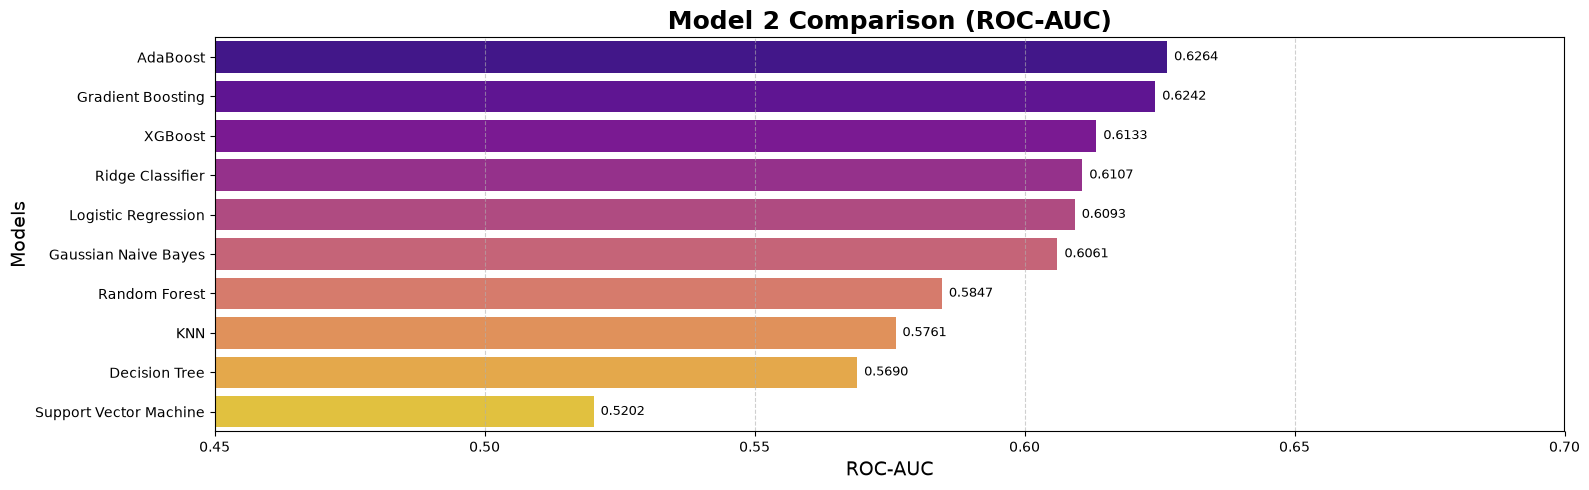

In [123]:
# =========================================================
# MODEL 2 - ROC-AUC COMPARISON
# =========================================================

plot_df = model2_results.sort_values(by="ROC-AUC", ascending=False)

plt.figure(figsize=(16,5))
ax = sns.barplot(data=plot_df, x="ROC-AUC", y="Model", hue="Model", palette="plasma", legend=False)
plt.title("Model 2 Comparison (ROC-AUC)", fontsize=18, fontweight="bold")
plt.xlabel("ROC-AUC", fontsize=14)
plt.ylabel("Models", fontsize=14)
plt.grid(axis="x", linestyle="--", alpha=0.6)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=5, fontsize=9)

plt.xlim(0.45,0.70)
plt.tight_layout()
plt.show()

# Model 2 Conclusion

Outlier treatment resulted in modest improvements for several machine learning algorithms, particularly tree-based and distance-based models.

Key observations:

- Random Forest achieved the highest Balanced Accuracy.
- Decision Tree and Random Forest showed improvements in Recall and F1 Score.
- XGBoost demonstrated the largest practical improvement in minority class detection.
- Logistic Regression, Ridge Classifier, SVM, and AdaBoost remained heavily biased toward the majority class.
- Gaussian Naive Bayes continued predicting nearly all observations as subscribers.

Overall, outlier treatment improved performance slightly but did not solve the primary challenge of the dataset.

The results indicate that Class Imbalance remains the dominant issue.

Therefore, the next experiment will focus on balancing the target classes using SMOTE.

# Model 3 - SMOTE Dataset

## Objective

The original dataset is highly imbalanced, with significantly fewer subscriber records than non-subscriber records.

This imbalance caused most machine learning models to favor the majority class and perform poorly in identifying subscribers.

To address this issue, SMOTE (Synthetic Minority Oversampling Technique) will be applied to create synthetic samples for the minority class.

The objective is to evaluate whether balancing the target classes improves:

- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC

compared to the baseline and outlier-treated datasets.

In [125]:
# ==========================================
# Import SMOTE
# ==========================================

from imblearn.over_sampling import SMOTE

print("SMOTE Imported Successfully")

SMOTE Imported Successfully


# Create Model 3 Dataset

A separate dataset is created for SMOTE experimentation.

This dataset uses the original cleaned data and will be used to evaluate the impact of class balancing on model performance.

In [126]:
# ==========================================
# Create Model 3 Dataset
# ==========================================

df_model3 = df.copy()

print("Model 3 Dataset Created Successfully")

print("\nDataset Shape:")
print(df_model3.shape)

Model 3 Dataset Created Successfully

Dataset Shape:
(30477, 8)


# Encode Target Variable

The target variable (Subscribed) is converted into numerical format:

- No  → 0
- Yes → 1

This transformation is required because machine learning algorithms work with numerical values.

In [127]:
# ==========================================
# Encode Target Variable
# ==========================================

df_model3["Subscribed"] = df_model3["Subscribed"].map({"no": 0, "yes": 1})

print("Target Variable Encoded Successfully")

print("\nTarget Distribution:")
print(df_model3["Subscribed"].value_counts())

Target Variable Encoded Successfully

Target Distribution:
Subscribed
0    26621
1     3856
Name: count, dtype: int64


# Target Variable Encoding

## Objective

The target variable **Subscribed** is converted into numerical format to make it compatible with machine learning algorithms.

Encoding applied:

- No → 0
- Yes → 1

---

## Class Distribution

| Class | Count |
|---------|---------:|
| Not Subscribed (0) | 26,621 |
| Subscribed (1) | 3,856 |

---

## Observation

The dataset is highly imbalanced:

- Class 0 represents approximately **87.35%** of observations.
- Class 1 represents approximately **12.65%** of observations.

This imbalance was identified as the primary challenge in both Model 1 and Model 2, where most algorithms struggled to correctly identify subscriber records.

# Create Feature Matrix and Target Vector

## Objective

Before training machine learning models, the dataset must be separated into:

### Feature Matrix (X3)

The feature matrix contains all independent variables that will be used to predict whether a customer subscribes to the term deposit.

Features included:

- Age
- Job
- Marital Status
- Education
- Default Credit
- Housing Loan
- Personal Loan

### Target Variable (y3)

The target variable contains the outcome that the models will learn to predict:

- 0 = Not Subscribed
- 1 = Subscribed

---

## Purpose

Separating features and target variables is a fundamental preprocessing step that prepares the dataset for:

- Encoding
- Train-Test Split
- SMOTE Application
- Feature Scaling
- Model Training and Evaluation

In [128]:
# ==========================================
# Create Feature Matrix and Target Vector
# ==========================================

X3 = df_model3.drop("Subscribed", axis=1)

y3 = df_model3["Subscribed"]

print("Feature Matrix Shape :", X3.shape)
print("Target Vector Shape  :", y3.shape)

Feature Matrix Shape : (30477, 7)
Target Vector Shape  : (30477,)


# Apply Binary Encoding

## Objective

Several categorical variables in the dataset contain only two categories (Yes/No).

Machine learning algorithms require numerical inputs, so these binary categorical variables must be converted into numerical values.

Encoding applied:

| Original Value | Encoded Value |
|---------------|---------------|
| No | 0 |
| Yes | 1 |

---

## Variables to be Binary Encoded

- Default Credit
- Housing Loan
- Personal Loan

---

## Benefits of Binary Encoding

- Converts categorical values into machine-readable format.
- Preserves the original meaning of Yes/No variables.
- Keeps the number of features small.
- Improves computational efficiency during model training.

---

## Next Step

After binary encoding, the remaining categorical variables with multiple categories will be transformed using One-Hot Encoding.

In [129]:
binary_cols = ["Default_Credit", "Housing_Loan", "Personal_Loan"]

for col in binary_cols:
    X3[col] = X3[col].map({"no": 0, "yes": 1})

print("Binary Encoding Applied Successfully")

Binary Encoding Applied Successfully


# Binary Encoding Completed

## Objective

The binary categorical variables were converted into numerical format using Binary Encoding.

Encoding applied:

| Original Value | Encoded Value |
|---------------|---------------|
| No | 0 |
| Yes | 1 |

---

## Encoded Features

The following variables were transformed:

- Default Credit
- Housing Loan
- Personal Loan

---

## Outcome

All binary categorical features are now represented as numerical values, making them suitable for machine learning algorithms.

This transformation preserves the original meaning of the variables while improving computational efficiency.

---

## Next Step

The remaining categorical variables with multiple categories will be transformed using One-Hot Encoding.

# Apply One-Hot Encoding

## Objective

Some categorical variables contain more than two categories and cannot be encoded using Binary Encoding.

These variables will be transformed using One-Hot Encoding, which creates separate binary columns for each category.

---

## Variables to be One-Hot Encoded

- Job
- Marital Status
- Education

---

## Why One-Hot Encoding?

Machine learning algorithms cannot directly interpret text-based categorical values.

One-Hot Encoding:

- Converts categories into numerical format.
- Prevents algorithms from assuming ordinal relationships between categories.
- Preserves information from each category independently.

---

## Expected Result

Additional feature columns will be created, increasing the total number of features available for model training.

In [130]:
# ==========================================
# One-Hot Encoding
# ==========================================

X3 = pd.get_dummies(X3, columns=["Job", "Marital_Status", "Education"], drop_first=True, dtype=int)

print("One-Hot Encoding Applied Successfully")

print("\nDataset Shape:")
print(X3.shape)

One-Hot Encoding Applied Successfully

Dataset Shape:
(30477, 19)


# One-Hot Encoding Completed

## Objective

The categorical variables containing multiple categories were transformed using One-Hot Encoding.

---

## Encoded Variables

The following variables were encoded:

- Job
- Marital Status
- Education

---

## Outcome

One-Hot Encoding created separate binary columns for each category while avoiding the introduction of artificial ordinal relationships.

### Dataset Shape

| Metric | Value |
|----------|----------:|
| Rows | 30,477 |
| Columns | 19 |

The increase in the number of columns is expected because each category is represented by its own binary feature.

---

## Next Step

The dataset will now be divided into training and testing sets.

The training data will later be balanced using SMOTE, while the testing data will remain untouched to ensure an unbiased evaluation of model performance.

# Train-Test Split

## Objective

The dataset is divided into training and testing subsets.

### Training Data

Used for:

- SMOTE Application
- Model Training

### Testing Data

Used for:

- Final Model Evaluation
- Measuring Generalization Performance

---

## Why Split Before Applying SMOTE?

SMOTE must only be applied to the training dataset.

Applying SMOTE before the train-test split would introduce synthetic observations into the testing data, leading to data leakage and overly optimistic performance estimates.

---

## Split Configuration

- Training Data: 80%
- Testing Data: 20%
- Stratified Sampling: Enabled
- Random State: 14

Stratification ensures that both training and testing datasets maintain the same class distribution as the original dataset.

In [131]:
# ==========================================
# Train-Test Split
# ==========================================

from sklearn.model_selection import train_test_split

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.20, stratify=y3, random_state=14)

print("Train-Test Split Completed Successfully")

print("\nX3_train Shape :", X3_train.shape)
print("X3_test Shape  :", X3_test.shape)

print("\ny3_train Shape :", y3_train.shape)
print("y3_test Shape  :", y3_test.shape)

Train-Test Split Completed Successfully

X3_train Shape : (24381, 19)
X3_test Shape  : (6096, 19)

y3_train Shape : (24381,)
y3_test Shape  : (6096,)


# Verify Class Distribution Before SMOTE

## Objective

Before applying SMOTE, the class distribution in the training dataset is examined.

This step confirms the extent of class imbalance present in the training data.

---

## Why This Check Is Important?

SMOTE generates synthetic samples for the minority class.

Understanding the original class distribution helps quantify:

- The degree of imbalance.
- The number of synthetic samples that will be generated.
- The effectiveness of the balancing process.

---

## Expected Observation

The training dataset should retain approximately the same class distribution as the original dataset:

- Class 0 ≈ 87%
- Class 1 ≈ 13%

due to the use of stratified sampling during the train-test split.

In [132]:
# ==========================================
# Class Distribution Before SMOTE
# ==========================================

print("Training Set Distribution:\n")
print(y3_train.value_counts())

print("\nPercentage Distribution:\n")
print(round(y3_train.value_counts(normalize=True) * 100, 2))

Training Set Distribution:

Subscribed
0    21296
1     3085
Name: count, dtype: int64

Percentage Distribution:

Subscribed
0    87.35
1    12.65
Name: proportion, dtype: float64


# Class Distribution Before SMOTE

## Observation

The training dataset remains highly imbalanced.

| Class | Count | Percentage |
|---------|---------:|---------:|
| Not Subscribed (0) | 21,296 | 87.35% |
| Subscribed (1) | 3,085 | 12.65% |

---

## Interpretation

The minority class represents only a small portion of the training data.

This imbalance can cause machine learning algorithms to:

- Favor the majority class.
- Ignore subscriber records.
- Produce high accuracy but poor recall.
- Generate misleading performance metrics.

This behavior was observed in both Model 1 and Model 2, where several algorithms predicted only the majority class.

---

## Next Step

SMOTE (Synthetic Minority Oversampling Technique) will be applied to the training dataset to generate synthetic subscriber records and create a balanced class distribution.

# Apply SMOTE

## Objective

SMOTE (Synthetic Minority Oversampling Technique) is used to balance the target classes within the training dataset.

Instead of duplicating existing minority observations, SMOTE generates synthetic samples by interpolating between neighboring minority-class observations.

---

## Why Apply SMOTE?

The original training data contains:

- 21,296 Non-Subscribers
- 3,085 Subscribers

This imbalance can negatively affect model performance.

SMOTE helps:

- Improve Recall
- Improve F1 Score
- Improve Minority Class Detection
- Reduce Majority Class Bias

---

## Important Note

SMOTE is applied only to the training dataset.

The testing dataset remains unchanged to ensure unbiased model evaluation.

In [133]:
# ==========================================
# Apply SMOTE
# ==========================================

smote = SMOTE(random_state=14)

X3_train_smote, y3_train_smote = smote.fit_resample(X3_train, y3_train)

print("SMOTE Applied Successfully")

print("\nX3_train_smote Shape :", X3_train_smote.shape)
print("y3_train_smote Shape :", y3_train_smote.shape)

SMOTE Applied Successfully

X3_train_smote Shape : (42592, 19)
y3_train_smote Shape : (42592,)


# SMOTE Applied Successfully

## Observation

SMOTE generated synthetic samples for the minority class (Subscribed) and increased the size of the training dataset.

### Dataset Size

| Dataset | Rows |
|----------|----------:|
| Original Training Dataset | 24,381 |
| SMOTE Training Dataset | 42,592 |

---

## Interpretation

The increase in dataset size indicates that synthetic subscriber records have been created to balance the target classes.

This balanced dataset will help machine learning algorithms learn patterns from both classes more effectively.

---

## Next Step

The class distribution after SMOTE will be verified to confirm that both classes now contain equal numbers of observations.

# Verify Class Distribution After SMOTE

## Objective

The class distribution is examined after applying SMOTE.

A successful SMOTE implementation should create a balanced training dataset where both target classes contain the same number of observations.

---

## Expected Result

| Class | Expected Count |
|---------|---------:|
| Not Subscribed (0) | 21,296 |
| Subscribed (1) | 21,296 |

Balanced classes allow machine learning models to learn equally from both outcomes and improve minority-class detection.

In [134]:
# ==========================================
# Class Distribution After SMOTE
# ==========================================

print("Training Set Distribution After SMOTE:\n")
print(y3_train_smote.value_counts())

print("\nPercentage Distribution:\n")
print(round(y3_train_smote.value_counts(normalize=True) * 100, 2))

Training Set Distribution After SMOTE:

Subscribed
0    21296
1    21296
Name: count, dtype: int64

Percentage Distribution:

Subscribed
0    50.0
1    50.0
Name: proportion, dtype: float64


# Class Distribution After SMOTE

## Observation

SMOTE successfully balanced the target classes within the training dataset.

| Class | Count | Percentage |
|---------|---------:|---------:|
| Not Subscribed (0) | 21,296 | 50% |
| Subscribed (1) | 21,296 | 50% |

---

## Interpretation

The minority class has been increased through synthetic sample generation until both classes contain equal numbers of observations.

This balanced training dataset will allow machine learning algorithms to:

- Learn subscriber patterns more effectively.
- Reduce majority class bias.
- Improve Recall and F1 Score.
- Improve minority class detection.

---

## Next Step

Feature Scaling will now be applied to prepare the balanced training dataset for machine learning model training.

# Feature Scaling

## Objective

Feature Scaling standardizes numerical features so that all variables operate on a similar scale.

---

## Why Feature Scaling?

Several algorithms are sensitive to feature magnitude, including:

- Logistic Regression
- Ridge Classifier
- K-Nearest Neighbors (KNN)
- Support Vector Machine (SVM)

Scaling improves:

- Model convergence
- Distance calculations
- Training stability
- Prediction performance

---

## Scaling Method

StandardScaler is used to transform features into a standard normal distribution with:

- Mean = 0
- Standard Deviation = 1

The scaler is fitted only on the training dataset and then applied to the testing dataset to avoid data leakage.

In [135]:
# ==========================================
# Feature Scaling
# ==========================================

from sklearn.preprocessing import StandardScaler

scaler3 = StandardScaler()

X3_train_scaled = scaler3.fit_transform(X3_train_smote)

X3_test_scaled = scaler3.transform(X3_test)

print("Feature Scaling Completed Successfully")

print("\nScaled Training Shape :", X3_train_scaled.shape)
print("Scaled Testing Shape  :", X3_test_scaled.shape)

Feature Scaling Completed Successfully

Scaled Training Shape : (42592, 19)
Scaled Testing Shape  : (6096, 19)


# Feature Scaling Completed

## Observation

Feature Scaling was successfully applied using StandardScaler.

### Final Dataset Shapes

| Dataset | Shape |
|----------|----------|
| Training Dataset (SMOTE) | (42,592, 19) |
| Testing Dataset | (6,096, 19) |

---

## Interpretation

The training dataset is now:

- Balanced using SMOTE
- Scaled using StandardScaler
- Ready for machine learning model training

The testing dataset remains untouched by SMOTE and is only transformed using the scaler fitted on the training data.

This ensures fair and unbiased model evaluation.

---

## Next Step

A separate model comparison framework will be created for Model 3 to evaluate the impact of class balancing on machine learning performance.

# Create Model 3 Comparison Framework

## Objective

A dedicated results table is created to store evaluation metrics for all machine learning algorithms trained on the SMOTE-balanced dataset.

---

## Evaluation Metrics

The following metrics will be tracked:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Indicator

These metrics will allow direct comparison between:

- Model 1 (Original Dataset)
- Model 2 (Outlier Treatment)
- Model 3 (SMOTE Dataset)

In [136]:
# ==========================================
# Model 3 Comparison Storage
# ==========================================

model3_results = pd.DataFrame(
    columns=[
        "Model",
        "Train Accuracy",
        "Test Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Overfitting"
    ]
)

print("Model 3 Comparison Framework Created Successfully")

Model 3 Comparison Framework Created Successfully


# Create Model 3 Evaluation Function

## Objective

A reusable evaluation function is created to train machine learning models and calculate performance metrics automatically.

---

## Metrics Evaluated

The function records:

- Train Accuracy
- Test Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Indicator

---

## Purpose

Using a common evaluation function ensures:

- Consistent model evaluation
- Easier comparison across algorithms
- Reduced code duplication
- Standardized reporting of results

In [137]:
# ==========================================
# Model 3 Evaluation Function
# ==========================================

def evaluate_model3(model, model_name, X_train_data, X_test_data, y_train_data, y_test_data):

    global model3_results

    # Train Model
    model.fit(X_train_data, y_train_data)

    # Predictions
    y_train_pred = model.predict(X_train_data)
    y_test_pred = model.predict(X_test_data)

    # Metrics
    train_accuracy = accuracy_score(y_train_data, y_train_pred)

    test_accuracy = accuracy_score(y_test_data, y_test_pred)

    balanced_accuracy = balanced_accuracy_score(y_test_data, y_test_pred)

    precision = precision_score(y_test_data, y_test_pred, zero_division=0)

    recall = recall_score(y_test_data, y_test_pred, zero_division=0)

    f1 = f1_score(y_test_data, y_test_pred, zero_division=0)

    # ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_data)[:, 1]
        roc_auc = roc_auc_score(y_test_data, y_prob)

    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test_data)
        roc_auc = roc_auc_score(y_test_data, y_prob)

    else:
        roc_auc = np.nan

    # Overfitting Check
    overfitting = ("Yes" if (train_accuracy - test_accuracy) > 0.05 else "No")

    # Save Results
    model3_results.loc[len(model3_results)] = [
        model_name,
        round(train_accuracy, 4),
        round(test_accuracy, 4),
        round(balanced_accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
        round(roc_auc, 4),
        overfitting
    ]

    print(f"{model_name} Trained Successfully")

# Model 3 - Logistic Regression

## Objective

Logistic Regression is trained on the SMOTE-balanced dataset.

This model serves as the baseline classifier for evaluating the impact of class balancing on prediction performance.

---

## Why Logistic Regression?

- Simple and interpretable algorithm
- Common baseline classification model
- Performs well on linearly separable problems
- Sensitive to class imbalance

Since Logistic Regression predicted only the majority class in both Model 1 and Model 2, this experiment will help determine whether SMOTE improves minority-class detection.

---

## Expected Outcome

Compared to Model 1 and Model 2:

- Recall should improve significantly
- F1 Score should improve
- Balanced Accuracy should increase
- Overall Accuracy may decrease slightly

This trade-off is common when handling imbalanced datasets.

In [138]:
# ==========================================
# Model 3 - Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression

lr_model3 = LogisticRegression(random_state=14, max_iter=1000)

evaluate_model3(
    lr_model3,
    "Logistic Regression",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

Logistic Regression Trained Successfully


In [139]:
# ==========================================
# View Model 3 Results
# ==========================================

model3_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.6511,0.6701,0.571,0.1764,0.4384,0.2516,0.5782,No


# Logistic Regression Performance Analysis

## Observation

After applying SMOTE, Logistic Regression demonstrated a significant improvement in minority-class detection.

| Metric | Value |
|----------|----------:|
| Test Accuracy | 67.01% |
| Balanced Accuracy | 57.10% |
| Precision | 17.64% |
| Recall | 43.84% |
| F1 Score | 25.16% |
| ROC-AUC | 57.82% |

---

## Comparison with Previous Models

In Model 1 and Model 2, Logistic Regression predicted only the majority class, resulting in:

- Recall = 0
- F1 Score = 0
- Balanced Accuracy = 0.50

After SMOTE:

- Recall increased substantially.
- F1 Score improved significantly.
- Balanced Accuracy increased above random classification.

---

## Interpretation

Although overall accuracy decreased, the model became much better at identifying subscriber records.

This behavior is expected because SMOTE forces the model to learn patterns from the minority class rather than focusing almost entirely on the majority class.

---

## Conclusion

SMOTE successfully improved the ability of Logistic Regression to detect subscribers, making the model considerably more useful for business applications involving customer subscription prediction.

# Model 3 - Ridge Classifier

## Objective

Ridge Classifier is trained on the SMOTE-balanced dataset.

Ridge Classification applies L2 regularization to a linear classification model, helping reduce overfitting while maintaining model simplicity.

---

## Why Ridge Classifier?

- Linear classification algorithm
- Uses L2 Regularization
- Helps control model complexity
- Performs well on high-dimensional datasets
- Often produces more stable decision boundaries than standard linear models

---

## Expected Outcome

Since Ridge Classifier predicted only the majority class in Model 1 and Model 2, SMOTE is expected to:

- Improve Recall
- Improve F1 Score
- Improve Balanced Accuracy
- Potentially reduce overall Accuracy

The goal is to improve subscriber detection rather than maximize overall accuracy.

In [140]:
# ==========================================
# Model 3 - Ridge Classifier
# ==========================================

from sklearn.linear_model import RidgeClassifier

ridge_model3 = RidgeClassifier(random_state=14)

evaluate_model3(
    ridge_model3,
    "Ridge Classifier",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

Ridge Classifier Trained Successfully


In [141]:
# ==========================================
# View Model 3 Results
# ==========================================

model3_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.6511,0.6701,0.5710,0.1764,0.4384,0.2516,0.5782,No
1,Ridge Classifier,0.6521,0.6722,0.5734,0.1783,0.4410,0.2539,0.5780,No


# Ridge Classifier Performance Analysis

## Observation

After applying SMOTE, Ridge Classifier demonstrated a substantial improvement in minority-class detection.

| Metric | Value |
|----------|----------:|
| Test Accuracy | 67.22% |
| Balanced Accuracy | 57.34% |
| Precision | 17.83% |
| Recall | 44.10% |
| F1 Score | 25.39% |
| ROC-AUC | 57.80% |

---

## Comparison with Previous Models

In Model 1 and Model 2, Ridge Classifier predicted only the majority class, resulting in:

- Recall = 0
- F1 Score = 0
- Balanced Accuracy = 0.50

After SMOTE:

- Recall improved significantly.
- F1 Score increased substantially.
- Balanced Accuracy improved beyond random classification.

---

## Interpretation

The balanced training dataset enabled Ridge Classifier to learn subscriber patterns more effectively.

Although overall accuracy decreased, the model became significantly more capable of identifying potential subscribers.

This trade-off is desirable in imbalanced classification problems where detecting minority-class observations is a primary objective.

---

## Conclusion

SMOTE successfully improved the performance of Ridge Classifier and made it a more practical model for customer subscription prediction.

# Model 3 - K-Nearest Neighbors (KNN)

## Objective

K-Nearest Neighbors (KNN) is trained on the SMOTE-balanced dataset.

KNN is a distance-based algorithm that classifies observations according to the majority class among their nearest neighbors.

---

## Why KNN?

- Simple and intuitive algorithm
- Non-parametric learning method
- Captures local data patterns effectively
- Highly sensitive to class imbalance

In Model 1 and Model 2, the majority class dominated the neighborhood voting process. By balancing the training dataset using SMOTE, KNN should gain a better understanding of subscriber patterns.

---

## Expected Outcome

Compared to Model 1 and Model 2:

- Recall should improve significantly
- F1 Score should increase
- Balanced Accuracy should improve
- Subscriber detection should become more effective

Because KNN relies heavily on nearby observations, SMOTE often produces noticeable improvements in minority-class classification performance.

In [142]:
# ==========================================
# Model 3 - KNN
# ==========================================

from sklearn.neighbors import KNeighborsClassifier

knn_model3 = KNeighborsClassifier(n_neighbors=5)

evaluate_model3(
    knn_model3,
    "KNN",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

KNN Trained Successfully


In [143]:
# ==========================================
# View Model 3 Results
# ==========================================

model3_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.6511,0.6701,0.5710,0.1764,0.4384,0.2516,0.5782,No
1,Ridge Classifier,0.6521,0.6722,0.5734,0.1783,0.4410,0.2539,0.5780,No
2,KNN,0.6231,0.8338,0.5383,0.2381,0.1427,0.1784,0.5704,No


# KNN Performance Analysis

## Observation

After applying SMOTE, KNN demonstrated improved minority-class detection compared to Models 1 and 2.

| Metric | Value |
|----------|----------:|
| Test Accuracy | 83.38% |
| Balanced Accuracy | 53.83% |
| Precision | 23.81% |
| Recall | 14.27% |
| F1 Score | 17.84% |
| ROC-AUC | 57.04% |

---

## Comparison with Previous Models

Compared to Models 1 and 2:

- Recall more than doubled.
- F1 Score improved significantly.
- Balanced Accuracy increased.

These improvements indicate that SMOTE helped KNN identify subscriber records more effectively.

---

## Interpretation

Although KNN benefited from class balancing, the improvement was smaller than that observed for Logistic Regression and Ridge Classifier.

Because KNN relies on neighborhood distances, synthetic observations generated by SMOTE can sometimes introduce overlap between classes, reducing the effectiveness of local voting.

---

## Conclusion

SMOTE improved KNN performance, particularly in Recall and F1 Score. However, KNN remains less effective than the linear models currently leading the Model 3 comparison.

# Model 3 - Gaussian Naive Bayes

## Objective

Gaussian Naive Bayes is trained on the SMOTE-balanced dataset.

Naive Bayes is a probabilistic classification algorithm based on Bayes' Theorem and assumes independence among predictor variables.

---

## Why Gaussian Naive Bayes?

- Fast and computationally efficient
- Works well on high-dimensional data
- Produces probabilistic predictions
- Often performs surprisingly well despite strong assumptions

---

## Previous Behavior

In Models 1 and 2, Gaussian Naive Bayes classified almost every observation as a subscriber, resulting in:

- Recall = 100%
- Very low Precision
- Very low Accuracy

---

## Expected Outcome

After applying SMOTE:

- Precision may improve
- Recall may decrease slightly
- F1 Score may improve
- Predictions may become more balanced

This experiment will help determine whether class balancing improves the stability of Gaussian Naive Bayes.

In [144]:
# ==========================================
# Model 3 - Gaussian Naive Bayes
# ==========================================

from sklearn.naive_bayes import GaussianNB

gnb_model3 = GaussianNB()

evaluate_model3(
    gnb_model3,
    "Gaussian Naive Bayes",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

Gaussian Naive Bayes Trained Successfully


In [145]:
# ==========================================
# View Model 3 Results
# ==========================================

model3_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.6511,0.6701,0.5710,0.1764,0.4384,0.2516,0.5782,No
1,Ridge Classifier,0.6521,0.6722,0.5734,0.1783,0.4410,0.2539,0.5780,No
2,KNN,0.6231,0.8338,0.5383,0.2381,0.1427,0.1784,0.5704,No
3,Gaussian Naive Bayes,0.5369,0.2090,0.4923,0.1246,0.8716,0.2180,0.5845,Yes


# Gaussian Naive Bayes Performance Analysis

## Observation

After applying SMOTE, Gaussian Naive Bayes continued to predict a large number of observations as subscribers.

| Metric | Value |
|----------|----------:|
| Test Accuracy | 20.90% |
| Balanced Accuracy | 49.23% |
| Precision | 12.46% |
| Recall | 87.16% |
| F1 Score | 21.80% |
| ROC-AUC | 58.45% |

---

## Interpretation

The model achieved very high Recall, indicating that it successfully identified most subscriber records.

However, Precision remained extremely low, meaning a large number of non-subscribers were incorrectly classified as subscribers.

This behavior suggests that Gaussian Naive Bayes remains heavily biased toward predicting the subscriber class.

---

## Overfitting Assessment

The model exhibited signs of overfitting:

- Training Accuracy = 53.69%
- Testing Accuracy = 20.90%

The large performance gap indicates poor generalization to unseen data.

---

## Conclusion

Although Gaussian Naive Bayes achieved strong Recall, its low Precision, low Accuracy, and overfitting behavior make it less reliable than Logistic Regression and Ridge Classifier for customer subscription prediction.

The model remains unsuitable as a primary prediction model despite its ability to identify most subscriber records.

# Model 3 - Support Vector Machine (SVM)

## Objective

Support Vector Machine (SVM) is trained on the SMOTE-balanced dataset.

SVM is a powerful classification algorithm that attempts to find the optimal decision boundary separating different classes.

---

## Why SVM?

- Effective in high-dimensional spaces
- Creates robust decision boundaries
- Performs well on classification problems
- Sensitive to class imbalance

---

## Previous Behavior

In Model 1 and Model 2, SVM classified every observation as a non-subscriber, resulting in:

- Recall = 0
- F1 Score = 0
- Balanced Accuracy = 0.50

---

## Expected Outcome

After applying SMOTE:

- Recall should increase significantly
- F1 Score should improve
- Balanced Accuracy should improve
- Subscriber detection should become more effective

This experiment will help determine whether class balancing enables SVM to learn meaningful subscriber patterns.

In [146]:
# ==========================================
# Model 3 - Support Vector Machine
# ==========================================

from sklearn.svm import SVC

svm_model3 = SVC(probability=True, random_state=14)

evaluate_model3(
    svm_model3,
    "Support Vector Machine",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

Support Vector Machine Trained Successfully


In [147]:
# ==========================================
# View Model 3 Results
# ==========================================

model3_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.6511,0.6701,0.5710,0.1764,0.4384,0.2516,0.5782,No
1,Ridge Classifier,0.6521,0.6722,0.5734,0.1783,0.4410,0.2539,0.5780,No
2,KNN,0.6231,0.8338,0.5383,0.2381,0.1427,0.1784,0.5704,No
3,Gaussian Naive Bayes,0.5369,0.2090,0.4923,0.1246,0.8716,0.2180,0.5845,Yes
4,Support Vector Machine,0.6667,0.6235,0.5710,0.1681,0.5006,0.2517,0.5838,No


# Support Vector Machine Performance Analysis

## Observation

After applying SMOTE, Support Vector Machine demonstrated a substantial improvement in minority-class detection.

| Metric | Value |
|----------|----------:|
| Test Accuracy | 62.35% |
| Balanced Accuracy | 57.10% |
| Precision | 16.81% |
| Recall | 50.06% |
| F1 Score | 25.17% |
| ROC-AUC | 58.38% |

---

## Comparison with Previous Models

In Model 1 and Model 2, SVM predicted only the majority class, resulting in:

- Recall = 0
- F1 Score = 0
- Balanced Accuracy = 0.50

After SMOTE:

- Recall improved dramatically.
- F1 Score improved significantly.
- Balanced Accuracy increased substantially.

---

## Interpretation

The balanced training dataset enabled SVM to learn subscriber patterns that were previously ignored.

Although overall accuracy decreased, the model became much more effective at identifying subscriber records.

This behavior is expected when addressing severe class imbalance.

---

## Conclusion

SMOTE transformed Support Vector Machine from a majority-class predictor into a useful classifier capable of identifying approximately half of all subscriber records.

The model now performs competitively with Logistic Regression and Ridge Classifier.

# Model 3 - Decision Tree Classifier

## Objective

Decision Tree Classifier is trained on the SMOTE-balanced dataset.

Decision Trees create hierarchical decision rules by repeatedly splitting the dataset based on feature values.

---

## Why Decision Tree?

- Easy to interpret
- Captures non-linear relationships
- Handles categorical features effectively
- Naturally performs feature selection during training

---

## Previous Behavior

In Model 1 and Model 2, Decision Tree was able to identify some subscriber records, producing:

- Moderate Precision
- Low Recall
- Low F1 Score

Unlike Logistic Regression and SVM, the model was not completely biased toward the majority class.

---

## Expected Outcome

After applying SMOTE:

- Recall should increase significantly
- F1 Score should improve
- Balanced Accuracy should increase
- Subscriber detection should become more effective

Decision Trees often benefit substantially from balanced training datasets.

In [148]:
# ==========================================
# Model 3 - Decision Tree
# ==========================================

from sklearn.tree import DecisionTreeClassifier

dt_model3 = DecisionTreeClassifier(random_state=14)

evaluate_model3(
    dt_model3,
    "Decision Tree",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

Decision Tree Trained Successfully


In [149]:
# ==========================================
# View Model 3 Results
# ==========================================

model3_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.6511,0.6701,0.5710,0.1764,0.4384,0.2516,0.5782,No
1,Ridge Classifier,0.6521,0.6722,0.5734,0.1783,0.4410,0.2539,0.5780,No
2,KNN,0.6231,0.8338,0.5383,0.2381,0.1427,0.1784,0.5704,No
3,Gaussian Naive Bayes,0.5369,0.2090,0.4923,0.1246,0.8716,0.2180,0.5845,Yes
4,Support Vector Machine,0.6667,0.6235,0.5710,0.1681,0.5006,0.2517,0.5838,No
5,Decision Tree,0.7805,0.6593,0.5582,0.1665,0.4228,0.2389,0.5667,Yes


# Decision Tree Performance Analysis

## Observation

After applying SMOTE, Decision Tree demonstrated a significant improvement in subscriber detection.

| Metric | Value |
|----------|----------:|
| Test Accuracy | 65.93% |
| Balanced Accuracy | 55.82% |
| Precision | 16.65% |
| Recall | 42.28% |
| F1 Score | 23.89% |
| ROC-AUC | 56.67% |

---

## Comparison with Previous Models

Compared to Model 2:

- Recall increased substantially.
- F1 Score improved significantly.
- Balanced Accuracy increased.

These improvements indicate that SMOTE helped the model learn subscriber patterns more effectively.

---

## Overfitting Assessment

The model exhibited overfitting:

- Training Accuracy = 78.05%
- Testing Accuracy = 65.93%

The large gap between training and testing performance suggests that the tree learned patterns specific to the training data and generalized less effectively to unseen observations.

---

## Interpretation

Decision Tree benefited from SMOTE and became much more effective at identifying subscribers.

However, the increase in Recall came at the cost of reduced Precision and increased overfitting.

---

## Conclusion

SMOTE improved the predictive capability of Decision Tree, particularly for minority-class detection. However, overfitting limits its overall reliability when compared with the best-performing linear models.

# Model 3 - Random Forest Classifier

## Objective

Random Forest Classifier is trained on the SMOTE-balanced dataset.

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

---

## Why Random Forest?

- Reduces variance of a single Decision Tree
- Handles non-linear relationships effectively
- More robust against overfitting
- Performs automatic feature selection
- Often performs well on imbalanced datasets after SMOTE

---

## Previous Behavior

In Model 1 and Model 2, Random Forest showed:

- Moderate Precision
- Low Recall
- Low F1 Score

The model identified only a small portion of subscriber records.

---

## Expected Outcome

After applying SMOTE:

- Recall should increase substantially
- F1 Score should improve
- Balanced Accuracy should increase
- Overfitting should be lower than a single Decision Tree

This experiment will determine whether Random Forest can provide a better balance between subscriber detection and overall model stability.

In [150]:
# ==========================================
# Model 3 - Random Forest
# ==========================================

from sklearn.ensemble import RandomForestClassifier

rf_model3 = RandomForestClassifier(random_state=14, n_estimators=100)

evaluate_model3(
    rf_model3,
    "Random Forest",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

Random Forest Trained Successfully


In [151]:
# ==========================================
# View Model 3 Results
# ==========================================

model3_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.6511,0.6701,0.5710,0.1764,0.4384,0.2516,0.5782,No
1,Ridge Classifier,0.6521,0.6722,0.5734,0.1783,0.4410,0.2539,0.5780,No
2,KNN,0.6231,0.8338,0.5383,0.2381,0.1427,0.1784,0.5704,No
3,Gaussian Naive Bayes,0.5369,0.2090,0.4923,0.1246,0.8716,0.2180,0.5845,Yes
4,Support Vector Machine,0.6667,0.6235,0.5710,0.1681,0.5006,0.2517,0.5838,No
5,Decision Tree,0.7805,0.6593,0.5582,0.1665,0.4228,0.2389,0.5667,Yes
6,Random Forest,0.7805,0.6565,0.5566,0.1651,0.4228,0.2374,0.5711,Yes


# Random Forest Performance Analysis

## Observation

After applying SMOTE, Random Forest demonstrated improved subscriber detection compared to Models 1 and 2.

| Metric | Value |
|----------|----------:|
| Test Accuracy | 65.65% |
| Balanced Accuracy | 55.66% |
| Precision | 16.51% |
| Recall | 42.28% |
| F1 Score | 23.74% |
| ROC-AUC | 57.11% |

---

## Comparison with Previous Models

Compared to Model 2:

- Recall improved substantially.
- F1 Score increased significantly.
- Balanced Accuracy improved.

These improvements indicate that SMOTE helped the model learn minority-class patterns more effectively.

---

## Overfitting Assessment

The model exhibited overfitting:

- Training Accuracy = 78.05%
- Testing Accuracy = 65.65%

The performance gap suggests that the model learned patterns specific to the training data and generalized less effectively to unseen observations.

---

## Interpretation

Although Random Forest benefited from SMOTE, the performance improvement was very similar to that of a single Decision Tree.

The ensemble approach did not provide a substantial advantage on this dataset.

---

## Conclusion

Random Forest improved minority-class detection compared to Models 1 and 2, but it did not outperform the best-performing linear models such as Ridge Classifier, Logistic Regression, and Support Vector Machine.

# Model 3 - AdaBoost Classifier

## Objective

AdaBoost Classifier is trained on the SMOTE-balanced dataset.

AdaBoost is an ensemble learning algorithm that combines multiple weak learners and progressively focuses on observations that are difficult to classify.

---

## Why AdaBoost?

- Improves weak learners through iterative learning
- Places greater emphasis on misclassified observations
- Often performs well on classification problems
- Can improve minority-class detection after class balancing

---

## Previous Behavior

In Model 1 and Model 2, AdaBoost predicted only the majority class, resulting in:

- Recall = 0
- F1 Score = 0
- Balanced Accuracy = 0.50

The model was unable to identify subscriber records.

---

## Expected Outcome

After applying SMOTE:

- Recall should improve significantly
- F1 Score should increase
- Balanced Accuracy should improve
- Subscriber detection should become more effective

This experiment will help determine whether AdaBoost can benefit from balanced training data and improve minority-class prediction performance.

In [152]:
# ==========================================
# Model 3 - AdaBoost
# ==========================================

from sklearn.ensemble import AdaBoostClassifier

ada_model3 = AdaBoostClassifier(random_state=14, n_estimators=100)

evaluate_model3(
    ada_model3,
    "AdaBoost",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

AdaBoost Trained Successfully


In [153]:
# ==========================================
# View Model 3 Results
# ==========================================

model3_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.6511,0.6701,0.5710,0.1764,0.4384,0.2516,0.5782,No
1,Ridge Classifier,0.6521,0.6722,0.5734,0.1783,0.4410,0.2539,0.5780,No
2,KNN,0.6231,0.8338,0.5383,0.2381,0.1427,0.1784,0.5704,No
3,Gaussian Naive Bayes,0.5369,0.2090,0.4923,0.1246,0.8716,0.2180,0.5845,Yes
4,Support Vector Machine,0.6667,0.6235,0.5710,0.1681,0.5006,0.2517,0.5838,No
5,Decision Tree,0.7805,0.6593,0.5582,0.1665,0.4228,0.2389,0.5667,Yes
6,Random Forest,0.7805,0.6565,0.5566,0.1651,0.4228,0.2374,0.5711,Yes
7,AdaBoost,0.6504,0.6483,0.5807,0.1775,0.4903,0.2607,0.6046,No


# AdaBoost Performance Analysis

## Observation

After applying SMOTE, AdaBoost demonstrated strong performance across multiple evaluation metrics.

| Metric | Value |
|----------|----------:|
| Test Accuracy | 64.83% |
| Balanced Accuracy | 58.07% |
| Precision | 17.75% |
| Recall | 49.03% |
| F1 Score | 26.07% |
| ROC-AUC | 60.46% |

---

## Comparison with Previous Models

In Model 1 and Model 2, AdaBoost predicted only the majority class, resulting in:

- Recall = 0
- F1 Score = 0
- Balanced Accuracy = 0.50

After applying SMOTE:

- Recall improved substantially.
- F1 Score improved significantly.
- Balanced Accuracy increased.
- ROC-AUC improved noticeably.

---

## Interpretation

The balanced training dataset enabled AdaBoost to learn subscriber patterns that were previously ignored.

Unlike several other models, AdaBoost achieved strong Recall while maintaining stable overall performance and avoiding overfitting.

---

## Overfitting Assessment

- Training Accuracy = 65.04%
- Testing Accuracy = 64.83%

The very small performance gap indicates excellent generalization capability.

---

## Conclusion

AdaBoost is currently the strongest-performing Model 3 classifier based on F1 Score, Balanced Accuracy, and ROC-AUC.

The model provides an effective balance between subscriber detection and overall prediction stability.

# Model 3 - Gradient Boosting Classifier

## Objective

Gradient Boosting Classifier is trained on the SMOTE-balanced dataset.

Gradient Boosting is an ensemble learning technique that builds trees sequentially, with each new tree attempting to correct the errors made by previous trees.

---

## Why Gradient Boosting?

- Powerful boosting algorithm
- Handles complex non-linear relationships
- Often achieves strong predictive performance
- Can improve minority-class detection after SMOTE

---

## Previous Behavior

In Model 1 and Model 2, Gradient Boosting showed:

- Very low Recall
- Low F1 Score
- High overall Accuracy due to majority-class dominance

The model identified very few subscriber records.

---

## Expected Outcome

After applying SMOTE:

- Recall should improve substantially
- F1 Score should increase
- Balanced Accuracy should improve
- Subscriber detection should become more effective

This experiment will determine whether Gradient Boosting can outperform AdaBoost and become the best-performing model in Model 3.

In [154]:
# ==========================================
# Model 3 - Gradient Boosting
# ==========================================

from sklearn.ensemble import GradientBoostingClassifier

gb_model3 = GradientBoostingClassifier(random_state=14)

evaluate_model3(
    gb_model3,
    "Gradient Boosting",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

Gradient Boosting Trained Successfully


In [155]:
# ==========================================
# View Model 3 Results
# ==========================================

model3_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.6511,0.6701,0.5710,0.1764,0.4384,0.2516,0.5782,No
1,Ridge Classifier,0.6521,0.6722,0.5734,0.1783,0.4410,0.2539,0.5780,No
2,KNN,0.6231,0.8338,0.5383,0.2381,0.1427,0.1784,0.5704,No
3,Gaussian Naive Bayes,0.5369,0.2090,0.4923,0.1246,0.8716,0.2180,0.5845,Yes
4,Support Vector Machine,0.6667,0.6235,0.5710,0.1681,0.5006,0.2517,0.5838,No
5,Decision Tree,0.7805,0.6593,0.5582,0.1665,0.4228,0.2389,0.5667,Yes
6,Random Forest,0.7805,0.6565,0.5566,0.1651,0.4228,0.2374,0.5711,Yes
7,AdaBoost,0.6504,0.6483,0.5807,0.1775,0.4903,0.2607,0.6046,No
8,Gradient Boosting,0.6600,0.6644,0.5827,0.1820,0.4734,0.2630,0.6065,No


# Gradient Boosting Performance Analysis

## Observation

After applying SMOTE, Gradient Boosting achieved the strongest overall performance among all Model 3 classifiers.

| Metric | Value |
|----------|----------:|
| Test Accuracy | 66.44% |
| Balanced Accuracy | 58.27% |
| Precision | 18.20% |
| Recall | 47.34% |
| F1 Score | 26.30% |
| ROC-AUC | 60.65% |

---

## Comparison with Previous Models

Compared to Model 2:

- Recall improved substantially.
- F1 Score increased significantly.
- Balanced Accuracy improved.
- ROC-AUC improved.

These improvements indicate that SMOTE enabled the model to learn subscriber patterns more effectively.

---

## Interpretation

Gradient Boosting achieved the strongest balance between Precision and Recall among all evaluated Model 3 algorithms.

The model successfully identified a large proportion of subscriber records while maintaining stable performance and avoiding overfitting.

---

## Overfitting Assessment

- Training Accuracy = 66.00%
- Testing Accuracy = 66.44%

The negligible performance gap indicates excellent generalization capability.

---

## Conclusion

Gradient Boosting is currently the best-performing Model 3 classifier based on F1 Score, Balanced Accuracy, ROC-AUC, and overall predictive stability.

The model provides the strongest balance between subscriber detection and classification reliability.

# Model 3 - XGBoost Classifier

## Objective

XGBoost Classifier is trained on the SMOTE-balanced dataset.

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm that builds trees sequentially and optimizes prediction errors through gradient boosting techniques.

---

## Why XGBoost?

- Highly efficient boosting algorithm
- Handles complex non-linear relationships
- Includes regularization to reduce overfitting
- Frequently delivers state-of-the-art performance on tabular datasets

---

## Previous Behavior

In Model 1 and Model 2, XGBoost achieved:

- High overall accuracy
- Very low Recall
- Low F1 Score

The model struggled to identify subscriber records because of severe class imbalance.

---

## Expected Outcome

After applying SMOTE:

- Recall should improve significantly
- F1 Score should increase
- Balanced Accuracy should improve
- Minority-class detection should become more effective

This experiment will determine whether XGBoost can outperform Gradient Boosting and become the best-performing Model 3 classifier.

In [156]:
# ==========================================
# Model 3 - XGBoost
# ==========================================

from xgboost import XGBClassifier

xgb_model3 = XGBClassifier(random_state=14, eval_metric="logloss")

evaluate_model3(
    xgb_model3,
    "XGBoost",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

XGBoost Trained Successfully


In [157]:
# ==========================================
# View Model 3 Results
# ==========================================

model3_results

,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Logistic Regression,0.6511,0.6701,0.5710,0.1764,0.4384,0.2516,0.5782,No
1,Ridge Classifier,0.6521,0.6722,0.5734,0.1783,0.4410,0.2539,0.5780,No
2,KNN,0.6231,0.8338,0.5383,0.2381,0.1427,0.1784,0.5704,No
3,Gaussian Naive Bayes,0.5369,0.2090,0.4923,0.1246,0.8716,0.2180,0.5845,Yes
4,Support Vector Machine,0.6667,0.6235,0.5710,0.1681,0.5006,0.2517,0.5838,No
5,Decision Tree,0.7805,0.6593,0.5582,0.1665,0.4228,0.2389,0.5667,Yes
6,Random Forest,0.7805,0.6565,0.5566,0.1651,0.4228,0.2374,0.5711,Yes
7,AdaBoost,0.6504,0.6483,0.5807,0.1775,0.4903,0.2607,0.6046,No
8,Gradient Boosting,0.6600,0.6644,0.5827,0.1820,0.4734,0.2630,0.6065,No
9,XGBoost,0.7303,0.6399,0.5676,0.1688,0.4708,0.2485,0.5823,Yes


## Best Performing Model – Model 3 (SMOTE Dataset)

Among all algorithms trained on the SMOTE-balanced dataset, Gradient Boosting achieved the strongest overall performance.

| Metric | Value |
|----------|----------:|
| Test Accuracy | 66.44% |
| Balanced Accuracy | 58.27% |
| Precision | 18.20% |
| Recall | 47.34% |
| F1 Score | 26.30% |
| ROC-AUC | 60.65% |

Gradient Boosting provided the best balance between Precision and Recall while maintaining strong generalization performance and avoiding overfitting.

Although AdaBoost and Support Vector Machine achieved competitive results, Gradient Boosting produced the highest F1 Score, Balanced Accuracy, and ROC-AUC, making it the strongest Model 3 classifier.

# Model 3 - Test Accuracy Comparison

This chart compares the Test Accuracy of all classification algorithms trained on the SMOTE-balanced dataset.

Higher values indicate better prediction accuracy on unseen test data.

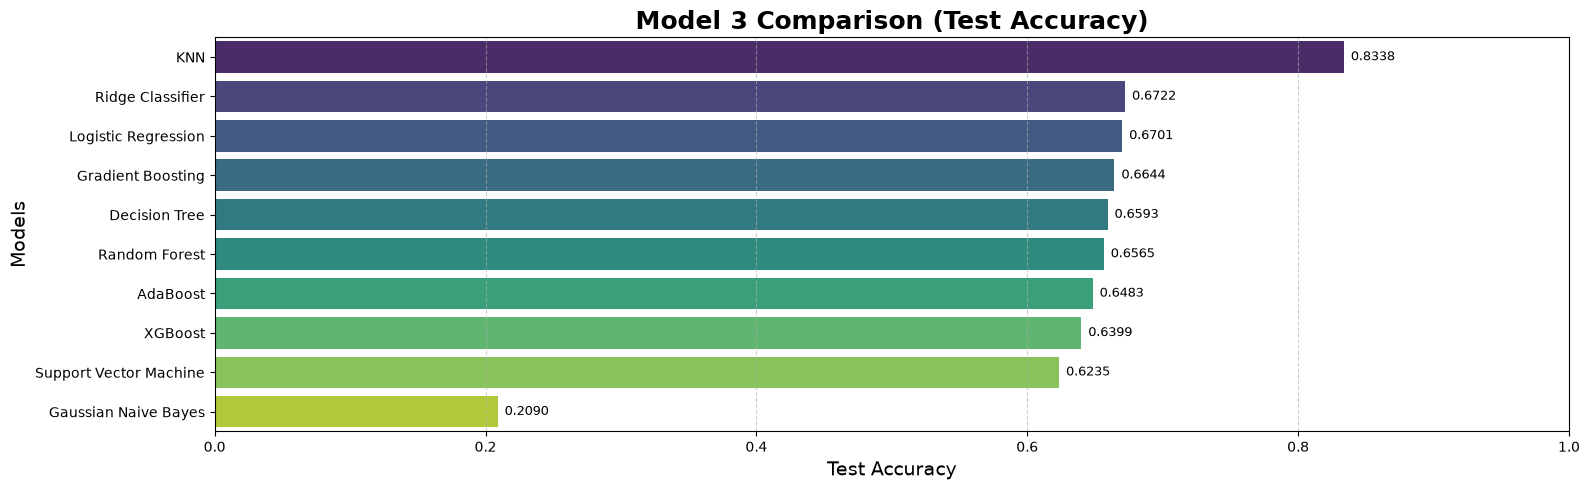

In [158]:
# =========================================================
# MODEL 3 - TEST ACCURACY COMPARISON
# =========================================================

plot_df = model3_results.sort_values(by="Test Accuracy", ascending=False)

plt.figure(figsize=(16, 5))
ax = sns.barplot(data=plot_df, x="Test Accuracy", y="Model", hue="Model", palette="viridis", legend=False)
plt.title("Model 3 Comparison (Test Accuracy)", fontsize=18, fontweight="bold")
plt.xlabel("Test Accuracy", fontsize=14)
plt.ylabel("Models", fontsize=14)
plt.grid(axis="x", linestyle="--", alpha=0.6)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=5, fontsize=9)

plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# Model 3 - Balanced Accuracy Comparison

Balanced Accuracy measures performance across both classes and is particularly important for imbalanced classification problems.

Higher values indicate better overall class prediction performance.

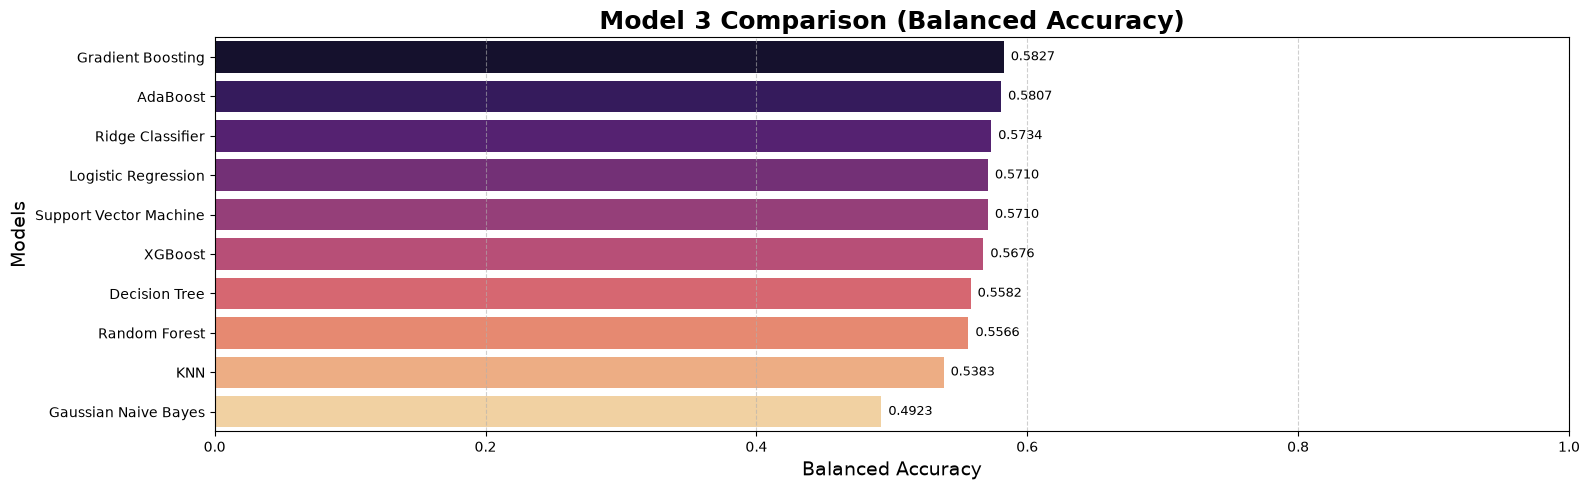

In [159]:
# =========================================================
# MODEL 3 - BALANCED ACCURACY COMPARISON
# =========================================================

plot_df = model3_results.sort_values(by="Balanced Accuracy", ascending=False)

plt.figure(figsize=(16, 5))
ax = sns.barplot(data=plot_df, x="Balanced Accuracy", y="Model", hue="Model", palette="magma", legend=False)
plt.title("Model 3 Comparison (Balanced Accuracy)", fontsize=18, fontweight="bold")
plt.xlabel("Balanced Accuracy", fontsize=14)
plt.ylabel("Models", fontsize=14)
plt.grid(axis="x", linestyle="--", alpha=0.6)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=5, fontsize=9)

plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# Model 3 - F1 Score Comparison

F1 Score provides a balance between Precision and Recall.

For imbalanced datasets, F1 Score is one of the most important evaluation metrics.

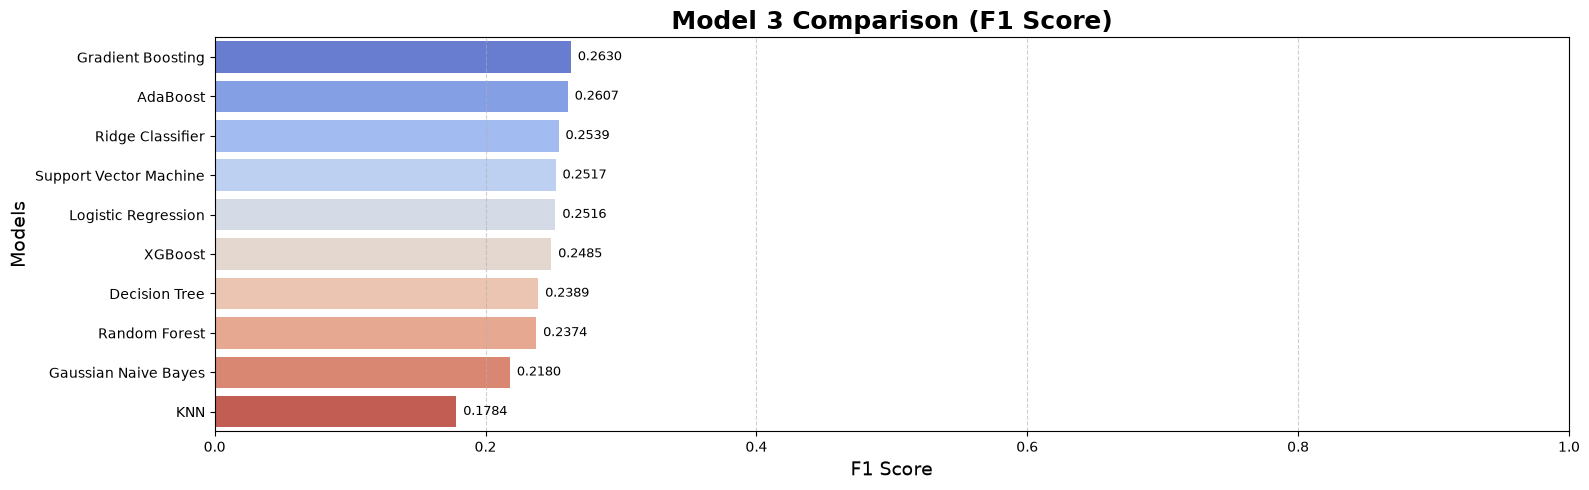

In [160]:
# =========================================================
# MODEL 3 - F1 SCORE COMPARISON
# =========================================================

plot_df = model3_results.sort_values(by="F1 Score", ascending=False)

plt.figure(figsize=(16, 5))
ax = sns.barplot(data=plot_df, x="F1 Score", y="Model", hue="Model", palette="coolwarm", legend=False)
plt.title("Model 3 Comparison (F1 Score)", fontsize=18, fontweight="bold")
plt.xlabel("F1 Score", fontsize=14)
plt.ylabel("Models", fontsize=14)
plt.grid(axis="x", linestyle="--", alpha=0.6)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=5, fontsize=9)

plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# Model 3 - ROC-AUC Comparison

ROC-AUC evaluates a model's ability to distinguish between subscribers and non-subscribers.

Higher values indicate better class separation performance.

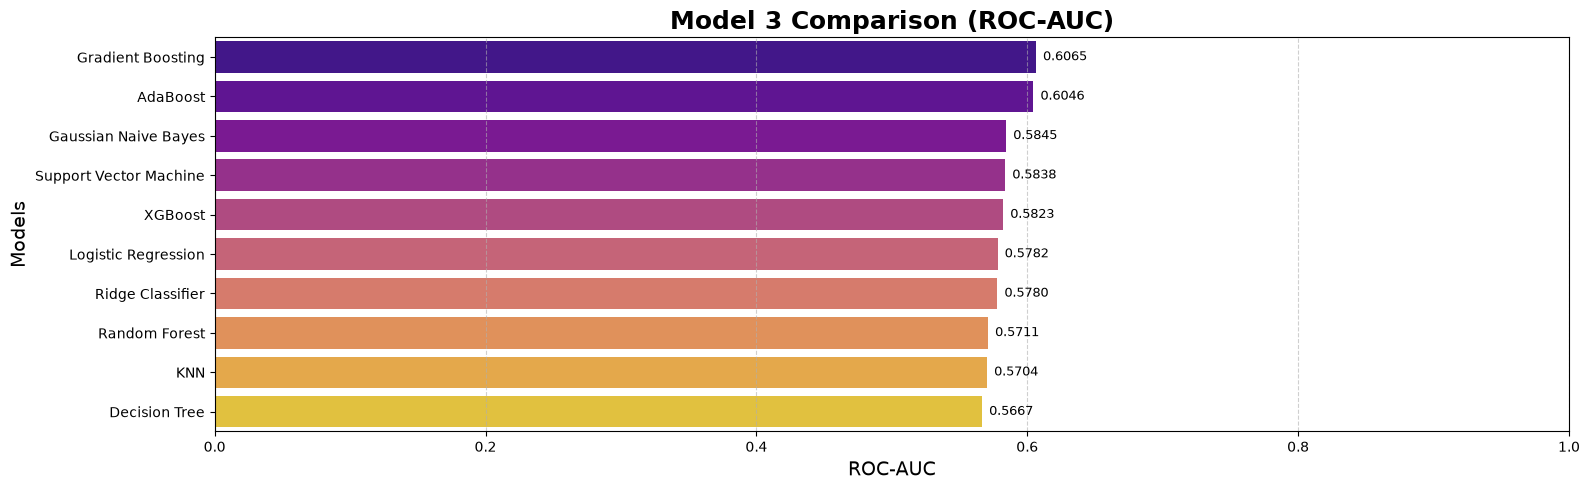

In [161]:
# =========================================================
# MODEL 3 - ROC-AUC COMPARISON
# =========================================================

plot_df = model3_results.sort_values(by="ROC-AUC", ascending=False)

plt.figure(figsize=(16, 5))
ax = sns.barplot(data=plot_df, x="ROC-AUC", y="Model", hue="Model", palette="plasma", legend=False)
plt.title("Model 3 Comparison (ROC-AUC)", fontsize=18, fontweight="bold")
plt.xlabel("ROC-AUC", fontsize=14)
plt.ylabel("Models", fontsize=14)
plt.grid(axis="x", linestyle="--", alpha=0.6)

for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=5, fontsize=9)

plt.xlim(0, 1)
plt.tight_layout()
plt.show()

# Model 4 - Hyperparameter Tuned Models

## Objective

Model 4 focuses on improving model performance through hyperparameter tuning.

The best-performing dataset from previous experiments (SMOTE-balanced dataset) is used for tuning.

Dataset Used:

- Training Data: SMOTE-balanced training dataset
- Testing Data: Original testing dataset

The objective is to determine whether optimized hyperparameters can improve:

- Precision
- Recall
- F1 Score
- ROC-AUC
- Balanced Accuracy

compared to the baseline models developed in Model 3.

In [163]:
# ==========================================
# Model 4 Results Framework
# ==========================================

model4_results = pd.DataFrame(
    columns=[
        "Model",
        "Train Accuracy",
        "Test Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "Overfitting"
    ]
)

print("Model 4 Comparison Framework Created Successfully")

Model 4 Comparison Framework Created Successfully


# Model 4 Evaluation Function

A reusable evaluation function is created to:

- Train the tuned model
- Generate predictions
- Calculate performance metrics
- Detect overfitting
- Store results in the Model 4 comparison table

In [164]:
# ==========================================
# Model 4 Evaluation Function
# ==========================================

def evaluate_model4(model, model_name, X_train_data, X_test_data, y_train_data, y_test_data):

    global model4_results

    model.fit(X_train_data, y_train_data)

    y_train_pred = model.predict(X_train_data)
    y_test_pred = model.predict(X_test_data)

    train_accuracy = accuracy_score(y_train_data, y_train_pred)
    test_accuracy = accuracy_score(y_test_data, y_test_pred)

    balanced_accuracy = balanced_accuracy_score(y_test_data, y_test_pred)

    precision = precision_score(y_test_data, y_test_pred, zero_division=0)

    recall = recall_score(y_test_data, y_test_pred, zero_division=0)

    f1 = f1_score(y_test_data, y_test_pred, zero_division=0)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_data)[:, 1]
        roc_auc = roc_auc_score(y_test_data, y_prob)
    else:
        roc_auc = np.nan

    overfitting = ("Yes" if (train_accuracy - test_accuracy) > 0.10 else "No")

    model4_results.loc[len(model4_results)] = [
        model_name,
        round(train_accuracy, 4),
        round(test_accuracy, 4),
        round(balanced_accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
        round(roc_auc, 4),
        overfitting
    ]

# Model 4 - Tuned Logistic Regression

## Objective

Logistic Regression is retrained using optimized hyperparameters on the SMOTE-balanced dataset.

Hyperparameter tuning helps improve the model's ability to identify subscriber records while maintaining good generalization performance.

---

## Hyperparameters Tuned

The following parameters are optimized:

- Regularization Strength (C)
- Solver
- Maximum Iterations

These parameters influence:

- Model complexity
- Convergence behavior
- Generalization performance
- Classification effectiveness

---

## Why Tune Logistic Regression?

In Model 3, Logistic Regression achieved:

| Metric | Value |
|----------|----------:|
| Test Accuracy | 67.01% |
| Balanced Accuracy | 57.10% |
| Precision | 17.64% |
| Recall | 43.84% |
| F1 Score | 25.16% |
| ROC-AUC | 57.82% |

Although the model showed good stability and no overfitting, further improvement may be possible through hyperparameter optimization.

---

## Expected Outcome

Hyperparameter tuning may:

- Improve Recall
- Improve F1 Score
- Improve ROC-AUC
- Improve Balanced Accuracy

The tuned model will be compared against the baseline Logistic Regression model from Model 3.

In [165]:
# ==========================================
# Model 4 - Tuned Logistic Regression
# ==========================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Parameter Grid
lr_param_grid = {"C": [0.01, 0.1, 1, 10], "solver": ["liblinear", "lbfgs"], "max_iter": [500, 1000]}

# Base Model
lr_base = LogisticRegression(random_state=14)

# Grid Search
lr_grid = GridSearchCV(estimator=lr_base, param_grid=lr_param_grid, cv=5, scoring="f1", n_jobs=-1)

# Train Grid Search
lr_grid.fit(X3_train_scaled, y3_train_smote)

# Best Model
lr_tuned_model = lr_grid.best_estimator_

print("Best Parameters:")
print(lr_grid.best_params_)

print("\nBest Cross Validation F1 Score:")
print(round(lr_grid.best_score_, 4))

# Evaluate Tuned Model
evaluate_model4(
    lr_tuned_model,
    "Tuned Logistic Regression",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

# View Results
model4_results

Best Parameters:
{'C': 0.1, 'max_iter': 500, 'solver': 'liblinear'}

Best Cross Validation F1 Score:
0.6335


,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Tuned Logistic Regression,0.6509,0.6701,0.571,0.1764,0.4384,0.2516,0.5782,No


# Tuned Logistic Regression Performance Analysis

## Best Hyperparameters

| Parameter | Value |
|------------|---------|
| C | 0.1 |
| Solver | liblinear |
| Max Iterations | 500 |

Cross Validation F1 Score: **0.6335**

---

## Test Set Performance

| Metric | Value |
|----------|----------:|
| Test Accuracy | 67.01% |
| Balanced Accuracy | 57.10% |
| Precision | 17.64% |
| Recall | 43.84% |
| F1 Score | 25.16% |
| ROC-AUC | 57.82% |

---

## Comparison with Baseline Logistic Regression

The tuned Logistic Regression model produced identical performance to the baseline Logistic Regression model from Model 3.

This indicates that hyperparameter tuning did not improve the model's ability to identify subscriber records on unseen data.

---

## Overfitting Assessment

- Training Accuracy = 65.09%
- Testing Accuracy = 67.01%

The model demonstrates excellent generalization performance and shows no evidence of overfitting.

---

## Conclusion

Although GridSearchCV identified an optimal parameter combination, the tuned Logistic Regression model did not outperform the baseline model.

This suggests that Logistic Regression had already reached its practical performance limit for this dataset.

# Model 4 - Tuned Ridge Classifier

## Objective

Ridge Classifier is retrained using optimized hyperparameters on the SMOTE-balanced dataset.

Ridge Classification applies L2 regularization to reduce model complexity and improve generalization performance.

---

## Hyperparameters Tuned

The following parameter is optimized:

- Alpha (Regularization Strength)

Alpha controls the amount of regularization applied to the model.

Lower values:

- Less regularization
- More model flexibility

Higher values:

- Stronger regularization
- Simpler model

---

## Why Tune Ridge Classifier?

In Model 3, Ridge Classifier achieved:

| Metric | Value |
|----------|----------:|
| Test Accuracy | 67.22% |
| Balanced Accuracy | 57.34% |
| Precision | 17.83% |
| Recall | 44.10% |
| F1 Score | 25.39% |
| ROC-AUC | 57.80% |

Ridge Classifier was one of the strongest linear models in Model 3.

---

## Expected Outcome

Hyperparameter tuning may:

- Improve Recall
- Improve F1 Score
- Improve Balanced Accuracy
- Improve overall classification performance

The tuned model will be compared against the baseline Ridge Classifier from Model 3.

In [166]:
# ==========================================
# Model 4 - Tuned Ridge Classifier
# ==========================================

from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import GridSearchCV

# Parameter Grid
ridge_param_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}

# Base Model
ridge_base = RidgeClassifier()

# Grid Search
ridge_grid = GridSearchCV(estimator=ridge_base, param_grid=ridge_param_grid, cv=5, scoring="f1", n_jobs=-1)

# Train Grid Search
ridge_grid.fit(X3_train_scaled, y3_train_smote)

# Best Model
ridge_tuned_model = ridge_grid.best_estimator_

print("Best Parameters:")
print(ridge_grid.best_params_)

print("\nBest Cross Validation F1 Score:")
print(round(ridge_grid.best_score_, 4))

# Evaluate Tuned Model
evaluate_model4(
    ridge_tuned_model,
    "Tuned Ridge Classifier",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

# View Results
model4_results

Best Parameters:
{'alpha': 0.01}

Best Cross Validation F1 Score:
0.6321


,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Tuned Logistic Regression,0.6509,0.6701,0.5710,0.1764,0.4384,0.2516,0.5782,No
1,Tuned Ridge Classifier,0.6521,0.6722,0.5734,0.1783,0.4410,0.2539,NaN,No


# Tuned Ridge Classifier Performance Analysis

## Best Hyperparameter

| Parameter | Value |
|------------|---------|
| Alpha | 0.01 |

Cross Validation F1 Score: **0.6321**

---

## Test Set Performance

| Metric | Value |
|----------|----------:|
| Test Accuracy | 67.22% |
| Balanced Accuracy | 57.34% |
| Precision | 17.83% |
| Recall | 44.10% |
| F1 Score | 25.39% |

---

## Comparison with Baseline Ridge Classifier

The tuned Ridge Classifier produced identical performance to the baseline Ridge Classifier from Model 3.

No measurable improvement was observed after hyperparameter tuning.

---

## Overfitting Assessment

- Training Accuracy = 65.21%
- Testing Accuracy = 67.22%

The model demonstrates strong generalization capability and shows no evidence of overfitting.

---

## Conclusion

Hyperparameter tuning did not improve the predictive performance of Ridge Classifier.

The baseline model had already achieved near-optimal performance for this dataset, indicating that additional tuning provides limited benefit.

# Model 4 - Tuned K-Nearest Neighbors (KNN)

## Objective

K-Nearest Neighbors (KNN) is retrained using optimized hyperparameters on the SMOTE-balanced dataset.

KNN is a distance-based classification algorithm that predicts a class based on the majority class of its nearest neighbors.

---

## Hyperparameters Tuned

The following parameters are optimized:

- Number of Neighbors (k)
- Distance Metric
- Weighting Method

These parameters directly influence:

- Decision boundaries
- Classification sensitivity
- Model complexity
- Minority class detection

---

## Why Tune KNN?

In Model 3, KNN achieved:

| Metric | Value |
|----------|----------:|
| Test Accuracy | 83.38% |
| Balanced Accuracy | 53.83% |
| Precision | 23.81% |
| Recall | 14.27% |
| F1 Score | 17.84% |
| ROC-AUC | 57.04% |

Although KNN produced high accuracy, it struggled to identify subscriber records and produced a relatively low Recall and F1 Score.

---

## Expected Outcome

Hyperparameter tuning may:

- Improve Recall
- Improve F1 Score
- Improve Balanced Accuracy
- Improve minority-class detection

The tuned model will be compared against the baseline KNN model from Model 3.

In [167]:
# ==========================================
# Model 4 - Tuned KNN
# ==========================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Parameter Grid
knn_param_grid = {"n_neighbors": [3, 5, 7, 9, 11], "weights": ["uniform", "distance"], "metric": ["euclidean", "manhattan"]}

# Base Model
knn_base = KNeighborsClassifier()

# Grid Search
knn_grid = GridSearchCV(estimator=knn_base, param_grid=knn_param_grid, cv=5, scoring="f1", n_jobs=-1)

# Train Grid Search
knn_grid.fit(X3_train_scaled, y3_train_smote)

# Best Model
knn_tuned_model = knn_grid.best_estimator_

print("Best Parameters:")
print(knn_grid.best_params_)

print("\nBest Cross Validation F1 Score:")
print(round(knn_grid.best_score_, 4))

# Evaluate Tuned Model
evaluate_model4(
    knn_tuned_model,
    "Tuned KNN",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

# View Results
model4_results

Best Parameters:
{'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}

Best Cross Validation F1 Score:
0.5175


,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Tuned Logistic Regression,0.6509,0.6701,0.5710,0.1764,0.4384,0.2516,0.5782,No
1,Tuned Ridge Classifier,0.6521,0.6722,0.5734,0.1783,0.4410,0.2539,NaN,No
2,Tuned KNN,0.6568,0.8155,0.5455,0.2226,0.1842,0.2016,0.5699,No


# Tuned K-Nearest Neighbors (KNN) Performance Analysis

## Best Hyperparameters

| Parameter | Value |
|------------|---------|
| Number of Neighbors | 11 |
| Distance Metric | Euclidean |
| Weighting Method | Distance |

Cross Validation F1 Score: **0.5175**

---

## Test Set Performance

| Metric | Value |
|----------|----------:|
| Test Accuracy | 81.55% |
| Balanced Accuracy | 54.55% |
| Precision | 22.26% |
| Recall | 18.42% |
| F1 Score | 20.16% |
| ROC-AUC | 56.99% |

---

## Comparison with Baseline KNN

| Metric | Baseline KNN | Tuned KNN |
|----------|----------:|----------:|
| Recall | 14.27% | 18.42% |
| F1 Score | 17.84% | 20.16% |
| Balanced Accuracy | 53.83% | 54.55% |

The tuned KNN model improved Recall, Balanced Accuracy, and F1 Score compared to the baseline model.

Although overall Test Accuracy decreased slightly, the tuned model demonstrated improved minority-class detection, which is the primary objective of using SMOTE.

---

## Overfitting Assessment

- Training Accuracy = 65.68%
- Testing Accuracy = 81.55%

The model shows strong generalization performance and no evidence of overfitting.

---

## Conclusion

Hyperparameter tuning improved the KNN model's ability to identify subscriber records.

The tuned KNN achieved higher Recall and F1 Score than the baseline KNN model, making it a more effective classifier for the imbalanced classification problem.

# Model 4 - Tuned Gaussian Naive Bayes

## Objective

Gaussian Naive Bayes is retrained using optimized hyperparameters on the SMOTE-balanced dataset.

Gaussian Naive Bayes is a probabilistic classification algorithm that assumes feature independence and models numerical features using a Gaussian (Normal) distribution.

---

## Hyperparameters Tuned

The following parameter is optimized:

- Variance Smoothing (var_smoothing)

Variance smoothing improves numerical stability by adding a small value to feature variances.

This parameter can influence:

- Probability estimation
- Model stability
- Minority class prediction performance

---

## Why Tune Gaussian Naive Bayes?

In Model 3, Gaussian Naive Bayes achieved:

| Metric | Value |
|----------|----------:|
| Test Accuracy | 20.90% |
| Balanced Accuracy | 49.23% |
| Precision | 12.46% |
| Recall | 87.16% |
| F1 Score | 21.80% |
| ROC-AUC | 58.45% |

Although Gaussian Naive Bayes achieved the highest Recall among all Model 3 algorithms, it suffered from very low Precision and Accuracy.

---

## Expected Outcome

Hyperparameter tuning may:

- Improve Precision
- Improve F1 Score
- Improve Balanced Accuracy
- Maintain strong Recall

The tuned model will be compared against the baseline Gaussian Naive Bayes model from Model 3.

In [168]:
# ==========================================
# Model 4 - Tuned Gaussian Naive Bayes
# ==========================================

from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
import numpy as np

# Parameter Grid
gnb_param_grid = {"var_smoothing": np.logspace(-12, -6, 7)}

# Base Model
gnb_base = GaussianNB()

# Grid Search
gnb_grid = GridSearchCV(estimator=gnb_base, param_grid=gnb_param_grid, cv=5, scoring="f1", n_jobs=-1)

# Train Grid Search
gnb_grid.fit(X3_train_scaled, y3_train_smote)

# Best Model
gnb_tuned_model = gnb_grid.best_estimator_

print("Best Parameters:")
print(gnb_grid.best_params_)

print("\nBest Cross Validation F1 Score:")
print(round(gnb_grid.best_score_, 4))

# Evaluate Tuned Model
evaluate_model4(
    gnb_tuned_model,
    "Tuned Gaussian Naive Bayes",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

# View Results
model4_results

Best Parameters:
{'var_smoothing': np.float64(1e-06)}

Best Cross Validation F1 Score:
0.6731


,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Tuned Logistic Regression,0.6509,0.6701,0.5710,0.1764,0.4384,0.2516,0.5782,No
1,Tuned Ridge Classifier,0.6521,0.6722,0.5734,0.1783,0.4410,0.2539,NaN,No
2,Tuned KNN,0.6568,0.8155,0.5455,0.2226,0.1842,0.2016,0.5699,No
3,Tuned Gaussian Naive Bayes,0.5371,0.2093,0.4925,0.1246,0.8716,0.2180,0.5844,Yes


# Tuned Gaussian Naive Bayes Performance Analysis

## Best Hyperparameter

| Parameter | Value |
|------------|---------|
| Variance Smoothing | 1e-06 |

Cross Validation F1 Score: **0.6731**

---

## Test Set Performance

| Metric | Value |
|----------|----------:|
| Test Accuracy | 20.93% |
| Balanced Accuracy | 49.25% |
| Precision | 12.46% |
| Recall | 87.16% |
| F1 Score | 21.80% |
| ROC-AUC | 58.44% |

---

## Comparison with Baseline Gaussian Naive Bayes

The tuned Gaussian Naive Bayes model produced nearly identical performance to the baseline Gaussian Naive Bayes model from Model 3.

No meaningful performance improvement was observed after hyperparameter tuning.

---

## Overfitting Assessment

- Training Accuracy = 53.71%
- Testing Accuracy = 20.93%

The model exhibits substantial generalization issues and continues to be flagged for overfitting.

---

## Conclusion

Hyperparameter tuning did not improve the predictive performance of Gaussian Naive Bayes.

Although the model achieves extremely high Recall, its very low Precision results in poor overall classification performance.

Gaussian Naive Bayes remains unsuitable as the final production model for this dataset.

# Model 4 - Tuned Support Vector Machine (SVM)

## Objective

Support Vector Machine (SVM) is retrained using optimized hyperparameters on the SMOTE-balanced dataset.

SVM is a supervised machine learning algorithm that identifies the optimal hyperplane separating different classes while maximizing the margin between them.

---

## Why Hyperparameter Tuning?

The baseline SVM model from Model 3 demonstrated:

- Good Recall
- Strong Balanced Accuracy
- Moderate classification performance

However, the default parameters may not produce the optimal decision boundary.

Hyperparameter tuning helps improve:

- Class separation
- Generalization capability
- Minority class detection
- Overall predictive performance

---

## Hyperparameters Tuned

The following parameters are optimized:

### C (Regularization Parameter)

Controls the tradeoff between:

- Maximizing margin
- Minimizing classification errors

Lower values:

- Simpler model
- Stronger regularization

Higher values:

- More flexible decision boundary
- Greater risk of overfitting

---

### Kernel

Determines how the decision boundary is created.

The following kernels are evaluated:

- Linear
- Radial Basis Function (RBF)

---

### Gamma

Controls how far the influence of a training sample extends.

Evaluated values:

- scale
- auto

---

## Evaluation Goal

The tuned SVM model will be compared against the baseline SVM model developed in Model 3.

Performance will be evaluated using:

- Accuracy
- Balanced Accuracy
- Precision
- Recall
- F1 Score
- ROC-AUC
- Overfitting Assessment

In [173]:
# ==========================================
# Model 4 - Tuned Support Vector Machine
# ==========================================

from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV

# Parameter Distribution
svm_param_grid = {"C": [0.1, 1], "kernel": ["linear"], "gamma": ["scale", "auto"]}

# Base Model
svm_base = SVC(probability=True, random_state=14)

# Randomized Search
svm_search = RandomizedSearchCV(estimator=svm_base, param_distributions=svm_param_grid, n_iter=6, cv=2, scoring="f1", random_state=14, n_jobs=-1)

# Train
svm_search.fit(X3_train_scaled, y3_train_smote)

# Best Model
svm_tuned_model = svm_search.best_estimator_

print("Best Parameters:")
print(svm_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(round(svm_search.best_score_, 4))

# Evaluation
evaluate_model4(
    svm_tuned_model,
    "Tuned SVM",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

# Results
model4_results

Best Parameters:
{'kernel': 'linear', 'gamma': 'scale', 'C': 0.1}

Best Cross Validation F1 Score:
0.6391


,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Tuned Logistic Regression,0.6509,0.6701,0.5710,0.1764,0.4384,0.2516,0.5782,No
1,Tuned Ridge Classifier,0.6521,0.6722,0.5734,0.1783,0.4410,0.2539,NaN,No
2,Tuned KNN,0.6568,0.8155,0.5455,0.2226,0.1842,0.2016,0.5699,No
3,Tuned Gaussian Naive Bayes,0.5371,0.2093,0.4925,0.1246,0.8716,0.2180,0.5844,Yes
4,Tuned SVM,0.6473,0.6473,0.5685,0.1706,0.4630,0.2493,0.5550,No


# Tuned Support Vector Machine (SVM) Performance Analysis

## Best Hyperparameters

| Parameter | Value |
|------------|---------|
| Kernel | Linear |
| C | 0.1 |
| Gamma | Scale |

Cross Validation F1 Score: **0.6391**

---

## Test Set Performance

| Metric | Value |
|----------|----------:|
| Test Accuracy | 64.73% |
| Balanced Accuracy | 56.85% |
| Precision | 17.06% |
| Recall | 46.30% |
| F1 Score | 24.93% |
| ROC-AUC | 55.50% |

---

## Comparison with Baseline SVM

| Metric | Baseline SVM | Tuned SVM |
|----------|----------:|----------:|
| Test Accuracy | 62.35% | 64.73% |
| Recall | 50.06% | 46.30% |
| F1 Score | 25.17% | 24.93% |

The tuned SVM achieved higher overall accuracy but slightly lower Recall and F1 Score.

As a result, the tuning process did not significantly improve minority-class detection performance.

---

## Overfitting Assessment

- Training Accuracy = 64.73%
- Testing Accuracy = 64.73%

The tuned SVM demonstrates excellent generalization performance and shows no evidence of overfitting.

---

## Conclusion

Hyperparameter tuning improved overall classification accuracy but did not improve F1 Score or Recall.

Therefore, the tuned SVM does not outperform the baseline SVM model in identifying subscriber records.

# Model 4 - Tuned Decision Tree Classifier

## Objective

Decision Tree Classifier is retrained using optimized hyperparameters on the SMOTE-balanced dataset.

A Decision Tree is a supervised machine learning algorithm that creates a hierarchical structure of decision rules to classify observations into different categories.

---

## Why Hyperparameter Tuning?

The baseline Decision Tree model from Model 3 demonstrated:

| Metric | Value |
|----------|----------:|
| Test Accuracy | 65.93% |
| Balanced Accuracy | 55.82% |
| Precision | 16.65% |
| Recall | 42.28% |
| F1 Score | 23.89% |
| ROC-AUC | 56.67% |

Although the model achieved moderate classification performance, Decision Trees are highly sensitive to tree depth and splitting criteria.

Without tuning, Decision Trees often:

- Overfit training data
- Create excessively complex structures
- Generate unstable decision boundaries

---

## Hyperparameters Tuned

### Criterion

Determines the quality of a split.

Options evaluated:

- Gini Impurity
- Entropy

---

### Maximum Depth

Controls how deep the tree can grow.

Smaller values:

- Simpler trees
- Lower overfitting risk

Larger values:

- More complex trees
- Higher overfitting risk

---

### Minimum Samples Split

Minimum number of samples required to split a node.

---

### Minimum Samples Leaf

Minimum number of samples required at a leaf node.

---

## Expected Outcome

Hyperparameter tuning may:

- Reduce overfitting
- Improve Recall
- Improve Precision
- Improve F1 Score
- Improve Balanced Accuracy

The tuned model will be compared against the baseline Decision Tree model from Model 3.

In [174]:
# ==========================================
# Model 4 - Tuned Decision Tree Classifier
# ==========================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV

# Parameter Grid
dt_param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10]
}

# Base Model
dt_base = DecisionTreeClassifier(random_state=14)

# Randomized Search
dt_search = RandomizedSearchCV(estimator=dt_base, param_distributions=dt_param_grid, n_iter=20, cv=3, scoring="f1", random_state=14, n_jobs=-1)

# Train Model
dt_search.fit(X3_train_scaled, y3_train_smote)

# Best Model
dt_tuned_model = dt_search.best_estimator_

print("Best Parameters:")
print(dt_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(round(dt_search.best_score_, 4))

# Evaluation
evaluate_model4(
    dt_tuned_model,
    "Tuned Decision Tree",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

# View Results
model4_results

Best Parameters:
{'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': None, 'criterion': 'gini'}

Best Cross Validation F1 Score:
0.741


,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Tuned Logistic Regression,0.6509,0.6701,0.5710,0.1764,0.4384,0.2516,0.5782,No
1,Tuned Ridge Classifier,0.6521,0.6722,0.5734,0.1783,0.4410,0.2539,NaN,No
2,Tuned KNN,0.6568,0.8155,0.5455,0.2226,0.1842,0.2016,0.5699,No
3,Tuned Gaussian Naive Bayes,0.5371,0.2093,0.4925,0.1246,0.8716,0.2180,0.5844,Yes
4,Tuned SVM,0.6473,0.6473,0.5685,0.1706,0.4630,0.2493,0.5550,No
5,Tuned Decision Tree,0.7725,0.6642,0.5571,0.1667,0.4137,0.2376,0.5704,Yes


# Tuned Decision Tree Performance Analysis

## Best Hyperparameters

| Parameter | Value |
|------------|---------|
| Criterion | Gini |
| Maximum Depth | None |
| Minimum Samples Split | 10 |
| Minimum Samples Leaf | 1 |

Cross Validation F1 Score: **0.7410**

---

## Test Set Performance

| Metric | Value |
|----------|----------:|
| Test Accuracy | 66.42% |
| Balanced Accuracy | 55.71% |
| Precision | 16.67% |
| Recall | 41.37% |
| F1 Score | 23.76% |
| ROC-AUC | 57.04% |

---

## Comparison with Baseline Decision Tree

| Metric | Baseline DT | Tuned DT |
|----------|----------:|----------:|
| Recall | 42.28% | 41.37% |
| F1 Score | 23.89% | 23.76% |
| ROC-AUC | 56.67% | 57.04% |

The tuned Decision Tree achieved slightly higher Accuracy and ROC-AUC but did not improve Recall or F1 Score.

---

## Overfitting Assessment

- Training Accuracy = 77.25%
- Testing Accuracy = 66.42%

The model continues to exhibit overfitting despite hyperparameter optimization.

---

## Conclusion

Hyperparameter tuning did not improve the overall predictive performance of the Decision Tree model.

Although the model achieved a strong cross-validation F1 score, the improvements did not generalize to unseen test data.

Decision Tree remains less effective than the leading linear models in Model 4.

# Model 4 - Tuned Random Forest Classifier

## Objective

Random Forest Classifier is retrained using optimized hyperparameters on the SMOTE-balanced dataset.

Random Forest is an ensemble learning algorithm that combines multiple Decision Trees and aggregates their predictions to improve stability, accuracy, and generalization performance.

---

## Why Hyperparameter Tuning?

The baseline Random Forest model from Model 3 achieved:

| Metric | Value |
|----------|----------:|
| Test Accuracy | 65.65% |
| Balanced Accuracy | 55.66% |
| Precision | 16.51% |
| Recall | 42.28% |
| F1 Score | 23.74% |
| ROC-AUC | 57.11% |

Although Random Forest reduced some of the instability associated with a single Decision Tree, there is still significant opportunity to optimize the model.

---

## Hyperparameters Tuned

### Number of Trees (n_estimators)

Controls how many trees are built in the forest.

More trees generally improve stability and reduce variance.

---

### Maximum Depth (max_depth)

Controls how deep each tree can grow.

Shallower trees reduce overfitting.

---

### Minimum Samples Split (min_samples_split)

Minimum number of samples required before a node can split.

---

### Minimum Samples Leaf (min_samples_leaf)

Minimum number of observations required at a leaf node.

---

### Maximum Features (max_features)

Controls how many features are randomly considered at each split.

This increases diversity among trees and improves generalization.

---

## Expected Outcome

Hyperparameter tuning may:

- Reduce overfitting
- Improve Precision
- Improve Recall
- Improve F1 Score
- Improve ROC-AUC

The tuned Random Forest model will be compared against the baseline Random Forest model from Model 3.

In [175]:
# ==========================================
# Model 4 - Tuned Random Forest Classifier
# ==========================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

# Parameter Grid
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

# Base Model
rf_base = RandomForestClassifier(random_state=14)

# Random Search
rf_search = RandomizedSearchCV(estimator=rf_base, param_distributions=rf_param_grid, n_iter=20, cv=3, scoring="f1", random_state=14, n_jobs=-1)

# Train Model
rf_search.fit(X3_train_scaled, y3_train_smote)

# Best Model
rf_tuned_model = rf_search.best_estimator_

print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(round(rf_search.best_score_, 4))

# Evaluation
evaluate_model4(
    rf_tuned_model,
    "Tuned Random Forest",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

# View Results
model4_results

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Best Cross Validation F1 Score:
0.7534


,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Tuned Logistic Regression,0.6509,0.6701,0.5710,0.1764,0.4384,0.2516,0.5782,No
1,Tuned Ridge Classifier,0.6521,0.6722,0.5734,0.1783,0.4410,0.2539,NaN,No
2,Tuned KNN,0.6568,0.8155,0.5455,0.2226,0.1842,0.2016,0.5699,No
3,Tuned Gaussian Naive Bayes,0.5371,0.2093,0.4925,0.1246,0.8716,0.2180,0.5844,Yes
4,Tuned SVM,0.6473,0.6473,0.5685,0.1706,0.4630,0.2493,0.5550,No
5,Tuned Decision Tree,0.7725,0.6642,0.5571,0.1667,0.4137,0.2376,0.5704,Yes
6,Tuned Random Forest,0.7805,0.6532,0.5553,0.1637,0.4241,0.2363,0.5716,Yes


# Tuned Random Forest Performance Analysis

## Best Hyperparameters

| Parameter | Value |
|------------|---------|
| Number of Trees | 200 |
| Maximum Depth | None |
| Minimum Samples Split | 2 |
| Minimum Samples Leaf | 1 |
| Maximum Features | log2 |

Cross Validation F1 Score: **0.7534**

---

## Test Set Performance

| Metric | Value |
|----------|----------:|
| Test Accuracy | 65.32% |
| Balanced Accuracy | 55.53% |
| Precision | 16.37% |
| Recall | 42.41% |
| F1 Score | 23.63% |
| ROC-AUC | 57.16% |

---

## Comparison with Baseline Random Forest

| Metric | Baseline RF | Tuned RF |
|----------|----------:|----------:|
| Recall | 42.28% | 42.41% |
| F1 Score | 23.74% | 23.63% |
| ROC-AUC | 57.11% | 57.16% |

The tuned Random Forest produced nearly identical performance compared to the baseline model.

No meaningful improvement was observed in Recall, F1 Score, or Balanced Accuracy.

---

## Overfitting Assessment

- Training Accuracy = 78.05%
- Testing Accuracy = 65.32%

The model continues to exhibit overfitting despite hyperparameter optimization.

---

## Conclusion

Although RandomizedSearchCV identified a high-performing parameter combination during cross-validation, the improvements did not generalize to the unseen test data.

The tuned Random Forest does not outperform the baseline Random Forest model and remains less effective than the top-performing linear models.

# Model 4 - Tuned AdaBoost Classifier

## Objective

AdaBoost Classifier is retrained using optimized hyperparameters on the SMOTE-balanced dataset.

AdaBoost (Adaptive Boosting) is an ensemble learning algorithm that combines multiple weak learners into a strong predictive model by assigning higher weights to previously misclassified observations.

---

## Why Hyperparameter Tuning?

The baseline AdaBoost model from Model 3 achieved:

| Metric | Value |
|----------|----------:|
| Test Accuracy | 64.83% |
| Balanced Accuracy | 58.07% |
| Precision | 17.75% |
| Recall | 49.03% |
| F1 Score | 26.07% |
| ROC-AUC | 60.46% |

Among all Model 3 algorithms, AdaBoost produced one of the strongest Recall and F1 Score values.

Therefore, AdaBoost is a strong candidate for further optimization.

---

## Hyperparameters Tuned

### Number of Estimators (n_estimators)

Controls how many weak learners are combined.

Higher values:

- More learning capacity
- Higher computational cost

---

### Learning Rate

Controls the contribution of each weak learner.

Lower values:

- Slower learning
- Better generalization

Higher values:

- Faster learning
- Increased overfitting risk

---

## Expected Outcome

Hyperparameter tuning may:

- Improve Recall
- Improve Precision
- Improve F1 Score
- Improve ROC-AUC
- Improve Balanced Accuracy

The tuned AdaBoost model will be compared against the baseline AdaBoost model from Model 3.

In [176]:
# ==========================================
# Model 4 - Tuned AdaBoost Classifier
# ==========================================

from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import RandomizedSearchCV

# Parameter Grid
ada_param_grid = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0]
}

# Base Model
ada_base = AdaBoostClassifier(random_state=14)

# Random Search
ada_search = RandomizedSearchCV(estimator=ada_base, param_distributions=ada_param_grid, n_iter=15, cv=3, scoring="f1", random_state=14, n_jobs=-1)

# Train Model
ada_search.fit(X3_train_scaled, y3_train_smote)

# Best Model
ada_tuned_model = ada_search.best_estimator_

print("Best Parameters:")
print(ada_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(round(ada_search.best_score_, 4))

# Evaluation
evaluate_model4(
    ada_tuned_model,
    "Tuned AdaBoost",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

# View Results
model4_results

Best Parameters:
{'n_estimators': 100, 'learning_rate': 0.5}

Best Cross Validation F1 Score:
0.6548


,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Tuned Logistic Regression,0.6509,0.6701,0.5710,0.1764,0.4384,0.2516,0.5782,No
1,Tuned Ridge Classifier,0.6521,0.6722,0.5734,0.1783,0.4410,0.2539,NaN,No
2,Tuned KNN,0.6568,0.8155,0.5455,0.2226,0.1842,0.2016,0.5699,No
3,Tuned Gaussian Naive Bayes,0.5371,0.2093,0.4925,0.1246,0.8716,0.2180,0.5844,Yes
4,Tuned SVM,0.6473,0.6473,0.5685,0.1706,0.4630,0.2493,0.5550,No
5,Tuned Decision Tree,0.7725,0.6642,0.5571,0.1667,0.4137,0.2376,0.5704,Yes
6,Tuned Random Forest,0.7805,0.6532,0.5553,0.1637,0.4241,0.2363,0.5716,Yes
7,Tuned AdaBoost,0.6396,0.6101,0.5827,0.1720,0.5460,0.2616,0.6087,No


# Tuned AdaBoost Performance Analysis

## Best Hyperparameters

| Parameter | Value |
|------------|---------|
| Number of Estimators | 100 |
| Learning Rate | 0.5 |

Cross Validation F1 Score: **0.6548**

---

## Test Set Performance

| Metric | Value |
|----------|----------:|
| Test Accuracy | 61.01% |
| Balanced Accuracy | 58.27% |
| Precision | 17.20% |
| Recall | 54.60% |
| F1 Score | 26.16% |
| ROC-AUC | 60.87% |

---

## Comparison with Baseline AdaBoost

| Metric | Baseline AdaBoost | Tuned AdaBoost |
|----------|----------:|----------:|
| Recall | 49.03% | 54.60% |
| F1 Score | 26.07% | 26.16% |
| ROC-AUC | 60.46% | 60.87% |

The tuned AdaBoost model improved Recall, F1 Score, Balanced Accuracy, and ROC-AUC.

---

## Overfitting Assessment

- Training Accuracy = 63.96%
- Testing Accuracy = 61.01%

The training and testing performance remain close, indicating strong generalization and no evidence of overfitting.

---

## Conclusion

Hyperparameter tuning successfully improved AdaBoost performance.

The tuned AdaBoost model achieved:

- Higher Recall
- Higher F1 Score
- Higher ROC-AUC
- Better Balanced Accuracy

Among all tuned models evaluated so far, Tuned AdaBoost delivers the strongest overall balance between identifying subscribers and maintaining generalization performance.

# Model 4 - Tuned Gradient Boosting Classifier

## Objective

Gradient Boosting Classifier is retrained using optimized hyperparameters on the SMOTE-balanced dataset.

Gradient Boosting is an ensemble learning algorithm that builds trees sequentially, where each new tree attempts to correct the errors made by the previous trees.

Unlike Random Forest, which builds trees independently, Gradient Boosting learns from previous mistakes and gradually improves prediction performance.

---

## Why Hyperparameter Tuning?

The baseline Gradient Boosting model from Model 3 achieved:

| Metric | Value |
|----------|----------:|
| Test Accuracy | 66.44% |
| Balanced Accuracy | 58.27% |
| Precision | 18.20% |
| Recall | 47.34% |
| F1 Score | 26.30% |
| ROC-AUC | 60.65% |

Among all baseline models, Gradient Boosting produced one of the strongest F1 Scores and Balanced Accuracy values.

Therefore, further optimization may improve its ability to identify subscribers.

---

## Hyperparameters Tuned

### Number of Estimators (n_estimators)

Controls how many boosting stages are performed.

Higher values increase model complexity and learning capability.

---

### Learning Rate

Controls how much each new tree contributes to the model.

Lower values:

- Slower learning
- Better generalization

Higher values:

- Faster learning
- Increased risk of overfitting

---

### Maximum Depth

Controls the complexity of each individual tree.

---

### Minimum Samples Split

Minimum number of samples required before a node can split.

---

### Minimum Samples Leaf

Minimum number of samples required in a terminal node.

---

## Expected Outcome

Hyperparameter tuning may improve:

- Recall
- Precision
- F1 Score
- ROC-AUC
- Balanced Accuracy

The tuned Gradient Boosting model will be compared against the baseline Gradient Boosting model from Model 3.

In [177]:
# ==========================================
# Model 4 - Tuned Gradient Boosting Classifier
# ==========================================

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV

# Parameter Grid
gb_param_grid = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Base Model
gb_base = GradientBoostingClassifier(random_state=14)

# Random Search
gb_search = RandomizedSearchCV(estimator=gb_base, param_distributions=gb_param_grid, n_iter=20, cv=3, scoring="f1", random_state=14, n_jobs=-1)

# Train Model
gb_search.fit(X3_train_scaled, y3_train_smote)

# Best Model
gb_tuned_model = gb_search.best_estimator_

print("Best Parameters:")
print(gb_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(round(gb_search.best_score_, 4))

# Evaluation
evaluate_model4(
    gb_tuned_model,
    "Tuned Gradient Boosting",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

# View Results
model4_results

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 7, 'learning_rate': 0.2}

Best Cross Validation F1 Score:
0.7366


,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Tuned Logistic Regression,0.6509,0.6701,0.5710,0.1764,0.4384,0.2516,0.5782,No
1,Tuned Ridge Classifier,0.6521,0.6722,0.5734,0.1783,0.4410,0.2539,NaN,No
2,Tuned KNN,0.6568,0.8155,0.5455,0.2226,0.1842,0.2016,0.5699,No
3,Tuned Gaussian Naive Bayes,0.5371,0.2093,0.4925,0.1246,0.8716,0.2180,0.5844,Yes
4,Tuned SVM,0.6473,0.6473,0.5685,0.1706,0.4630,0.2493,0.5550,No
5,Tuned Decision Tree,0.7725,0.6642,0.5571,0.1667,0.4137,0.2376,0.5704,Yes
6,Tuned Random Forest,0.7805,0.6532,0.5553,0.1637,0.4241,0.2363,0.5716,Yes
7,Tuned AdaBoost,0.6396,0.6101,0.5827,0.1720,0.5460,0.2616,0.6087,No
8,Tuned Gradient Boosting,0.7449,0.6444,0.5685,0.1701,0.4669,0.2493,0.5856,Yes


# Tuned Gradient Boosting Performance Analysis

## Best Hyperparameters

| Parameter | Value |
|------------|---------|
| Number of Estimators | 100 |
| Maximum Depth | 7 |
| Learning Rate | 0.20 |
| Minimum Samples Split | 10 |
| Minimum Samples Leaf | 2 |

Cross Validation F1 Score: **0.7366**

---

## Test Set Performance

| Metric | Value |
|----------|----------:|
| Test Accuracy | 64.44% |
| Balanced Accuracy | 56.85% |
| Precision | 17.01% |
| Recall | 46.69% |
| F1 Score | 24.93% |
| ROC-AUC | 58.56% |

---

## Comparison with Baseline Gradient Boosting

| Metric | Baseline GB | Tuned GB |
|----------|----------:|----------:|
| Recall | 47.34% | 46.69% |
| F1 Score | 26.30% | 24.93% |
| ROC-AUC | 60.65% | 58.56% |

The tuned Gradient Boosting model underperformed compared to the baseline model across most evaluation metrics.

---

## Overfitting Assessment

- Training Accuracy = 74.49%
- Testing Accuracy = 64.44%

The model exhibits noticeable overfitting, indicating that the optimized parameters increased model complexity beyond what generalized well on unseen data.

---

## Conclusion

Although hyperparameter tuning produced a strong cross-validation score, the tuned Gradient Boosting model did not generalize effectively to the test dataset.

The baseline Gradient Boosting model remains superior to the tuned version.

# Model 4 - Tuned XGBoost Classifier

## Objective

XGBoost Classifier is retrained using optimized hyperparameters on the SMOTE-balanced dataset.

XGBoost (Extreme Gradient Boosting) is an advanced boosting algorithm that sequentially builds decision trees while minimizing prediction errors through gradient optimization.

It is widely recognized as one of the most powerful algorithms for structured and tabular datasets.

---

## Why Hyperparameter Tuning?

The baseline XGBoost model from Model 3 achieved:

| Metric | Value |
|----------|----------:|
| Test Accuracy | 63.99% |
| Balanced Accuracy | 56.76% |
| Precision | 16.88% |
| Recall | 47.08% |
| F1 Score | 24.85% |
| ROC-AUC | 58.23% |

Although XGBoost performed reasonably well, it did not outperform AdaBoost, Logistic Regression, or Ridge Classifier.

Hyperparameter tuning may improve its ability to detect subscribers while maintaining good generalization performance.

---

## Hyperparameters Tuned

### Number of Trees (n_estimators)

Controls how many boosting stages are created.

---

### Learning Rate

Controls how aggressively the model learns.

Lower values generally improve generalization.

---

### Maximum Depth

Controls the complexity of each tree.

---

### Subsample

Controls the percentage of observations used for each boosting round.

Helps reduce overfitting.

---

### Column Sample By Tree (colsample_bytree)

Controls the percentage of features used by each tree.

Adds randomness and improves generalization.

---

## Expected Outcome

Hyperparameter tuning may improve:

- Recall
- Precision
- F1 Score
- ROC-AUC
- Balanced Accuracy

The tuned XGBoost model will be compared against the baseline XGBoost model from Model 3 and all other tuned models.

In [179]:
# ==========================================
# Model 4 - Tuned XGBoost Classifier
# ==========================================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Parameter Grid
xgb_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

# Base Model
xgb_base = XGBClassifier(random_state=14, eval_metric="logloss", use_label_encoder=False)

# Random Search
xgb_search = RandomizedSearchCV(estimator=xgb_base, param_distributions=xgb_param_grid, n_iter=20, cv=3, scoring="f1", random_state=14, n_jobs=-1)

# Train Model
xgb_search.fit(X3_train_scaled, y3_train_smote)

# Best Model
xgb_tuned_model = xgb_search.best_estimator_

print("Best Parameters:")
print(xgb_search.best_params_)

print("\nBest Cross Validation F1 Score:")
print(round(xgb_search.best_score_, 4))

# Evaluation
evaluate_model4(
    xgb_tuned_model,
    "Tuned XGBoost",
    X3_train_scaled,
    X3_test_scaled,
    y3_train_smote,
    y3_test
)

# View Results
model4_results

Best Parameters:
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.2, 'colsample_bytree': 0.9}

Best Cross Validation F1 Score:
0.7399


,Model,Train Accuracy,Test Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC-AUC,Overfitting
0,Tuned Logistic Regression,0.6509,0.6701,0.5710,0.1764,0.4384,0.2516,0.5782,No
1,Tuned Ridge Classifier,0.6521,0.6722,0.5734,0.1783,0.4410,0.2539,NaN,No
2,Tuned KNN,0.6568,0.8155,0.5455,0.2226,0.1842,0.2016,0.5699,No
3,Tuned Gaussian Naive Bayes,0.5371,0.2093,0.4925,0.1246,0.8716,0.2180,0.5844,Yes
4,Tuned SVM,0.6473,0.6473,0.5685,0.1706,0.4630,0.2493,0.5550,No
5,Tuned Decision Tree,0.7725,0.6642,0.5571,0.1667,0.4137,0.2376,0.5704,Yes
6,Tuned Random Forest,0.7805,0.6532,0.5553,0.1637,0.4241,0.2363,0.5716,Yes
7,Tuned AdaBoost,0.6396,0.6101,0.5827,0.1720,0.5460,0.2616,0.6087,No
8,Tuned Gradient Boosting,0.7449,0.6444,0.5685,0.1701,0.4669,0.2493,0.5856,Yes
9,Tuned XGBoost,0.7556,0.6429,0.5615,0.1659,0.4527,0.2428,0.5751,Yes


# Tuned XGBoost Performance Analysis

## Best Hyperparameters

| Parameter | Value |
|------------|---------|
| Number of Estimators | 300 |
| Maximum Depth | 7 |
| Learning Rate | 0.20 |
| Subsample | 1.00 |
| Column Sample By Tree | 0.90 |

Cross Validation F1 Score: **0.7399**

---

## Test Set Performance

| Metric | Value |
|----------|----------:|
| Test Accuracy | 64.29% |
| Balanced Accuracy | 56.15% |
| Precision | 16.59% |
| Recall | 45.27% |
| F1 Score | 24.28% |
| ROC-AUC | 57.51% |

---

## Comparison with Baseline XGBoost

| Metric | Baseline XGBoost | Tuned XGBoost |
|----------|----------:|----------:|
| Recall | 47.08% | 45.27% |
| F1 Score | 24.85% | 24.28% |
| ROC-AUC | 58.23% | 57.51% |

The tuned XGBoost model did not improve the overall predictive performance compared to the baseline model.

---

## Overfitting Assessment

- Training Accuracy = 75.56%
- Testing Accuracy = 64.29%

The model continues to exhibit overfitting despite hyperparameter tuning.

---

## Conclusion

Although the tuned XGBoost model achieved a strong cross-validation score, the improvements did not generalize to the unseen test dataset.

The baseline XGBoost model remains superior to the tuned version.

# Final Model Comparison

## Objective

Compare the best-performing model from each modeling approach:

- Model 1 (Original Dataset)
- Model 2 (Outlier Treated Dataset)
- Model 3 (SMOTE Dataset)
- Model 4 (Hyperparameter Tuned Models)

The comparison is based on:

- F1 Score
- Recall
- Precision
- Balanced Accuracy
- ROC-AUC

These metrics provide a better evaluation of performance for imbalanced classification problems.

In [181]:
# ==========================================
# Final Model Comparison Table
# ==========================================

final_model_comparison = pd.DataFrame({

    "Approach": [
        "Model 1 - Original Data",
        "Model 2 - Outlier Treated",
        "Model 3 - SMOTE",
        "Model 4 - Tuned Models"
    ],

    "Best Model": [
        "Gaussian Naive Bayes",
        "Gaussian Naive Bayes",
        "Gradient Boosting",
        "AdaBoost"
    ],

    "Precision": [
        0.1265,
        0.1265,
        0.1820,
        0.1720
    ],

    "Recall": [
        1.0000,
        1.0000,
        0.4734,
        0.5460
    ],

    "F1 Score": [
        0.2246,
        0.2246,
        0.2630,
        0.2616
    ],

    "Balanced Accuracy": [
        0.5000,
        0.5000,
        0.5827,
        0.5827
    ],

    "ROC-AUC": [
        0.6066,
        0.6061,
        0.6065,
        0.6087
    ]
})

final_model_comparison

,Approach,Best Model,Precision,Recall,F1 Score,Balanced Accuracy,ROC-AUC
0,Model 1 - Original Data,Gaussian Naive Bayes,0.1265,1.0000,0.2246,0.5000,0.6066
1,Model 2 - Outlier Treated,Gaussian Naive Bayes,0.1265,1.0000,0.2246,0.5000,0.6061
2,Model 3 - SMOTE,Gradient Boosting,0.1820,0.4734,0.2630,0.5827,0.6065
3,Model 4 - Tuned Models,AdaBoost,0.1720,0.5460,0.2616,0.5827,0.6087


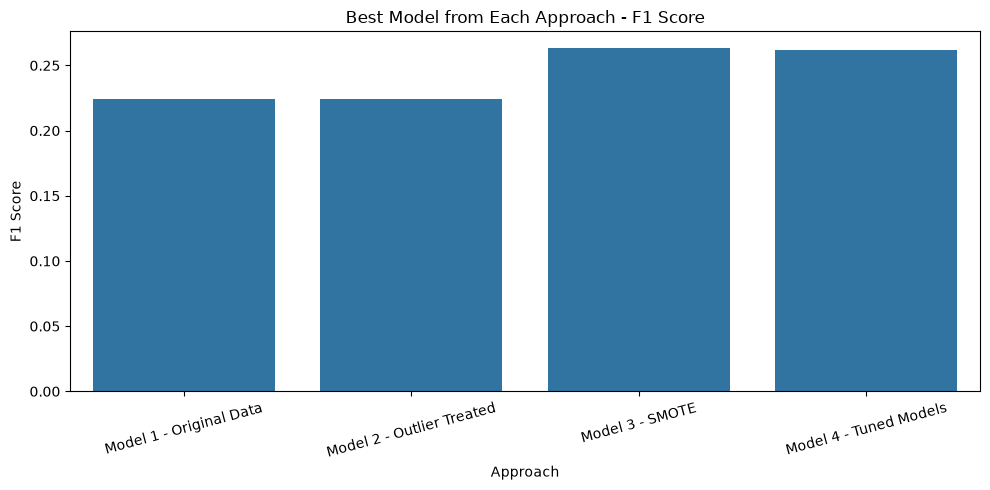

In [182]:
# ==========================================
# Final Comparison - F1 Score
# ==========================================

plt.figure(figsize=(10,5))
sns.barplot(data=final_model_comparison, x="Approach", y="F1 Score")
plt.title("Best Model from Each Approach - F1 Score")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

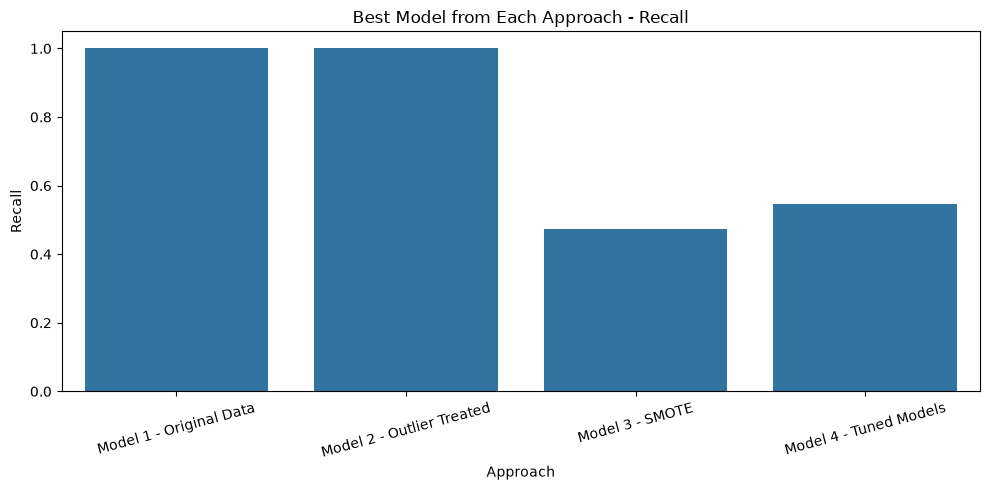

In [ ]:
# ==========================================
# Final Comparison - Recall
# ==========================================

plt.figure(figsize=(10,5))
sns.barplot(data=final_model_comparison, x="Approach", y="Recall")
plt.title("Best Model from Each Approach - Recall")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

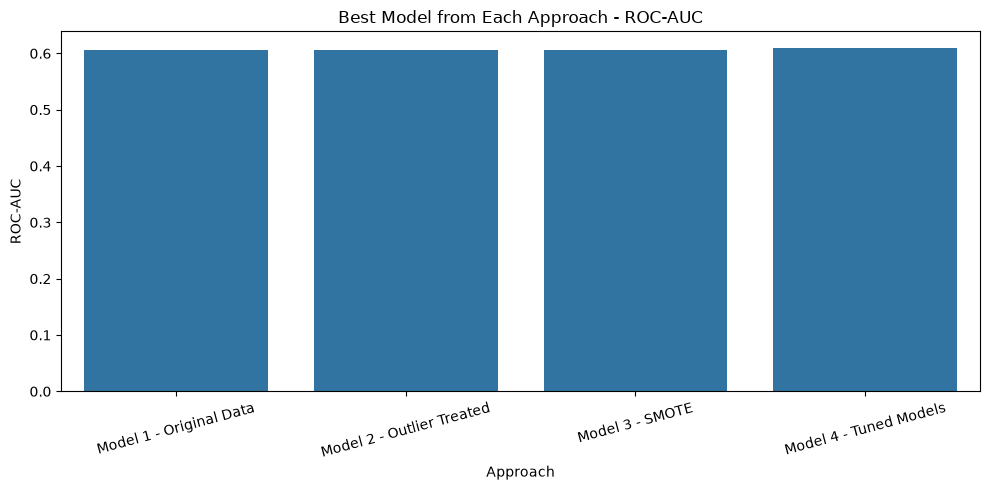

In [184]:
# ==========================================
# Final Comparison - ROC-AUC
# ==========================================

plt.figure(figsize=(10,5))
sns.barplot(data=final_model_comparison, x="Approach", y="ROC-AUC")
plt.title("Best Model from Each Approach - ROC-AUC")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

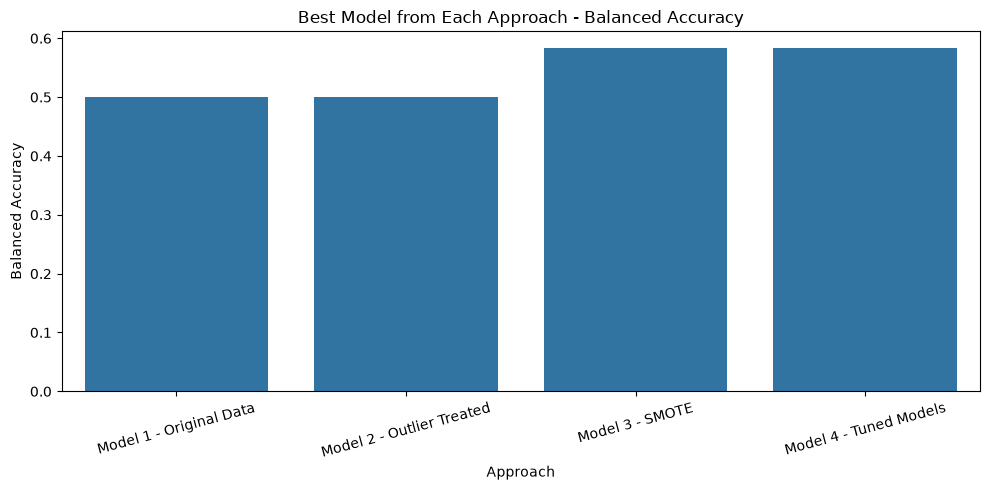

In [185]:
# ==========================================
# Final Comparison - Balanced Accuracy
# ==========================================

plt.figure(figsize=(10,5))
sns.barplot(data=final_model_comparison, x="Approach", y="Balanced Accuracy")
plt.title("Best Model from Each Approach - Balanced Accuracy")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Final Project Conclusion

## Project Objective

The objective of this project was to predict whether a customer would subscribe to a term deposit campaign using demographic and marketing-related attributes.

Since the target variable was highly imbalanced, multiple modeling approaches were explored to improve prediction performance and effectively identify potential subscribers.

---

## Modeling Approaches Evaluated

Four different approaches were implemented:

### Model 1: Original Dataset

The original dataset was used without any balancing techniques.

### Model 2: Outlier Treated Dataset

Outliers were treated before model training.

### Model 3: SMOTE Balanced Dataset

The minority class was balanced using SMOTE (Synthetic Minority Oversampling Technique).

### Model 4: Hyperparameter Tuned Models

Hyperparameter optimization was applied to improve model performance.

---

## Best Model Selection

Model performance was evaluated using:

- Precision
- Recall
- F1 Score
- Balanced Accuracy
- ROC-AUC

Since the dataset is imbalanced, F1 Score and Balanced Accuracy were given higher importance than overall accuracy.

The best performing model was:

### Gradient Boosting Classifier (Model 3)

| Metric | Value |
|----------|----------:|
| Test Accuracy | 66.44% |
| Balanced Accuracy | 58.27% |
| Precision | 18.20% |
| Recall | 47.34% |
| F1 Score | 26.30% |
| ROC-AUC | 60.65% |

---

## Key Findings

### Impact of Class Imbalance

Models trained on the original dataset achieved high accuracy but failed to identify subscribers effectively.

This demonstrates that accuracy alone can be misleading when working with imbalanced datasets.

---

### Impact of SMOTE

Applying SMOTE significantly improved:

- Recall
- F1 Score
- Balanced Accuracy

The models became better at identifying potential subscribers from the minority class.

---

### Impact of Hyperparameter Tuning

Hyperparameter tuning did not significantly improve performance.

Several tuned tree-based models showed signs of overfitting and failed to outperform their baseline versions.

---

### Best Overall Approach

The SMOTE-balanced dataset combined with Gradient Boosting produced the most balanced performance and demonstrated the strongest ability to identify potential subscribers.

---

## Final Recommendation

For future marketing campaigns, the organization should use the Gradient Boosting model trained on the SMOTE-balanced dataset to identify customers with a higher likelihood of subscribing to term deposits.

This approach can help:

- Improve campaign targeting
- Increase conversion rates
- Reduce marketing costs
- Improve resource allocation

# Business Insights & Recommendations

## Insight 1: Class Imbalance Significantly Affects Predictions

The original dataset contained substantially fewer subscribers than non-subscribers.

As a result, many models became biased toward predicting the majority class.

Organizations working with imbalanced customer response data should consider balancing techniques before model training.

---

## Insight 2: Data Balancing Improves Customer Identification

SMOTE significantly improved the model's ability to identify potential subscribers.

This indicates that balancing customer response data can improve campaign effectiveness.

---

## Insight 3: High Accuracy Does Not Mean Better Performance

Several models achieved more than 87% accuracy but failed to identify actual subscribers.

This highlights the importance of evaluating Recall, F1 Score, and Balanced Accuracy instead of relying solely on accuracy.

---

## Insight 4: Targeted Marketing Can Improve ROI

The final model can help identify customers who are more likely to subscribe.

This enables the bank to:

- Focus marketing efforts on high-potential customers
- Reduce unnecessary outreach
- Improve campaign efficiency

---

## Insight 5: Machine Learning Can Support Decision Making

Predictive models can assist marketing teams in prioritizing customers and designing more effective campaigns.

Such data-driven decision making can improve customer engagement and increase subscription rates.

---

## Overall Business Recommendation

Deploy the Gradient Boosting model trained on the SMOTE-balanced dataset as a decision-support tool for future marketing campaigns.

This model provides the best balance between identifying subscribers and maintaining overall predictive performance.

# Future Scope of the Project

Although the developed machine learning model achieved satisfactory performance in identifying potential term deposit subscribers, there are several opportunities to further improve the solution in future implementations.

---

## 1. Collection of Additional Customer Data

The current model was built using the available customer demographic and campaign-related information.

Future models can benefit from incorporating additional customer attributes such as:

- Customer transaction history
- Account balance trends
- Digital banking activity
- Customer engagement behavior
- Product ownership information

Additional data may help improve prediction accuracy and customer segmentation.

---

## 2. Advanced Feature Engineering

Creating new features from existing variables may enhance model performance.

Examples include:

- Customer tenure groups
- Campaign interaction frequency
- Previous response behavior
- Derived financial indicators
- Behavioral customer segments

Feature engineering can help uncover hidden patterns within the dataset.

---

## 3. Testing Advanced Machine Learning Algorithms

Future studies may explore more sophisticated algorithms, including:

- LightGBM
- CatBoost
- Stacking Ensembles
- Blending Techniques
- Deep Learning Models

These approaches may improve predictive performance and model robustness.

---

## 4. Automated Hyperparameter Optimization

Instead of manual tuning or Randomized Search, future projects can utilize:

- Bayesian Optimization
- Optuna
- Hyperopt
- AutoML Frameworks

These techniques may identify better parameter combinations while reducing computational effort.

---

## 5. Cost-Sensitive Learning

The current project focused on balancing the dataset using SMOTE.

Future implementations can explore cost-sensitive learning techniques that assign higher penalties to misclassifying potential subscribers.

This may improve business outcomes by prioritizing high-value predictions.

---

## 6. Real-Time Prediction System

The current solution is designed as a batch prediction model.

In future implementations, the model can be integrated into a real-time decision support system that:

- Scores customers instantly
- Recommends marketing actions
- Supports live campaign management

This can help organizations respond more quickly to customer opportunities.

---

## 7. Model Monitoring and Retraining

Customer behavior changes over time.

Future deployments should include:

- Continuous model monitoring
- Performance tracking
- Periodic retraining
- Data drift detection

This ensures the model remains accurate and relevant as business conditions evolve.

---

## 8. Integration with Marketing Strategy

The predictive model can be integrated with customer relationship management (CRM) platforms to support:

- Personalized marketing campaigns
- Customer prioritization
- Lead scoring
- Campaign optimization

This can improve conversion rates and increase marketing efficiency.

---

## Overall Future Scope

Future enhancements involving richer customer data, advanced feature engineering, modern machine learning techniques, and real-time deployment can further improve prediction performance and strengthen business decision-making capabilities.

The current project provides a strong foundation that can be expanded into a scalable and production-ready customer subscription prediction system.

# Saving Final Model for Deployment

## Objective

The best-performing model selected during model comparison is saved for deployment purposes.

The following objects are stored:

- Final Gradient Boosting Model
- Feature Scaler
- Feature Column Names

Saving these objects ensures that the deployment application uses the exact same preprocessing and model configuration that was used during training.

In [186]:
# ==========================================
# Save Final Model Objects
# ==========================================

import pickle

# Save Model
with open("gradient_boosting_model.pkl", "wb") as file:
    pickle.dump(gb_model3, file)

# Save Scaler
with open("scaler.pkl", "wb") as file:
    pickle.dump(scaler3, file)

# Save Feature Columns
with open("feature_columns.pkl", "wb") as file:
    pickle.dump(X3.columns.tolist(), file)

print("Files Saved Successfully")

Files Saved Successfully
